<center>
<img src="https://drive.google.com/uc?id=1f1gGVI-rxcHjA90WEGNvvtSXF1pAxQwg" alt="Fasilkom UI" width="300"/>

CSGE603130 • Kecerdasan Artifisial dan Sains Data Dasar

Semester Gasal 2023/2024

Fakultas Ilmu Komputer, Universitas Indonesia

# *Proyek Akhir KASDAD Kelompok Data+*: Valorant Pro Matches (VPM)

## Kelompok
| Nama | NPM |
|---|---|
| Lyzander Marciano Andrylie | 2106750755 |
| Muhammad Hafizha Dhiyaulhaq | 2106750723 |
| Felix Tjahyadi | 2106638614 |

## Deskripsi Proyek Akhir

**Valorant** adalah ***5v5 team-based first-person tactical hero shooter*** yang dikembangkan dan dipublikasikan oleh Riot Games. Pada game ini, pemain akan menggunakan salah satu ***agent***/karakter dengan kemampuan unik. Masing-masing *agent* akan memiliki peran tertentu dalam tim: *Duelists*, *Sentinels*, *Initiators*, and *Controllers*.

Pada saat permainan dimulai, 5 pemain dalam 1 tim akan berperan sebagai tim penyerang dan 5 pemain lainnya dalam 1 tim akan berperan sebagai tim bertahan secara bergiliran. Tim penyerang menang pada suatu ronde jika dan hanya jika *spike* yang ditanam pada lokasi bom meledak dan/atau kelima pemain dari tim bertahan berhasil dikalahkan. Di sisi lain, Tim bertahan menang pada suatu ronde jika dan hanya jika *spike* yang telah ditanam pada lokasi bom berhasil dijinakkan, kelima pemain dari tim penyerang berhasil dikalahkan dengan *spike* yang tidak meledak, atau waktu ronde habis. Berkaitan dengan permainan, suatu permainan akan berlangsung dalam 13 ronde atau lebih jika belum memenuhi kondisi *win by two*. Suatu permainan dimenangkan oleh suatu tim jika dan hanya jika tim memenangkan 13 ronde atau lebih dengan selisih kemenangan 2 ronde atau lebih dari tim yang kalah sedemikian hingga kondisi *win by two* terpenuhi. 

Seiring dengan meningkatnya kepopuleran dari Valorant, Valorant memiliki kancah esports yang aktif. Pada kancah ini, banyak turnamen yang telah diselenggarakan dan diikuti oleh berbagai tim dari belahan dunia dengan hadiah kemenangan yang besar. Dengan demikian, pada proyek ini, kami ingin menganalisis data pertandingan dari *Valorant Pro Matches* dan membuat model *machine learning* yang bermanfaat, baik bagi diri sendiri maupun orang lain. Berikut adalah ketentuan model machine learning dan analisis yang akan dilakukan.

-  Model klasifikasi untuk menentukan Agent yang digunakan oleh setiap pemain pada setiap babak.
-  Model untuk memprediksi nilai rata-rata ACS dari masing-masing tim untuk sebuah pertandingan.
-  Clustering pada dataset, analisis, dan insight dari cluster yang dibuat.

## Dependesi Proyek

In [595]:
import warnings

# Machine learning related library
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib import pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    BaggingClassifier,
    HistGradientBoostingClassifier,
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, r2_score

# Seaborn color palette
palette_agent_role = {
    "duelists": "#FF4654",
    "initiators": "#5B4E77",
    "controllers": "#64A0B3",
    "sentinels": "#FFB94E",
}

# Remove warning
warnings.simplefilter(action='ignore', category=FutureWarning)

In [446]:
from sklearn.metrics import precision_score, \
    recall_score, classification_report, \
    accuracy_score, f1_score


def evaluate_classifier_performance(prediction, y_test):
    print("Confusion Matrix \n")
    y_actual = pd.Series(np.array(y_test), name = "actual")
    y_pred = pd.Series(np.array(prediction), name = "prediction")
    df_confusion = pd.crosstab(y_actual, y_pred)
    display(df_confusion)

    print('Accuracy Average:', accuracy_score(y_test, prediction))
    print('F1 Macro Average:', f1_score(y_test, prediction, average='macro'))
    print('F1 Micro Average:', f1_score(y_test, prediction, average='micro'))
    print('Precision Macro Average:', precision_score(y_test, prediction, average='macro',zero_division=0))
    print('Precision Micro Average:', precision_score(y_test, prediction, average='micro',zero_division=0))
    print('Recall Macro Average:', recall_score(y_test, prediction, average='macro',zero_division=0))
    print('Recall Micro Average:', recall_score(y_test, prediction, average='micro',zero_division=0))
    print()

import random
import re
from datetime import datetime


class Transformer:
    def transform(self, data: pd.DataFrame):
        '''
        Implementasi berupa prosedur (Facade pattern) untuk men-transform test dataset `*_test.csv` ke dalam
        bentuk yang dapat diproses secara langsung oleh model machine learning yang telah dibuat.
        '''
        pass


class DatasetUtils(Transformer):
    '''
    Utility class untuk dataset hasil merger dari `matches.csv`, `games.csv`, dan `scores.csv` 
    '''

    def transform(self, df_matches, df_games, df_scores, df_patch_agent=None):
        df = self.merge_datasets(df_matches, df_games, df_scores)

        if df_patch_agent is not None:
            df['Total_Agent'] = self.create_total_agent(df, df_patch_agent)

        return df

    def merge_datasets(self, df_matches, df_games, df_scores):
        df_matches_games = pd.merge(df_matches, df_games, on=[
                                    'MatchID', 'Team1ID', 'Team2ID'])
        df_matches_games_scores = pd.merge(
            df_matches_games, df_scores, on=['GameID'])
        return df_matches_games_scores

    def remove_meta_attr_classification(self, df: pd.DataFrame):
        meta_attr = [
            'No_x', 'MatchID', 'EventID', 'EventName',
            'Team1ID', 'Team2ID', 'Team1_x', 'Team2_x',
            'Team1_MapScore', 'Team2_MapScore', 'No_y',
            'GameID', 'Team1_y', 'Team2_y', 'Winner', 'Team1_Eco',
            'Team1_SemiEco', 'Team1_SemiBuy', 'Team1_FullBuy',
            'Team1_TotalRounds', 'Team2_Eco', 'Team2_SemiEco',
            'Team2_SemiBuy', 'Team2_FullBuy', 'Team2_TotalRounds',
            'No', 'KAST_Percent', 'PlayerName', 'PlayerID', 'TeamAbbreviation', 'EventStage',
            'Num_2Ks', 'Num_3Ks', 'Num_4Ks', 'Num_5Ks', 'OnevOne', 'OnevTwo', 'OnevThree', 'OnevFour', 'OnevFive',
        ]

        if 'ACS' in df.columns:
            meta_attr.append('ACS')

        return df.drop(meta_attr, axis='columns')

    def remove_meta_attr_regression(self, df: pd.DataFrame):
        meta_attr = [
            'No_x', 'MatchID', 'EventID', 'EventName', 'Date', 'Patch', 'Map', 'Team_MapScore', 'Total_Agent',
            'Team1ID', 'Team2ID', 'Team1_x', 'Team2_x',
            'Team1_MapScore', 'Team2_MapScore', 'No_y',
            'GameID', 'Team1_y', 'Team2_y', 'Winner', 'Team1_Eco',
            'Team1_SemiEco', 'Team1_SemiBuy', 'Team1_FullBuy',
            'Team1_TotalRounds', 'Team2_Eco', 'Team2_SemiEco',
            'Team2_SemiBuy', 'Team2_FullBuy', 'Team2_TotalRounds',
            'No', 'KAST_Percent', 'PlayerName', 'PlayerID', 'TeamAbbreviation', 'EventStage',
            'Num_2Ks', 'Num_3Ks', 'Num_4Ks', 'Num_5Ks', 'OnevOne', 'OnevTwo', 'OnevThree', 'OnevFour', 'OnevFive',
            'Kills', 'Deaths', 'Assists', 'PlusMinus', 'ADR'
        ]

        if 'Agent' in df.columns:
            meta_attr.append('Agent')

        return df.drop(meta_attr, axis='columns')

    def classification_select(self, key):
        '''
        Method untuk memilih fitur yang akan digunakan dalam permasalahan klasifikasi
        '''
        pass

    def regression_select(self, key):
        '''
        Method untuk memilih fitur yang akan digunakan dalam permasalahan regressi
        '''
        pass

    def create_total_agent(self, df: pd.DataFrame, df_patch_agent: pd.DataFrame):
        def create_total_agent(x):
            return df_patch_agent.loc[x][0]

        return df['Patch'].map(create_total_agent)


class MatchesUtils(Transformer):
    '''
    Utility class untuk dataset `matches.csv`
    '''

    def transform(self, data: pd.DataFrame, df_patch_date_range: pd.DataFrame):
        df = data.copy()
        df['Date'] = self.date_transform(df)
        df['Patch'] = self.patch_impute(df, df_patch_date_range)
        df['Patch'] = self.patch_transform(df)
        df['Date'] = self.date_transform_remove_day(df)
        df['Date'] = self.date_diff_transform(df)
        df['Team_MapScore'] = self.create_team_mapscore_avg(df)
        return df

    def patch_transform(self, df: pd.DataFrame):
        def patch_transform(x):
            regex = r"(?<=Patch\s)\d"
            match = re.search(regex, x)
            return match.group() if match else x

        return df['Patch'].map(patch_transform, na_action='ignore')

    def patch_impute(self, df_matches: pd.DataFrame, df_patch_date_range: pd.DataFrame):
        '''
        Imputasi Kolom `Patch` berdasarkan tanggal `Date` dari suatu pertandingan
        '''

        def patch_imputer(row):
            if not pd.isna(row['Patch']):
                return row['Patch']

            row_date_obj = datetime.strptime(row['Date'], "%Y-%m-%d")

            # Pengecekan `Date` berdasarkan nilai paling min
            lowest_patch_min_date = df_patch_date_range['Date']['min'].min()
            lowest_patch_min_date_obj = datetime.strptime(
                lowest_patch_min_date, "%Y-%m-%d")

            if row_date_obj < lowest_patch_min_date_obj:
                return df_patch_date_range['Date']['min'].idxmin()

            # Pengecekan `Date` berdasarkan range `df_patch_date_range`
            for patch, date_range in df_patch_date_range.iterrows():
                patch_min_date = date_range['Date']['min']
                patch_max_date = date_range['Date']['max']

                patch_min_date_obj = datetime.strptime(
                    patch_min_date, "%Y-%m-%d")
                patch_max_date_obj = datetime.strptime(
                    patch_max_date, "%Y-%m-%d")

                # Pengecekan `Date` dari suatu pertandingan untun menentukan Patch
                if patch_min_date_obj <= row_date_obj <= patch_max_date_obj:
                    return patch

            return row['Patch']

        return df_matches[['Date', 'Patch']].apply(
            patch_imputer, axis='columns')

    def date_transform(self, df: pd.DataFrame):
        def date_transform(x):
            date, *_ = x.split()
            return date

        return df['Date'].map(date_transform, na_action='ignore')

    def date_transform_remove_day(self, df: pd.DataFrame):
        def date_transform(x):
            year, month, _ = x.split('-')
            return f'{year}-{month}'

        return df['Date'].map(date_transform, na_action='ignore')

    def date_diff_transform(self, df: pd.DataFrame):
        date_valorant_published = '2020-06-02'
        date_subtrahend = datetime.strptime(
            date_valorant_published, '%Y-%m-%d')

        def date_diff_transform(x):
            date_minuend = datetime.strptime(x, '%Y-%m')
            time_difference = (date_minuend - date_subtrahend).days
            return time_difference

        return df['Date'].apply(date_diff_transform)

    def create_team_mapscore_avg(self, df_matches: pd.DataFrame):
        def create_team_mapscore(row):
            return (row['Team1_MapScore'] + row['Team2_MapScore'])/2

        return df_matches[['Team1_MapScore', 'Team2_MapScore']].apply(create_team_mapscore, axis='columns')


class GamesUtils(Transformer):
    '''
    Utility class untuk dataset `games.csv`
    '''

    def transform(self, data: pd.DataFrame):
        df = data.copy()
        df['Team_Eco'] = self.create_team_eco_avg(df)
        df['Team_SemiEco'] = self.create_team_semieco_avg(df)
        df['Team_SemiBuy'] = self.create_team_semibuy_avg(df)
        df['Team_FullBuy'] = self.create_team_fullbuy_avg(df)
        df['Team_TotalRounds'] = self.create_team_total_round_avg(df)
        return df

    def econ_impute(self, df_games: pd.DataFrame, df_team_econ_median: pd.DataFrame, srs_econ_median: pd.Series):
        def econ_impute(row):
            if not row.isna().any():
                return row

            if row[['Team1ID', 'Team1_Eco', 'Team1_SemiEco', 'Team1_SemiBuy', 'Team1_FullBuy']].isna().any():
                team1_econ_info = df_team_econ_median.loc[int(row['Team1ID'])]

                if team1_econ_info.isna().any():
                    team1_econ_info = srs_econ_median

                row['Team1_Eco'] = team1_econ_info['Team_Eco']
                row['Team1_SemiEco'] = team1_econ_info['Team_SemiEco']
                row['Team1_SemiBuy'] = team1_econ_info['Team_SemiBuy']
                row['Team1_FullBuy'] = team1_econ_info['Team_FullBuy']
            if row[['Team2ID', 'Team2_Eco', 'Team2_SemiEco', 'Team2_SemiBuy', 'Team2_FullBuy']].isna().any():
                team2_econ_info = df_team_econ_median.loc[int(row['Team2ID'])]

                if team2_econ_info.isna().any():
                    team2_econ_info = srs_econ_median

                row['Team2_Eco'] = team2_econ_info['Team_Eco']
                row['Team2_SemiEco'] = team2_econ_info['Team_SemiEco']
                row['Team2_SemiBuy'] = team2_econ_info['Team_SemiBuy']
                row['Team2_FullBuy'] = team2_econ_info['Team_FullBuy']

            return row

        return df_games[['Team1ID', 'Team1_Eco', 'Team1_SemiEco', 'Team1_SemiBuy', 'Team1_FullBuy', 'Team2ID', 'Team2_Eco', 'Team2_SemiEco', 'Team2_SemiBuy', 'Team2_FullBuy']].apply(econ_impute, axis='columns')

    def create_team_eco_avg(self, df_games: pd.DataFrame):
        def create_team_eco_avg(row):
            return (row['Team1_Eco'] + row['Team2_Eco'])/2

        return df_games[['Team1_Eco', 'Team2_Eco']].apply(create_team_eco_avg, axis='columns')

    def create_team_semieco_avg(self, df_games: pd.DataFrame):
        def create_team_semieco_avg(row):
            return (row['Team1_SemiEco'] + row['Team2_SemiEco'])/2

        return df_games[['Team1_SemiEco', 'Team2_SemiEco']].apply(create_team_semieco_avg, axis='columns')

    def create_team_semibuy_avg(self, df_games: pd.DataFrame):
        def create_team_semibuy_avg(row):
            return (row['Team1_SemiBuy'] + row['Team2_SemiBuy'])/2

        return df_games[['Team1_SemiBuy', 'Team2_SemiBuy']].apply(create_team_semibuy_avg, axis='columns')

    def create_team_fullbuy_avg(self, df_games: pd.DataFrame):
        def create_team_fullbuy_avg(row):
            return (row['Team1_FullBuy'] + row['Team2_FullBuy'])/2

        return df_games[['Team1_FullBuy', 'Team2_FullBuy']].apply(create_team_fullbuy_avg, axis='columns')

    def create_team_total_round_avg(self, df_games: pd.DataFrame):
        def create_team_fullbuy_avg(row):
            return (row['Team1_TotalRounds'] + row['Team2_TotalRounds'])/2

        return df_games[['Team1_TotalRounds', 'Team2_TotalRounds']].apply(create_team_fullbuy_avg, axis='columns')


class ScoresUtils(Transformer):
    '''
    Utility class untuk dataset `scores.csv`
    '''

    def transform(self, data: pd.DataFrame):
        df = data.copy()
        df['Num_Ks'] = self.create_numks(df)
        df['OnevX'] = self.create_onevx(df)
        return df

    def cek_null(self, df: pd.DataFrame):
        col_na = df.isnull().sum().sort_values(ascending=False)
        percent = col_na / len(df) * 100

        missing_data = pd.concat(
            [col_na, percent], axis=1, keys=['Total', 'Percent'])
        print(missing_data[missing_data['Total'] > 0])

    def player_id_impute(self, df: pd.DataFrame):
        id_counter = df['PlayerID'].max() + 1
        player_ids = {}

        def player_id_imputer(row):
            nonlocal id_counter, player_ids

            if pd.isnull(row['PlayerID']):
                if row['PlayerName'] in player_ids:
                    return player_ids[row['PlayerName']]

                player_ids[row['PlayerName']] = id_counter
                id_counter += 1
                return player_ids[row['PlayerName']]

            return row['PlayerID']

        return df[['PlayerID', 'PlayerName']].apply(
            player_id_imputer, axis='columns')

    def agent_impute(self, df: pd.DataFrame, df_merge, srs_most_used_hero_by_player):
        random.seed(1000)
        df_game_id_patch = df_merge[['GameID', 'Patch']]

        def agent_imputer(row):
            patch_nums = df_game_id_patch.loc[df_game_id_patch['GameID']
                                              == row['GameID'], 'Patch']

            if (not pd.isnull(row['Agent'])) or len(patch_nums) == 0:
                return row['Agent']

            # Imputasi berdasarkan agent yang paling sering dimainkan
            agent = srs_most_used_hero_by_player[row['PlayerID'],
                                                 patch_nums.iloc[0]]

            if isinstance(agent, str):
                return agent
            elif isinstance(agent, np.ndarray) and len(agent) >= 2:
                return agent[random.randint(0, len(agent)-1)]

            return row['Agent']

        return df[['PlayerID', 'Agent', 'GameID']].apply(
            agent_imputer, axis='columns')

    def acs_impute(self, df_scores: pd.DataFrame, acs_median: pd.DataFrame):
        '''
        Imputasi Kolom 'ACS' berdasarkan Agent yang dipilih
        '''
        def acs_imputer(row):
            if not pd.isna(row['ACS']):
                return row['ACS']

            row_agent_obj = row['Agent']

            # Pengecekan Agent untuk menentukan nilai ACS
            agent_row = acs_median.loc[acs_median['Agent'] == row_agent_obj]

            if not agent_row.empty:
                return agent_row['ACS'].iloc[0]

            return row['ACS']

        return df_scores[['Agent', 'ACS']].apply(
            acs_imputer, axis='columns')

    def team_abbreviation_impute(self, df_scores: pd.DataFrame, df_game_team_agent: pd.DataFrame):
        def team_abbreviation_impute(row):
            if not row.isna().any():
                return row

            team_agent_info = df_game_team_agent.loc[int(row['GameID'])]
            team_abbr = team_agent_info['TeamAbbreviation']
            team_agent = team_agent_info['Agent']

            try:
                team1, team2 = set(team_abbr)
                team1_count = team_abbr.count(team1)
                team2_count = team_abbr.count(team2)

                if team1_count == 5 and team2_count == 4:
                    row['TeamAbbreviation'] = team2
                elif team1_count == 4 and team2_count == 5:
                    row['TeamAbbreviation'] = team1
                elif row['Agent'] in team_agent:
                    enemy_agent_index = team_agent.index(row['Agent'])
                    enemy_team = team_agent[enemy_agent_index]
                    row['TeamAbbreviation'] = team1 if enemy_team == team2 else team2
                else:
                    row['TeamAbbreviation'] = team1 if team1_count < team2_count else team2
            except:
                team = set(team_abbr).pop()
                team_count = team_abbr.count(team)

                if team_count < 5:
                    row['TeamAbbreviation'] = team
            finally:
                return row

        return df_scores[['GameID', 'TeamAbbreviation', 'Agent']].apply(team_abbreviation_impute, axis='columns')

    def create_numks(self, df_scores: pd.DataFrame):
        def create_numks(row):
            return (2*row['Num_2Ks'] + 3*row['Num_3Ks'] + 4*row['Num_4Ks'] + 5*row['Num_5Ks'])/14
        return df_scores[['Num_2Ks', 'Num_3Ks', 'Num_4Ks', 'Num_5Ks']].apply(create_numks, axis='columns')

    def create_onevx(self, df_scores: pd.DataFrame):
        def create_onevx(row):
            return (1*row['OnevOne']+2*row['OnevTwo'] + 3*row['OnevThree'] + 4*row['OnevFour'] + 5*row['OnevFive'])/15
        return df_scores[['OnevOne', 'OnevTwo', 'OnevThree', 'OnevFour', 'OnevFive']].apply(create_onevx, axis='columns')


# Objek utility
util_matches = MatchesUtils()
util_games = GamesUtils()
util_scores = ScoresUtils()
util_dataset = DatasetUtils()


## Dataset

### Deskripsi Dataset

1. Dataset `matches.csv`

    Berisi informasi tentang tim yang berpartisipasi dalam sebuah turnamen. Pertandingan umumnya diadakan dengan aturan "best of 3," di mana tim yang memenangkan babak terbanyak akan menjadi pemenang pertandingan.

    > **Note:** Pertandingan final diadakan dengan aturan "best of 5"

    Jumlah Kolom x Baris: 12 kolom x 6401 baris

    Deskripsi Kolom:

    1. MatchID : Id pertandingan
    2. Date : Tanggal pertandingan
    3. Patch : Versi Valorant saat pertandingan dilakukan
    4. EventID : Id turnamen
    5. EventName : Nama turnamen
    6. EventStage : Tahap turnamen
    7. Team1ID : Id tim 1
    8. Team2ID : Id tim 2
    9. Team1 : Nama tim 1
    10. Team2 : Nama tim 2
    11. Team1_MapScore : Banyak babak yang dimenangkan tim 1
    12. Team2_MapScore : Banyak babak yang dimenangkan tim 2

2. Dataset `games.csv`

    Mendokumentasikan detail babak yang dimainkan oleh kedua tim yang bersaing dalam turnamen.

    Jumlah Kolom x Baris: 18 kolom x 12961 baris

    Deskripsi Kolom:

    1. GameID : Id babak
    2. MatchID : Id pertandingan
    3. Map : Peta yang digunakan
    4. Team1ID : Id tim 1
    5. Team2ID : Id tim 2
    6. Team1 : Nama tim 1
    7. Team2 : Nama tim 2
    8. Winner : Tim yang menjadi pemenang
    9. Team1_Eco : Banyak ronde eco yang dilakukan tim 1
    10. Team1_SemiEco : Banyak ronde semi eco yangdilakukan tim 1
    11. Team1_SemiBuy : Banyak ronde semi buy yangdilakukan tim 1
    12. Team1_FullBuy : Banyak ronde full buy yang dilakukan tim 1
    13. Team1_TotalRounds : Banyak ronde yang dimenangkan tim 1
    14. Team2_Eco : Banyak ronde eco yang dilakukan tim 2
    15. Team2_SemiEco : Banyak ronde semi eco yang dilakukan tim 2
    16. Team2_SemiBuy : Banyak ronde semi buy yang dilakukan tim 2
    17. Team2_FullBuy : Banyak ronde full buy yang dilakukan tim 2
    18. Team2_TotalRounds : Banyak ronde yang dimenangkan tim 2

    > **Note:** Valorant Economy Guide: <https://www.ign.com/wikis/valorant/Valorant_Economy_Guide>
    > Penting untuk tahap pemahaman data.

3. Dataset `scores.csv`

    Merupakan catatan akhir dari status para pemain profesional yang bertanding dalam babak tersebut

    Jumlah Kolom x Baris: 28 kolom x 128779 baris

    Deskripsi Kolom:

    1. GameID : Id babak
    2. PlayerID: Id pemain
    3. PlayerName : Username pemain
    4. TeamAbbreviation : Singkatan nama tim
    5. Agent : Agent/karakter yang digunakan
    6. ACS : Skor rata-rata dari pemain
    7. Kills : Jumlah musuh yang dikalahkan
    8. Deaths : Total pemain berhasil dieliminasi
    9. Assists : Jumlah kontribusi pemain dalam membantu rekannya untuk mengalahkan musuh
    10. PlusMinus : Selisih antara jumlah mengalahkan musuh (Kills) dan jumlah tereliminasi (Deaths)
    11. KAST_Percent : Besar kontribusi pemain dalam pertandingan
    12. ADR : Rata-rata serangan yang diberikan oleh pemain ke pihak musuh
    13. HS_Percent : Persentase serangan yang diberikan mengenai kepala musuh
    14. FirstKills : Total pemain berhasil melakukan eliminasi pertama kali pada suatu ronde
    15. FirstDeaths : Total pemain dieliminasi pertama kali pada suatu ronde
    16. FKFD_PlusMinus : Selisih antara jumlah First Kills dan First Deaths
    17. Num_2Ks, Num_3ks, Num_4ks, Num_5ks : Jumlah pemain berhasil mengeliminasi X musuh dalam suatu ronde
    18. OnevOne, OnevTwo, OnevThree, OnevFour, OnevFive : Jumlah pemain berhasil mengalahkan X musuh pada suatu timeframe
    19. Econ : Besar serangan yang dihasilkan untuk setiap 1000 creds (mata uang pada permainan) yang digunakan untuk membeli perlengkapan
    20. Plants : Jumlah pemain berhasil menanam spike (bom) pada suatu ronde
    21. Defuses : Jumlah pemain berhasil menjinakkan spike (bom) pada suatu ronde

    > **Notes:** Valorant Key Metric: <https://digitalgamersdream.com/key-metrics-for-analyzing-valorant-matches/>
    > Penting untuk pemahaman terkait metric-metric tertentu, seperti ACS (Average Combat Score) dan KAST.

    > Num_5ks = Ace

4. Dataset `agent_encode.csv`

    Label encoding dari nama agent di Valorant.

    Jumlah Kolom x Baris: 2 kolom x 17 baris

    Deskripsi Kolom:

    1. Agent: nama karakter
    2. Encode: hasil encoding

5. Dataset `agent_role.csv`

    Kategori dari agent-agent pada valorant

    Jumlah Kolom x Baris: 2 kolom x 17 baris

    Deskripsi Kolom:

    1. Agent: nama karakter
    2. Role: peran karakter

    Kategori Kolom Role:

    1. controllers: agen-agen dengan tipe ini dapat memblokir area tertentu di peta untuk mempermudah serangan atau pertahanan, serta mengontrol alur permainan.
    2. duelists: agen-agen dengan tipe ini bersifat ofensif dan unggul dalam pertarungan satu lawan satu yang bertujuan untuk menerobos pertahanan musuh dan memenangkan duel.
    3. initiators: agen-agen dengan tipe ini berfungsi sebagai pendukung dan sangat cocok untuk memulai pertarungan dan membantu tim Anda memenangkannya. Agen ini biasanya memiliki kemampuan yang memungkinkan mereka memberikan informasi kepada tim, atau mengacaukan musuh. 
    4. sentinels: agen-agen dengan tipe ini bersifat defensif dan biasanya memperlambat, mengulur waktu, atau terkadang langsung menghentikan serangan musuh di area tertentu di peta.

### Read Dataset

#### Dataset `matches.csv`

In [447]:
df_matches = pd.read_csv('./dataset/matches.csv')
df_matches.head()

,No,MatchID,Date,Patch,EventID,EventName,EventStage,Team1ID,Team2ID,Team1,Team2,Team1_MapScore,Team2_MapScore
0,0,62393,2022-01-08 15:30:00,Patch 3.12,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Decider (A),6903,6020,Booster Seat Gaming,Pho Real,2,1
1,1,62403,2022-01-08 15:30:00,Patch 3.12,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Decider (C),7046,7047,Bjor's Kittens,Mugiwara,2,0
2,2,62391,2022-01-08 12:30:00,Patch 3.12,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Winner's (A),6461,6903,Akrew,Booster Seat Gaming,2,1
3,3,62396,2022-01-08 12:30:00,Patch 3.12,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Winner's (B),6164,7043,Radiance,sameROFLMAO,2,0
4,5,62402,2022-01-08 12:30:00,Patch 3.12,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Elimination (C),7047,3545,Mugiwara,CLG Red,2,0


In [448]:
df_matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6401 entries, 0 to 6400
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   No              6401 non-null   int64 
 1   MatchID         6401 non-null   int64 
 2   Date            6401 non-null   object
 3   Patch           5990 non-null   object
 4   EventID         6401 non-null   int64 
 5   EventName       6401 non-null   object
 6   EventStage      6401 non-null   object
 7   Team1ID         6401 non-null   int64 
 8   Team2ID         6401 non-null   int64 
 9   Team1           6401 non-null   object
 10  Team2           6401 non-null   object
 11  Team1_MapScore  6401 non-null   int64 
 12  Team2_MapScore  6401 non-null   int64 
dtypes: int64(7), object(6)
memory usage: 650.2+ KB


#### Dataset `games.csv`

In [449]:
df_games = pd.read_csv('./dataset/games.csv')
df_games.head()

,No,GameID,MatchID,Map,Team1ID,Team2ID,Team1,Team2,Winner,Team1_Eco,Team1_SemiEco,Team1_SemiBuy,Team1_FullBuy,Team1_TotalRounds,Team2_Eco,Team2_SemiEco,Team2_SemiBuy,Team2_FullBuy,Team2_TotalRounds
0,0,60894,62393,Breeze,6903,6020,Booster Seat Gaming,Pho Real,1,2.0,0.0,5.0,13.0,13,4.0,2.0,4.0,10.0,7
1,1,60895,62393,Bind,6903,6020,Booster Seat Gaming,Pho Real,2,3.0,3.0,5.0,4.0,2,2.0,0.0,4.0,9.0,13
2,2,60896,62393,Haven,6903,6020,Booster Seat Gaming,Pho Real,1,2.0,2.0,5.0,12.0,13,2.0,2.0,6.0,11.0,8
3,3,60924,62403,Icebox,7046,7047,Bjor's Kittens,Mugiwara,1,2.0,2.0,4.0,11.0,13,4.0,1.0,2.0,12.0,6
4,4,60925,62403,Haven,7046,7047,Bjor's Kittens,Mugiwara,1,4.0,2.0,3.0,13.0,13,3.0,3.0,4.0,12.0,9


In [450]:
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12961 entries, 0 to 12960
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   No                 12961 non-null  int64  
 1   GameID             12961 non-null  int64  
 2   MatchID            12961 non-null  int64  
 3   Map                12961 non-null  object 
 4   Team1ID            12961 non-null  int64  
 5   Team2ID            12961 non-null  int64  
 6   Team1              12961 non-null  object 
 7   Team2              12961 non-null  object 
 8   Winner             12961 non-null  int64  
 9   Team1_Eco          11927 non-null  float64
 10  Team1_SemiEco      11927 non-null  float64
 11  Team1_SemiBuy      11927 non-null  float64
 12  Team1_FullBuy      11927 non-null  float64
 13  Team1_TotalRounds  12961 non-null  int64  
 14  Team2_Eco          11927 non-null  float64
 15  Team2_SemiEco      11927 non-null  float64
 16  Team2_SemiBuy      119

#### Dataset `scores.csv`

In [451]:
df_scores = pd.read_csv('./dataset/scores.csv')
df_scores.head()

,No,GameID,PlayerID,PlayerName,TeamAbbreviation,Agent,ACS,Kills,Deaths,Assists,...,Num_4Ks,Num_5Ks,OnevOne,OnevTwo,OnevThree,OnevFour,OnevFive,Econ,Plants,Defuses
0,0,60894,8419.0,Reduxx,Boos,jett,313.0,24.0,10.0,3.0,...,2.0,0.0,1.0,0.0,0.0,0.0,0.0,74.0,0.0,0.0
1,1,60894,466.0,ChurmZ,Boos,chamber,227.0,16.0,10.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67.0,2.0,0.0
2,2,60894,3712.0,diaamond,Boos,sova,226.0,17.0,9.0,8.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,58.0,3.0,0.0
3,3,60894,5099.0,Boltzy,Boos,viper,218.0,17.0,12.0,2.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,48.0,0.0,0.0
4,4,60894,3983.0,Virtyy,Boos,skye,80.0,5.0,13.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.0,0.0,0.0


In [452]:
df_scores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128779 entries, 0 to 128778
Data columns (total 29 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   No                128779 non-null  int64  
 1   GameID            128779 non-null  int64  
 2   PlayerID          128692 non-null  float64
 3   PlayerName        128779 non-null  object 
 4   TeamAbbreviation  126763 non-null  object 
 5   Agent             124679 non-null  object 
 6   ACS               128249 non-null  float64
 7   Kills             128289 non-null  float64
 8   Deaths            128289 non-null  float64
 9   Assists           128289 non-null  float64
 10  PlusMinus         127026 non-null  float64
 11  KAST_Percent      2637 non-null    float64
 12  ADR               119904 non-null  float64
 13  HS_Percent        119307 non-null  float64
 14  FirstKills        128249 non-null  float64
 15  FirstDeaths       119314 non-null  float64
 16  FKFD_PlusMinus    11

#### Dataset `agent_encode.csv`

In [453]:
df_agent_encode = pd.read_csv('./dataset/agent_encode.csv')
df_agent_encode.drop(df_agent_encode.columns[0], axis='columns', inplace=True)
df_agent_encode.head()

,Agent,Encode
0,jett,0
1,sova,1
2,astra,2
3,kayo,3
4,killjoy,4


In [454]:
dct_agent_encode = df_agent_encode.set_index('Agent')['Encode'].to_dict()
dct_agent_encode

{'jett': 0,
 'sova': 1,
 'astra': 2,
 'kayo': 3,
 'killjoy': 4,
 'skye': 5,
 'cypher': 6,
 'viper': 7,
 'sage': 8,
 'reyna': 9,
 'chamber': 10,
 'raze': 11,
 'breach': 12,
 'omen': 13,
 'brimstone': 14,
 'phoenix': 15,
 'yoru': 16}

#### Dataset `agent_role.csv`

In [455]:
df_agent_role = pd.read_csv('./dataset/agent_role.csv')
df_agent_role.drop(df_agent_role.columns[0], axis='columns', inplace=True)
df_agent_role.head()

# Merge dataset
df_agent = pd.merge(df_agent_encode, df_agent_role)
df_agent

,Agent,Encode,Role
0,jett,0,duelists
1,sova,1,initiators
2,astra,2,controllers
3,kayo,3,initiators
4,killjoy,4,sentinels
5,skye,5,initiators
6,cypher,6,sentinels
7,viper,7,controllers
8,sage,8,sentinels
9,reyna,9,duelists


## Merge Dataset

In [456]:
def remerge(df_patch_agent=None):
    global df_matches_games_scores
    df_matches_games_scores = util_dataset.transform(
        df_matches, df_games, df_scores, df_patch_agent)

## Initial Data Preprocessing

Tahap pemrosesan ini dilakukan agar visualisasi data yang dihasilkan pada tahap berikut benar, tepat sasaran, dan sesuai dengan informasi yang ada.

### Imputasi pada kolom `PlayerID`

Berdasarkan informasi pada bagian `Dataset`, kolom `PlayerID` memiliki beberapa baris dengan nilai `null` dan jumlahnya tidak sama dengan `PlayerName`. Imputasi pada kolom `PlayerID` dilakukan dengan memberikan `ID` unik pada pemain dengan `PlayerName` tertentu. Hal ini diperlukan agar kita dapat mengidentifikasikan pemain berdasarkan `PlayerID`-nya.

In [457]:
df_scores['PlayerID'] = util_scores.player_id_impute(df_scores)
df_scores[['PlayerID', 'PlayerName']].isnull().sum()

PlayerID      0
PlayerName    0
dtype: int64

In [458]:
remerge()

### Transformasi Kolom `Date`

Pemrosesan perlu dilakukan agar kolom `Date` dapat lebih mudah diproses untuk menentukan kolom `Patch` yang akan diimputasi berdasarkan kolom tersebut. Pemrosesan dilakukan dengan menghapus waktu pada kolom `Date` (dari `2022-01-08 15:30:00` menjadi `2022-01-08`).

In [459]:
df_matches['Date'] = util_matches.date_transform(df_matches)
df_matches['Date'].value_counts()


Date
2021-11-12    74
2021-11-13    69
2020-12-19    68
2021-07-22    48
2021-10-09    46
              ..
2021-12-16     1
2021-03-23     1
2021-06-01     1
2021-05-31     1
2020-07-21     1
Name: count, Length: 557, dtype: int64

In [460]:
remerge()

### Data Cleaning, Data Transformation, dan Imputasi Kolom `Patch`

Berdasarkan informasi pada bagian `Dataset`, kolom `Patch` memiliki beberapa baris dengan nilai `null`. Perhatikan bahwa nilai `null` pada kolom ini dapat menyebabkan visualisasi data, seperti distribusi agent untuk setiap patch, tidak lengkap. Dengan demikian, kita akan melakukan imputasi terhadap kolom `Patch` terlebih dahulu.

In [461]:
# Jumlah Null
df_matches['Patch'].isnull().sum()

411

In [462]:
# Kategori
df_matches['Patch'].value_counts('Patch').sort_index(ascending=False)

Patch
Patch 3.12                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   0.028381
Patch 3.10                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

Perhatikan bahwa value pada kolom `Patch` tidak ringkas, sulit diinterpretasikan, sulit dipahami dan tidak konsisten. Dengan demikian, kita dapat melakukan *data cleaning* sedemikian hingga masalah-masalah pada kolom `Patch` dapat diatasi. 

Pemrosesan kolom patch dapat dilakukan dengan memahami format dari nilai pada kolom `Patch`. Bentuk format `Patch` pada game valorant adalah `X.YZ` dengan makna sebagai berikut.

1. `X`: merepresentasikan nomor **episode** yang biasanya berlangsung selama 2 bulan
2. `Y`: merepresentasikan nomor **act** yang biasanya berlansung selama 2 minggu
3. `Z`: merepresentasikan nomor **patch** dalam suatu **act**

Dengan demikian, kita dapat meringkas data berdasarkan nilai `X` sedemikian hingga nilai pada kolom `Patch` mudah dipahami.

In [463]:
df_matches['Patch'] = util_matches.patch_transform(df_matches)
df_matches['Patch'].value_counts()

Patch
3    2038
2    1959
1    1907
0      86
Name: count, dtype: int64

Kemudian, imputasi dilakukan pada baris dengan kolom `Patch` yang bernilai null sebagai berikut.
1. Nilai dari kolom tersebut akan ditentukan berdasarkan rentang `Date` (minimum s.d. maximum `Date`) dari pertandingan pada `Patch` tertentu yang tersedia pada dataset
2. `Date` dari pertandingan akan dibandingkan dengan rentang tanggal patch (`df_patch_date_range`). 
3. Jika suatu pertandingan memiliki `Date` yang berada pada rentang `min Date` dan `max Date` dari `Patch x`, maka kolom `Patch` akan bernilai `x`. Sebagai tambahan, pertandingan dengan `Date` \< `min Date` dari `Patch 0` akan bernilai 0 pada kolom `Patch`-nya. 

In [464]:
df_patch_date_range = df_matches[['Patch', 'Date']].groupby('Patch').aggregate(['min', 'max'])
df_patch_date_range

Date            
              min         max
Patch                        
0      2020-05-04  2020-06-14
1      2020-06-04  2021-01-24
2      2021-01-13  2021-06-29
3      2021-06-22  2022-01-08

In [465]:
df_matches['Patch'] = util_matches.patch_impute(df_matches, df_patch_date_range)
df_matches['Patch'].isnull().sum()

0

In [466]:
remerge()

### Imputasi Data untuk kolom `Agent`

Berdasarkan informasi pada bagian `Dataset`, kolom `Agent` memiliki beberapa baris dengan nilai `null`. Perhatikan bahwa nilai `null` pada kolom ini dapat menyebabkan visualisasi data, seperti distribusi agent untuk setiap patch, tidak lengkap. Oleh karena itu, kita harus melakukan imputasi data terlebih dahulu sehingga nilai null pada kolom `Agent` dapat dikurangi. Hal ini dapat dilakukan dengan menggunakan modus dari `Agent` berdasarkan pemain dengan `PlayerID` tertentu (Agent yang paling sering dimainkan oleh pemain pada turnamen).

In [467]:
# Jumlah Null
df_scores['Agent'].isnull().sum()

4100

Imputasi dilakukan pada kolom `Agent` berdasarkan Agent yang paling sering dimainkan oleh pemain pada turnamen pada `Patch` tertentu. Hal ini dikarenakan setiap pemain memiliki kecenderungan untuk memiliki main agent. Main agent adalah agent yang paling sering digunakan dan dikuasai oleh seorang pemain. Dengan demikian, masuk akal jika kita melakukan imputasi berdasarkan main agent.

In [468]:
# Modus Agent dari setiap Pemain berdasarkan `PlayerID` dan `Patch`
srs_most_used_hero_by_player = df_matches_games_scores[['PlayerID', 'Patch', 'Agent',]].groupby(['PlayerID', 'Patch'])['Agent'].agg(pd.Series.mode)
srs_most_used_hero_by_player

PlayerID  Patch
2.0       0          omen
          1        cypher
          2          jett
          3          sova
3.0       0        breach
                    ...  
22035.0   0            []
22036.0   0            []
22037.0   0            []
22038.0   0            []
22039.0   0            []
Name: Agent, Length: 12750, dtype: object

> Kita dapat mengabaikan player yang tidak memiliki modus `Agent`. Perhatikan bahwa, pada tahap *Preprocessing*, kita akan memperbaiki lebih lanjut untuk dataset yang digunakan.


> Sisa `Agent` yang bernilai null dapat diabaikan karena tidak bisa ditentukan sama sekali berdasarkan data yang ada.
> Grouping dengan patch perlu dilakukan karena ada `Agent` tertentu yang baru tersedia pada `Patch` tertentu.

In [469]:
df_scores['Agent'] = util_scores.agent_impute(df_scores, df_matches_games_scores, srs_most_used_hero_by_player)
df_scores['Agent'].isnull().sum()

1316

In [470]:
remerge()

### Data Cleaning dan Imputasi Kolom `ACS`

Berdasarkan informasi pada bagian `Dataset`, kolom `ACS` memiliki beberapa baris dengan nilai `null`. Perhatikan bahwa hal ini dapat menyebabkan visualisasi data yang berkaitan dengan ACS dari setiap `Agent` menjadi tidak lengkap. Oleh karena itu, kita perlu memperbaiki hal ini dengan melakukan imputasi data berdasarkan kolom `Agent`. Hal ini dikarenakan nilai yang berada dalam kolom `ACS` cenderung dipengaruhi oleh `Agent` yang digunakan oleh pemain. Selain itu, rumus ACS juga tidak diketahui atau dispesifikkan oleh Riot Games selaku pengembang game Valorant.

In [471]:
# Jumlah Null
df_scores['ACS'].isnull().sum()

530

<Axes: ylabel='ACS'>

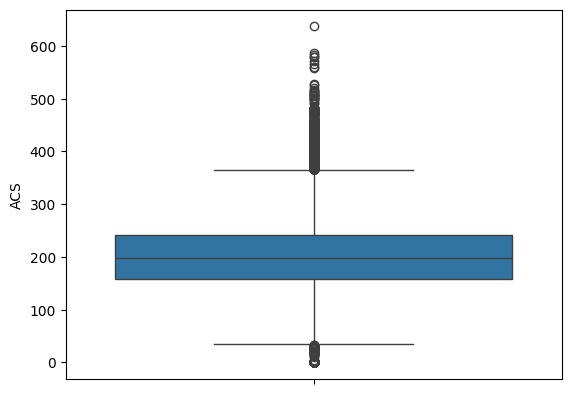

In [472]:
# Cek outlier
sns.boxplot(df_scores['ACS'])

Dari boxplot di atas, distribusi `ACS` bersifat *skewed* dan memiliki banyak *outlier*. Oleh karena itu, imputasi data pada kolom `ACS` akan dilakukan dengan memanfaatkan median dari `ACS` untuk setiap Agent.

In [473]:
acs_median = df_scores.groupby('Agent')['ACS'].median().reset_index()
acs_median

,Agent,ACS
0,astra,184.0
1,breach,170.0
2,brimstone,185.0
3,chamber,203.0
4,cypher,184.0
5,jett,226.0
6,kayo,186.0
7,killjoy,195.0
8,omen,185.0
9,phoenix,217.0


In [474]:
df_scores['ACS'] = util_scores.acs_impute(df_scores, acs_median)
df_scores['ACS'].isnull().sum()

99

> Sisa nilai null disebabkan oleh data (*row*) memiliki `Agent` bernilai null. Hal ini dapat kita abaikan saja.

Setelah itu, kita dapat menghapus data dengan kolom `ACS` bernilai 0. Hal ini dikarenakan seorang pemain dalam suatu pertandingan dan game tidak mungkin memiliki `ACS` bernilai 0, kecuali pemain tersebut adalah pemain cadangan. Namun, berdasarkan dataset `scores.csv`, pemain tersebut tergabung dengan `Game` tertentu. Dengan demikian, pemain tersebut pasti bukan pemain cadangan.

In [475]:
# Pemain dengan ACS bernilai 0
df_scores[df_scores['ACS'] == 0]

,No,GameID,PlayerID,PlayerName,TeamAbbreviation,Agent,ACS,Kills,Deaths,Assists,...,Num_4Ks,Num_5Ks,OnevOne,OnevTwo,OnevThree,OnevFour,OnevFive,Econ,Plants,Defuses
98116,121736,12079,2380.0,ZesBeeW,SMG,jett,0.0,15.0,18.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
98120,121740,12079,7380.0,niqow0w,Las,omen,0.0,12.0,19.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
98121,121741,12079,7381.0,RedKoh,Las,reyna,0.0,7.0,20.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
126399,155559,723,130.0,DPS,Roya,omen,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
126400,155560,723,129.0,hype,Roya,reyna,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128774,157934,13,24.0,Gover,NaN,NaN,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128775,157935,13,25.0,Jack1,NaN,NaN,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128776,157936,13,26.0,Rewind,NaN,NaN,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128777,157937,13,27.0,Woo1y,NaN,NaN,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [476]:
# Hapus data dengan ACS bernilai 0
index_acs_0 = df_scores[df_scores['ACS'] == 0].index
df_scores.drop(index_acs_0, inplace=True)

In [477]:
remerge()

### Data Cleaning kolom `Map`

Karena visualisasi yang dilakukan pada tahap berikutnya melibatkan kolom `Map`, kita harus memastikan kolom ini memiliki value yang sesuai.

In [478]:
df_games['Map'].value_counts()

Map
Ascent      3131
Haven       2883
Bind        2752
Split       1964
Icebox      1566
Breeze       515
Fracture      90
TBD           60
Name: count, dtype: int64

Perhatikan terdapat 60 kolom dengan value `TBD` atau `To Be Determined`. Karena tidak ada informasi pada dataset yang dapat digunakan untuk melakukan imputasi terhadap kolom tersebut, kolom `Map` dengan nilai `TBD` akan di-drop dari dataset.

In [479]:
tbd_map_index = df_games[df_games['Map'] == 'TBD'].index
df_games.drop(tbd_map_index, inplace=True)

In [480]:
remerge()

## Exploratory Data Analysis

### Persentase Agent berdasarkan `Patch`

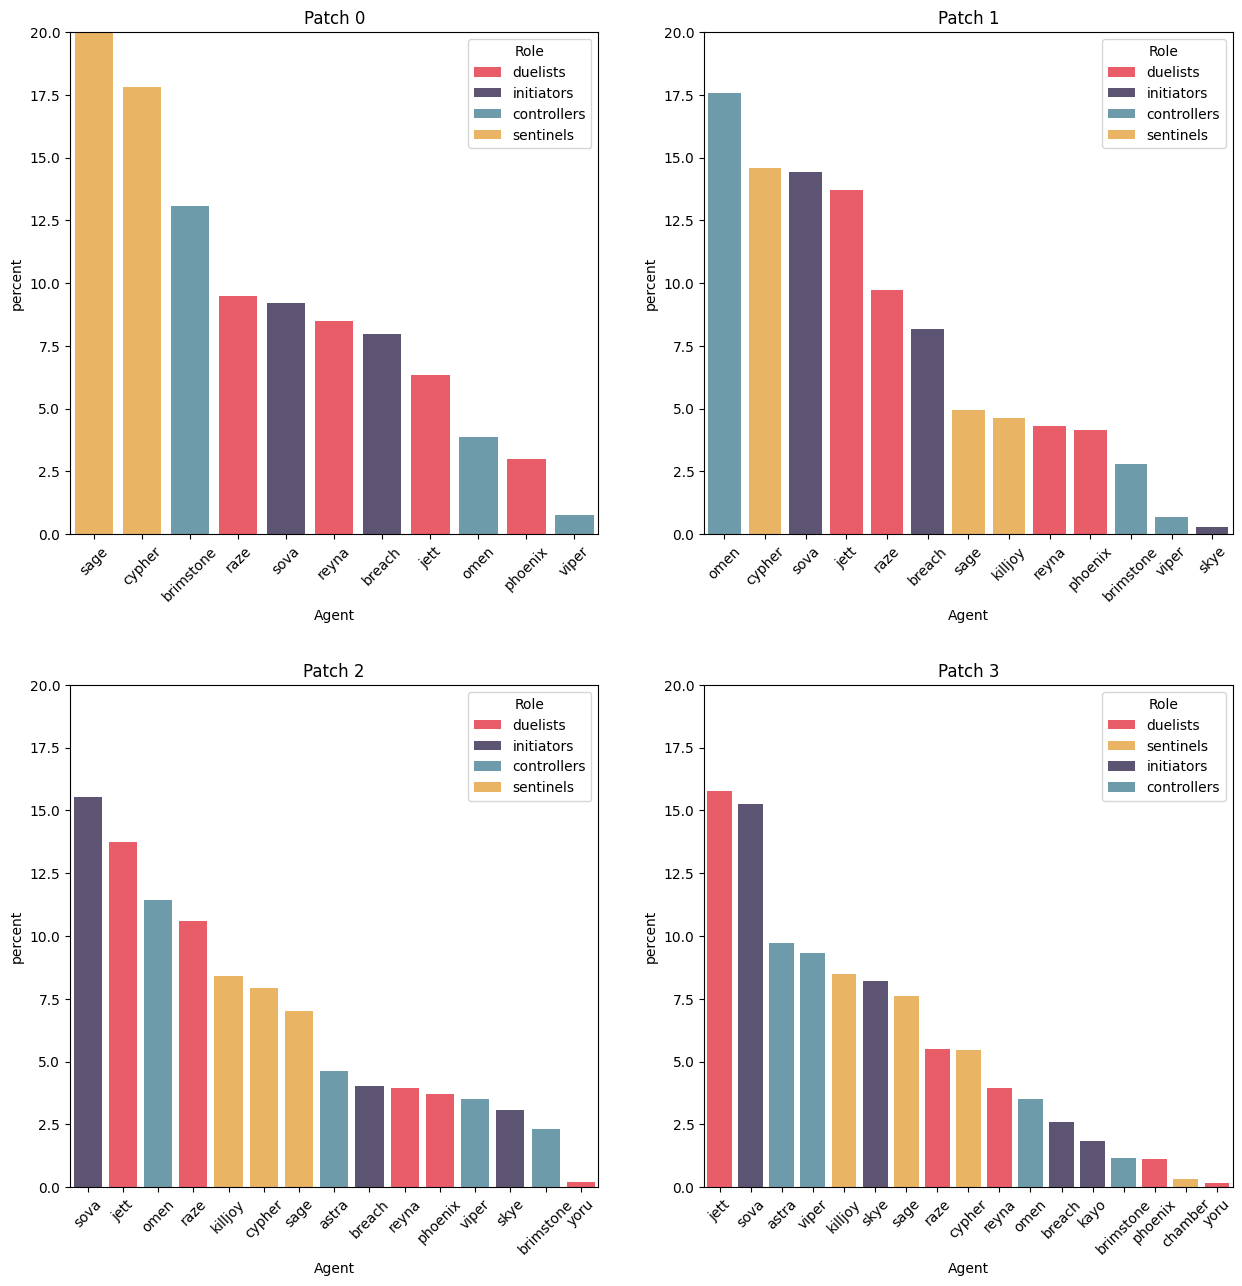

In [481]:
df_agent_patch = pd.merge(
    df_matches_games_scores[['Patch', 'Agent']],
    df_agent[['Agent', 'Role']],
    on='Agent')

patch_nums = sorted(df_agent_patch['Patch'].unique().astype(int))

lst_df_agent_patch = [
    df_agent_patch.query(f'Patch == "{patch_num}"') for patch_num in patch_nums
]

# Countplot
fig, axs = plt.subplots(2, 2, figsize=(15, 15))
plt.subplots_adjust(hspace=0.3)
axes = [(0, 0), (0, 1), (1, 0), (1, 1)]

for patch_num in patch_nums:
    current_axs = axs[axes[patch_num]]
    sns.countplot(lst_df_agent_patch[patch_num], x='Agent', hue='Role', ax=current_axs,
                  stat='percent', palette=palette_agent_role, order=lst_df_agent_patch[patch_num]['Agent'].value_counts().index)
    
    # Menyesuaikan plot
    current_axs.set_title(f'Patch {patch_num}')
    current_axs.tick_params(axis='x', labelrotation=45)
    current_axs.set_ylim(0, 20)

Distribusi Agent yang digunakan oleh pemain untuk setiap Patch 0.X, 1.X, 2.X, dan 3.X cukup bervariasi. Berdasarkan data di atas, kita mengetahui bahwa masing-masing patch memiliki `Agent` yang paling sering digunakan dalam pertandingan. Distribusi agent berdasarkan `Patch` di atas menandakan bahwa terdapat "meta" pada setiap `Patch` berkaitan dengan pemilihan agent. Meta yang berkaitan dengan `Agent` adalah `Agent` yang paling sering dipilih oleh tim dalam suatu pertandingan untuk meningkatkan kemungkinan tim untuk memenangkan pertandingan. Agent tersebut dipilih karena memiliki keuntungan tertentu (sepeti kemampuan) pada `Patch` tertentu. 

Agent-agent dengan persentase tertinggi untuk setiap `Patch` adalah sebagai berikut.

1. Patch 0: sage
2. Patch 1: omen
3. Patch 2: sova
4. Patch 3: jett

> Perhatikan bahwa pada `Patch` tertentu, kemampuan suatu `Agent` dapat berubah.

### Trend Agent berdasarkan `Patch`

In [482]:
df_agent_patch_trend = df_agent_patch.groupby('Agent').value_counts().reset_index().sort_values(by=['Agent', 'Patch', 'Role'])

def convert_count_to_percent(row):
    return row['count'] / len(lst_df_agent_patch[int(row['Patch'])])

df_agent_patch_trend['percent'] = df_agent_patch_trend.apply(convert_count_to_percent, axis='columns')
df_agent_patch_trend.head()


,Agent,Patch,Role,count,percent
1,astra,2,controllers,2020,0.046403
0,astra,3,controllers,4554,0.097032
5,breach,0,initiators,64,0.079800
2,breach,1,initiators,2895,0.081717
3,breach,2,initiators,1753,0.040269


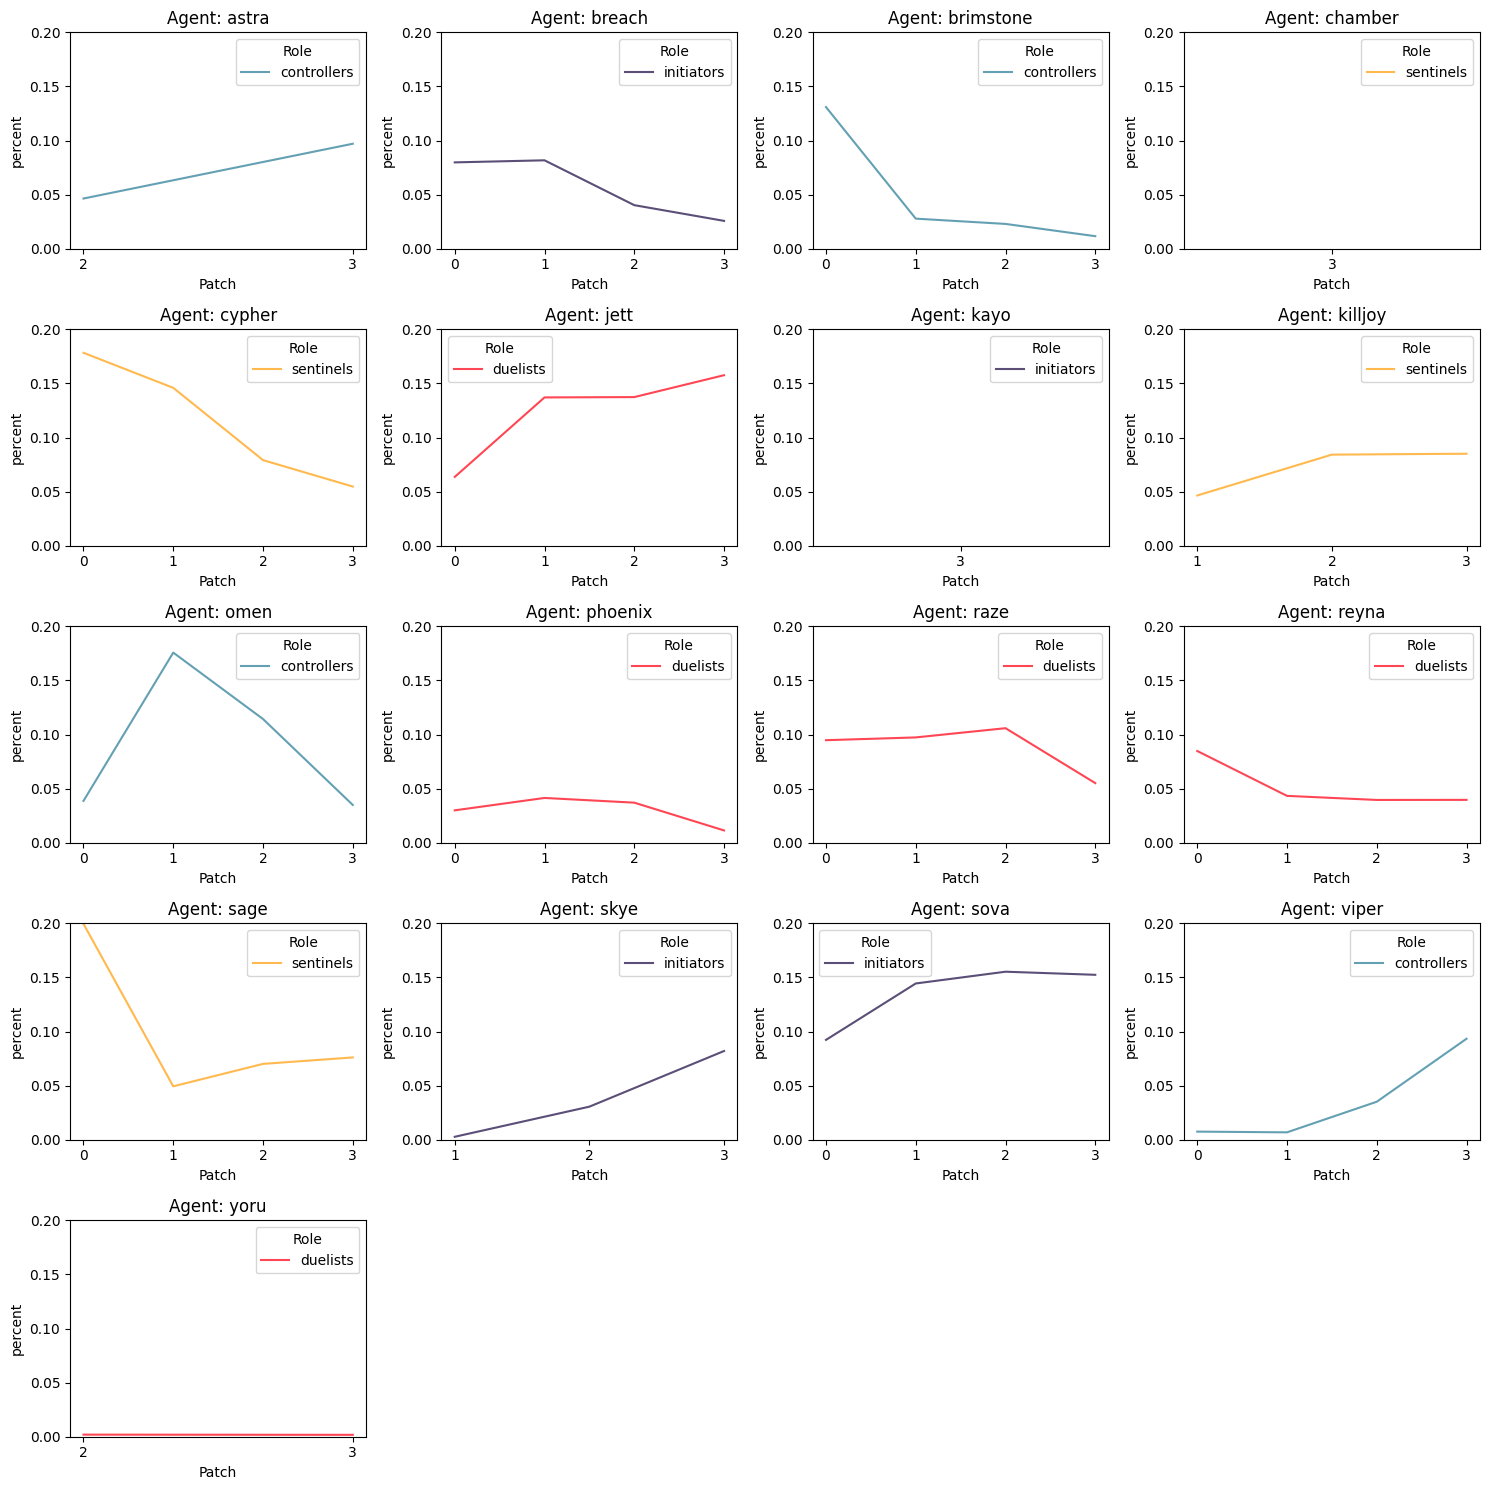

In [483]:
agents_name = df_agent['Agent'].sort_values().reset_index(drop=True)
axes = [
    (0, 0), (0, 1), (0, 2), (0, 3),
    (1, 0), (1, 1), (1, 2), (1, 3),
    (2, 0), (2, 1), (2, 2), (2, 3),
    (3, 0), (3, 1), (3, 2), (3, 3),
    (4, 0)
]

# Line chart
fig, axs = plt.subplots(5, 4, figsize=(15, 15))

for i in range(len(agents_name)):
    current_axs = axs[axes[i]]
    current_df_agent = df_agent_patch_trend.query(
        f'Agent == "{agents_name[i]}"')
    sns.lineplot(data=current_df_agent, x='Patch', y='percent', ax=current_axs, hue='Role', palette=palette_agent_role)

    # Menyesuaikan plot
    current_axs.set_title(f'Agent: {agents_name[i]}')
    current_axs.set_ylim(0, 0.2)

# Hapus subplots yang tidak terpakai
for ax in axs.flatten()[17:]:
    fig.delaxes(ax)

# Menyesuaikan layout
plt.tight_layout()

Berdasarkan line plot di atas, kita dapat mengetahui beberapa hal sebagai berikut.
1. Ada `Agent` yang mengalami penurunan pengguna pada patch yang berbeda, seperti breach, brimstone, cypher, omen, phoenix, raze, reyna, dan sage. Hal ini dapat mengindikasikan ada `Agent` lain yang lebih menguntungkan dibandingkan dengan `Agent` tersebut sehingga terjadi penurunan pada pemilihan `Agent` yang bersangkutan.
2. Ada `Agent` yang mengalami kenaikan pengguna pada patch yang berbeda, seperti astra, jett, killjoy, omen, sage, skye, sova, dan viper. Hal ini mengindikasikan agent tersebut memiliki keuntungan pada `Patch` tertentu akibat pembaruan terhadap kemampuan `Agent` yang bersangkutan. Keuntungan dalam hal kemampuan tentu diperlukan dalam turnamen pro.
3. Ada `Agent` yang baru tersedia pada `Patch` tertentu saja karena adanya pembaruan (*update*) dari game Valorant. Hal ini menyebabkan trend dari `Agent` tersebut baru dimulai pada `Patch` tertentu juga.
4. Ada berbagai faktor yang mempengaruhi trend pemilihan `Agent`, seperti perubahan kemampuan dari `Agent` pada `Patch` tertentu dan banyak `Agent` baru yang bermunculan. Hal ini dikarenakan dengan jumlah pemain yang sama dan agent yang terus bertambah, maka persentase pemilihan `Agent` juga akan terpengaruh.

> Perhatikan bahwa pada line plot kita menggunakan `percent` yang merepresentasikan persentase terpilihnya agent (*pick rate*) pada setiap patch untuk turnamen-turnamen yang ada. Hal ini dikarenakan data turnamen untuk masing-masing `Patch` berbeda sehingga kita perlu melakukan normalisasi, salah satunya dengan menggunakan `percent`/*agent pick rate*.

### Persebaran Nilai ACS Agent

#### Persebaran ACS Agent

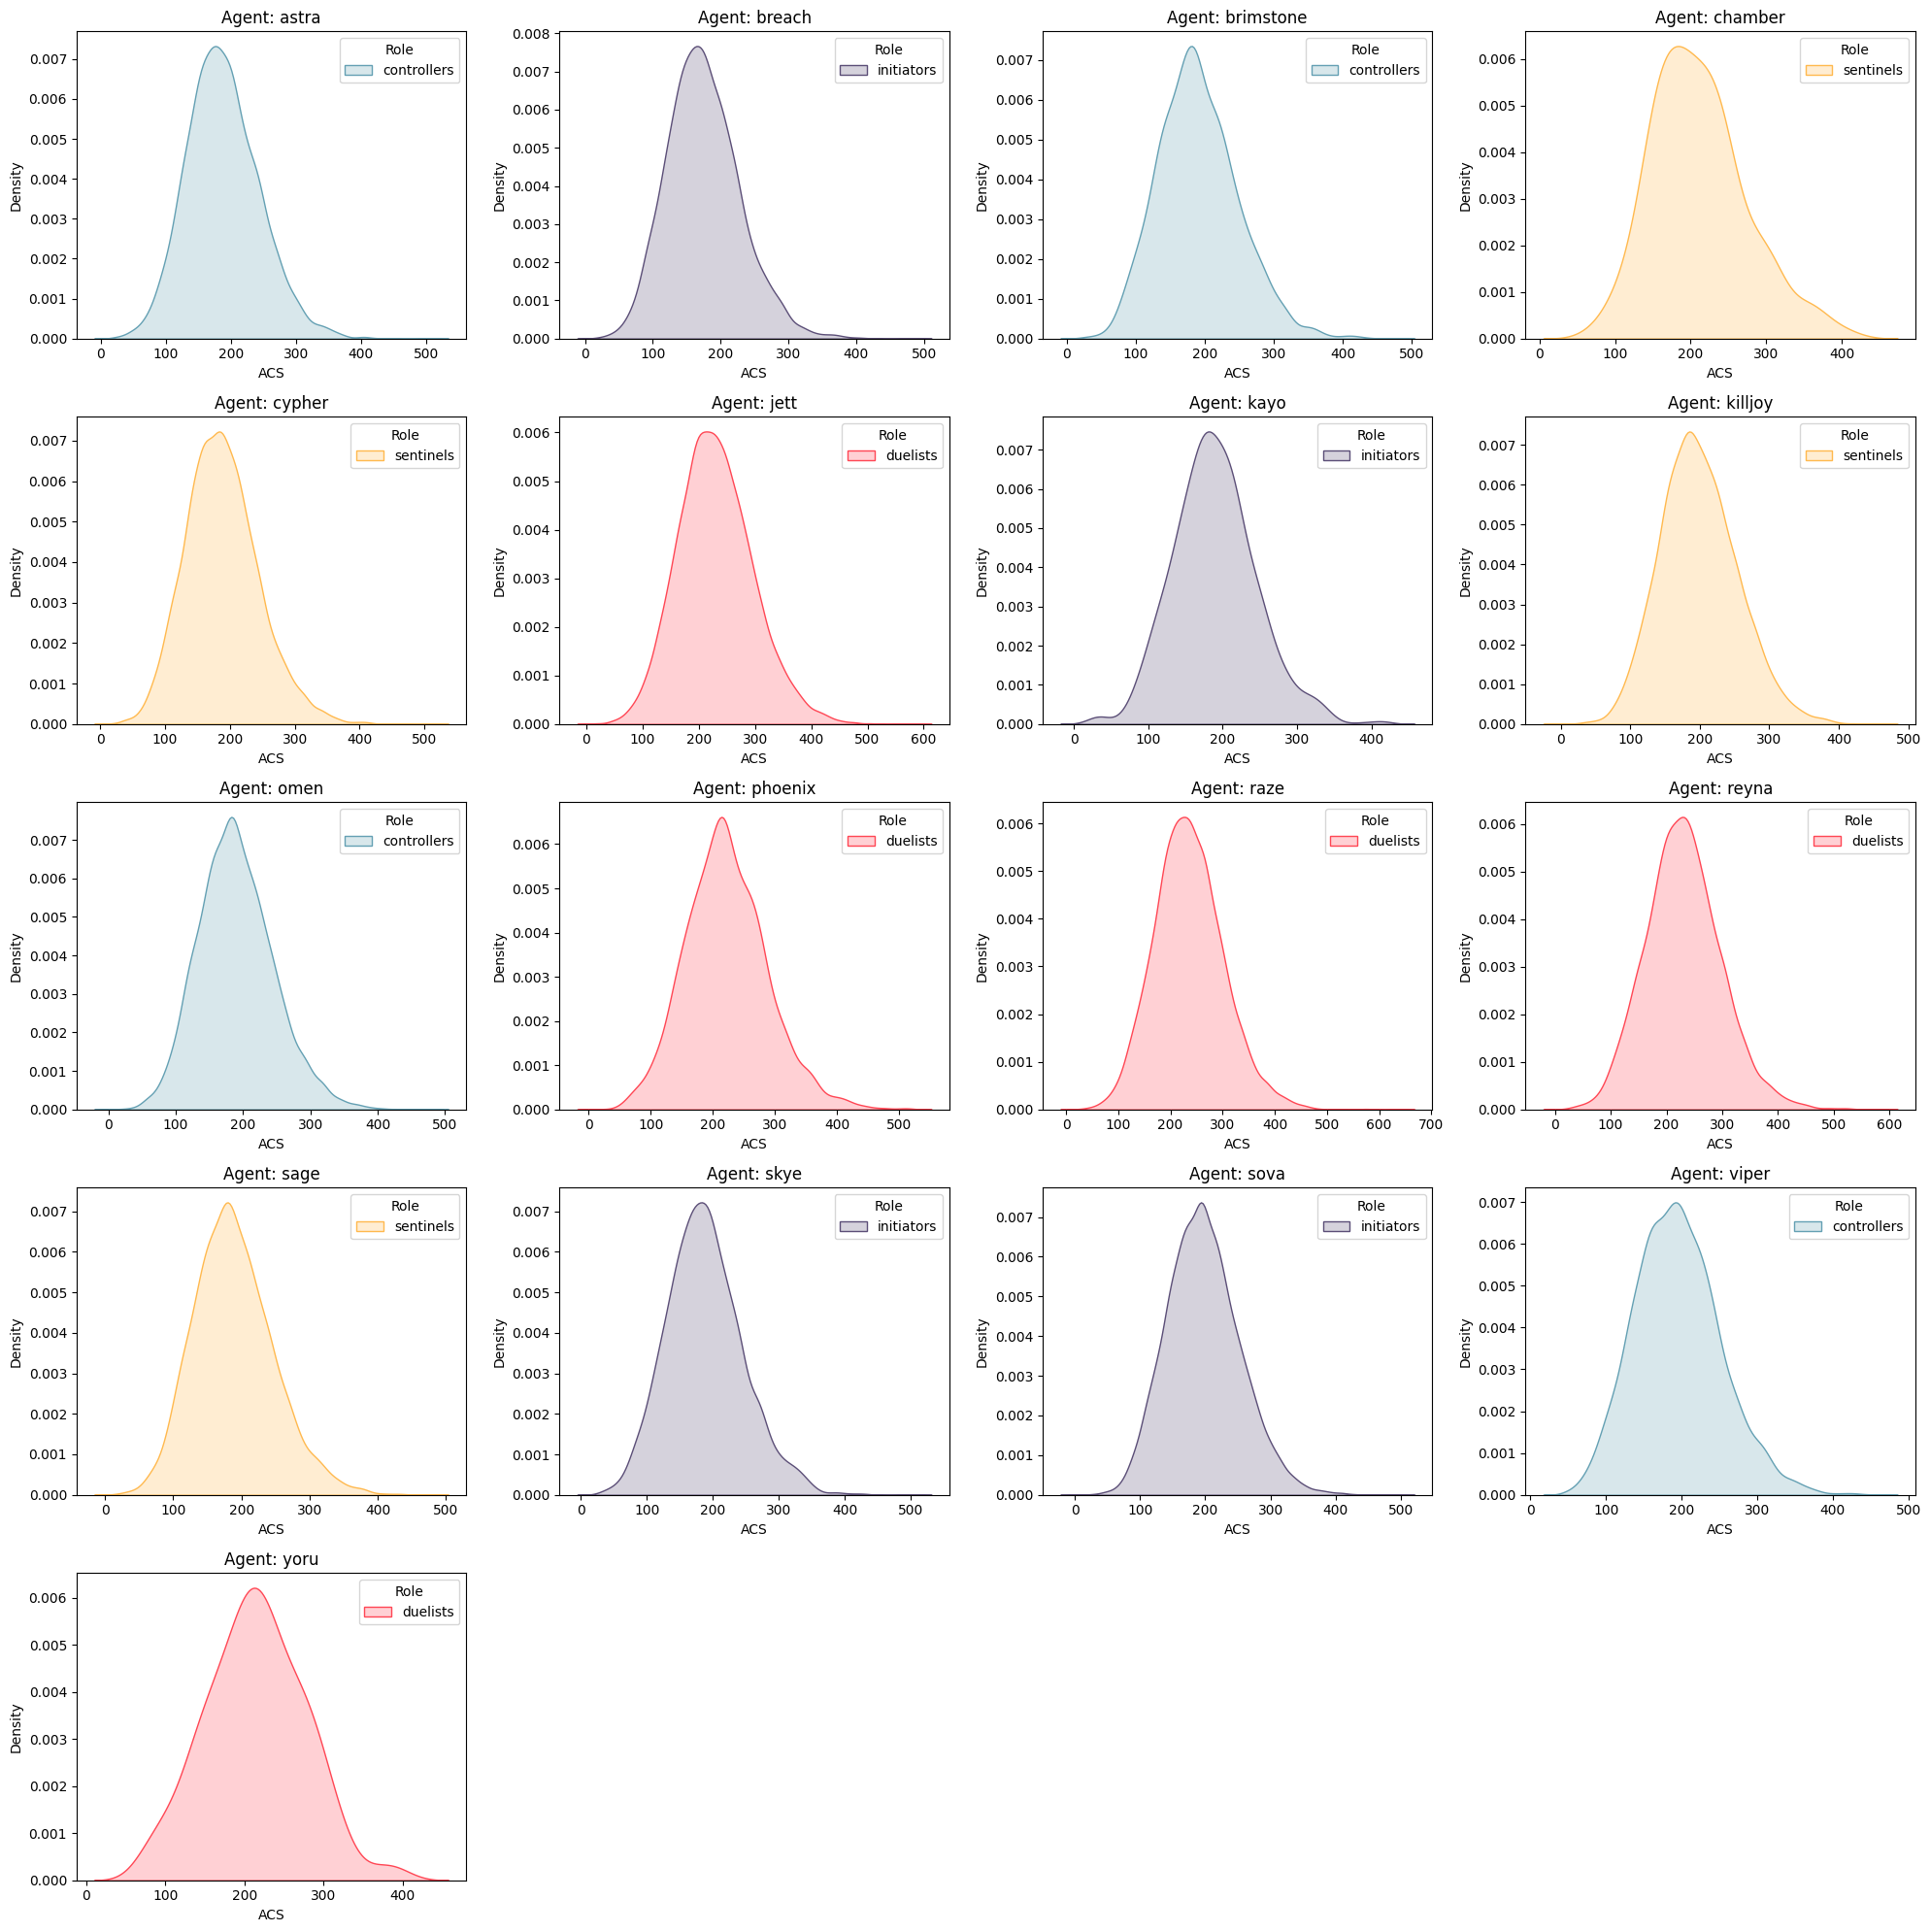

In [484]:
# Persebaran ACS untuk setiap Agent Terpisah
df_agent_acs = pd.merge(
    df_matches_games_scores[['Agent', 'ACS']],
    df_agent[['Agent', 'Role']], on='Agent'
)
lst_agents = sorted(df_agent_acs['Agent'].unique())

fig, axes = plt.subplots(5,4, figsize=(20,20))
axeses = [
    (0, 0), (0, 1), (0, 2), (0, 3),
    (1, 0), (1, 1), (1, 2), (1, 3),
    (2, 0), (2, 1), (2, 2), (2, 3),
    (3, 0), (3, 1), (3, 2), (3, 3),
    (4, 0)
]

for i in range(len(lst_agents)):

    current_axs = axes[axeses[i][0], axeses[i][1]]
    current_agent = df_agent_acs.query(f'Agent == "{lst_agents[i]}"')
    
    sns.kdeplot(data=current_agent, x='ACS', ax=current_axs, hue='Role', fill=True, palette=palette_agent_role)

    current_axs.set_title(f'Agent: {lst_agents[i]}')

for ax in axes.flatten()[17:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


Berdasarkan KDE plot di atas, distribusi `ACS` untuk setiap `Agent` cukup serupa dan terdistribusi secara normal. Perhatikan bahwa nilai `ACS` diperoleh dari perhitungan peforma pemain dalam pertandingan. Dengan demikian, pemain profesional dalam turnamen cenderung memiliki `ACS` yang tinggi tanpa memperhatikan `Agent` dan `Role` apa yang digunakan oleh pemain tersebut.

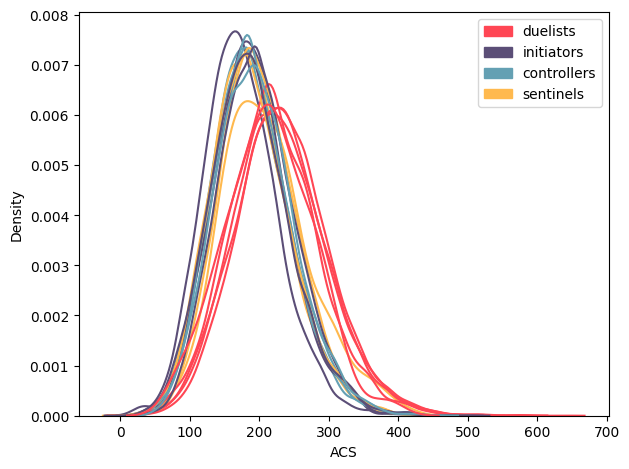

In [485]:
# Persebaran ACS untuk setiap Agent digabung
fig, ax = plt.subplots(1, 1)

for i in range(len(lst_agents)):
    current_agent = df_agent_acs.query(f'Agent == "{lst_agents[i]}"')
    sns.kdeplot(data=current_agent, x='ACS', ax=ax,
                hue='Role', palette=palette_agent_role)

handles = [mpatches.Patch(color=color, label=role)
           for role, color in palette_agent_role.items()]

ax.legend(handles=handles)
plt.tight_layout()
plt.show()

Berdasarkan KDE plot di atas, distribusi `ACS` dari `Agent` dengan `Role` duelist memiliki rata-rata `ACS` yang lebih tinggi dibandingkan dengan `Agent` dengan `Role` yang lain. Hal ini sejalan dengan peran dari `Agent` dengan `Role` duelist, yaitu bersifat ofensif dan unggul dalam pertarungan satu lawan satu dengan kemampuan yang dimilikinya. Dengan demikian, `ACS` yang merepresentasikan skor rata-rata dari pemain dengan `Agent` dengan `Role` duelist cenderung lebih tinggi dibandingkan dengan pemain yang menggunakan `Agent` dengan `Role` yang lain. 

##### Persebaran ACS Terhadap Map

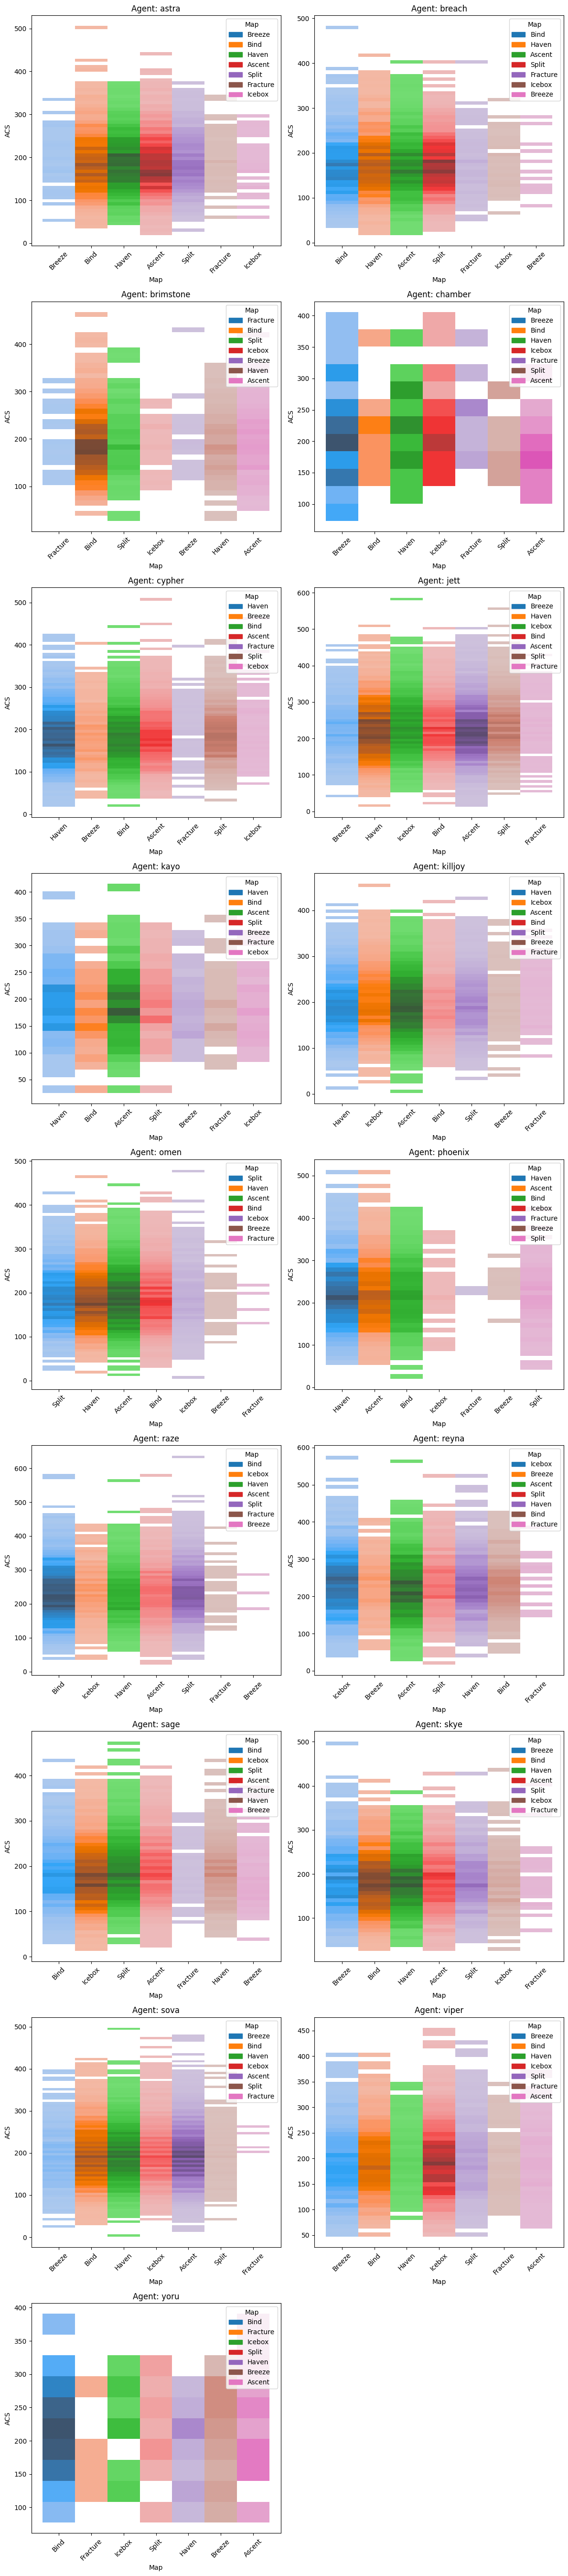

In [486]:
df_map_agent_acs = pd.merge(
    df_matches_games_scores[['Map', 'Agent', 'ACS']],
    df_agent[['Agent', 'Role']], on='Agent'
)

lst_agents = sorted(df_map_agent_acs['Agent'].unique())

num_agents = len(lst_agents)
num_columns = 2
num_rows = (num_agents + num_columns - 1) // num_columns  

fig, axes = plt.subplots(num_rows, num_columns, figsize=(12, num_rows * 6))

for idx, current_agent in enumerate(lst_agents):
    row_idx, col_idx = divmod(idx, num_columns)
    agent_data = df_map_agent_acs[df_map_agent_acs['Agent'] == current_agent]
    ax = axes[row_idx, col_idx]
    
    sns.histplot(data=agent_data, x='Map', y='ACS', hue='Map', ax=ax)
    
    ax.set_title(f'Agent: {current_agent}')
    ax.tick_params(axis='x', labelrotation=45)

if num_agents % num_columns != 0:
    for idx in range(num_agents, num_rows * num_columns):
        fig.delaxes(axes.flatten()[idx])

plt.tight_layout()

plt.show()

Berdasarkan visualisasi di atas, kita dapat mengetahui beberapa hal sebagai berikut. 

1. Distribusi `ACS` untuk setiap `Agent` pada setiap Map dapat berbeda-beda. Hal ini dapat dipengaruhi oleh kemunculan `Map` ataupun `Agent` baru pada suatu `Patch`. Dengan demikian, persebaran `ACS` yang rendah untuk suatu `Map` belum tentu mengindikasikan `Agent` tersebut tidak cocok untuk suatu `Map` tertentu.
2. Distribusi `ACS` untuk suatu `Agent` dapat dipengaruhi oleh `Map` yang sedang dimainkan. Salah satu contoh tersebut adalah pada agent Brimstone yang memiliki distribusi `ACS` yang berbeda pada saat dia berada di Map 'Bind' dengan Map 'Icebox'.
3. Jumlah penggunaan `Agent` pada setiap `Map` berbeda-beda. Hal ini dapat dilihat dari distribusi `ACS` dari `Agent` yang berbeda-beda untuk setiap `Map` yang ada.
4. `Agent` yang memiliki rata-rata `ACS` yang tinggi pada suatu `Map` tertentu mengindikasikan adanya keuntungan penggunaan `Agent` tersebut (kemampuannya cocok dan memberikan keuntungan) pada suatu `Map` tertentu. Salah satu contoh tersebut adalah agent Brimstone cukup sering dimainkan pada Map 'Bind' dibandingkan dengan Map yang lain.

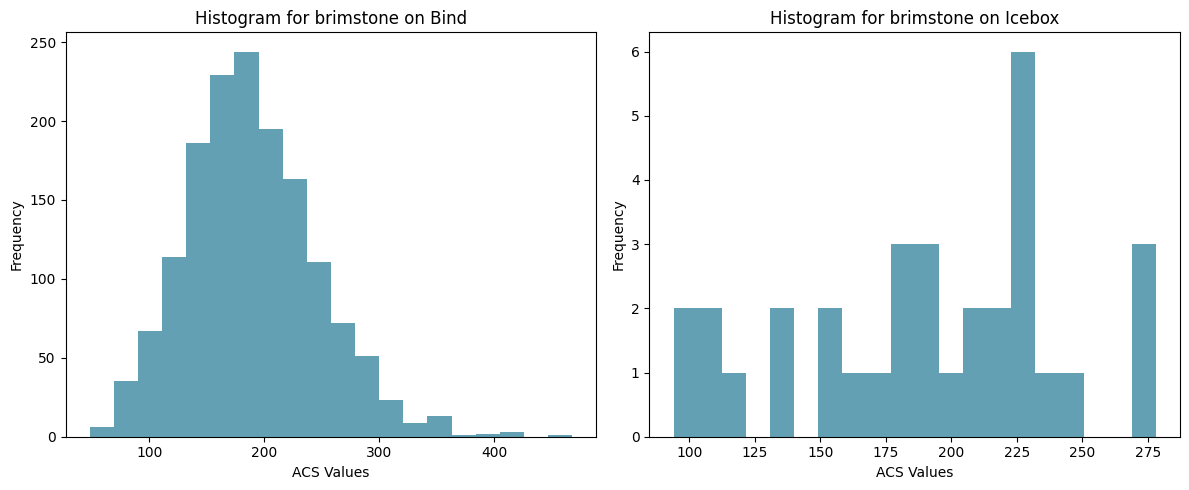

In [487]:
# Distribusi Agent Brimstone pada Map Bind dan Icebox
df_map_agent_acs = pd.merge(
    df_matches_games_scores[['Map', 'Agent', 'ACS']],
    df_agent[['Agent', 'Role']], on='Agent'
)

target_agent = 'brimstone'
target_maps = ['Bind', 'Icebox']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, target_map in enumerate(target_maps):
    target_data = df_map_agent_acs[(df_map_agent_acs['Agent'] == target_agent) & (
        df_map_agent_acs['Map'] == target_map)]

    axes[i].hist(target_data['ACS'], bins=20,
                 color=palette_agent_role['controllers'])
    axes[i].set_title(f'Histogram for {target_agent} on {target_map}')
    axes[i].set_xlabel('ACS Values')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()

plt.show()

> Seperti yang telah dijelaskan di atas, distribusi `ACS` untuk suatu `Agent` dapat dipengaruhi oleh `Map` yang sedang dimainkan. Salah satu contoh tersebut adalah pada agent Brimstone yang memiliki distribusi `ACS` yang berbeda pada saat dia berada di Map 'Bind' dengan Map 'Icebox'.

### Tim dengan Kemenangan Terbanyak pada Pertandingan Grand Final suatu Event

#### Step 1: Menghitung jumlah kemunculan setiap tim pada pertandingan grand final

In [488]:
# Select only grand final stage
df_grand_final = df_matches.loc[df_matches['EventStage'].str.contains('Grand Final')]

# Select only necessary features
df_grand_final = df_grand_final.loc[:, ('MatchID', 'Team1', 'Team2', 'Team1_MapScore', 'Team2_MapScore')]

# Menghitung jumlah kemunculan sebuah team pada grand final sebagai team1
team1 = df_grand_final.value_counts("Team1")
team1_counts = pd.DataFrame(team1).reset_index()
team1_counts.columns = ['Team', 'Count']

# Menghitung jumlah kemunculan sebuah team pada grand final sebagai team2
team2 = df_grand_final['Team2'].value_counts()
team2_counts = pd.DataFrame(team2).reset_index()
team2_counts.columns = ['Team', 'Count']

# Merge kemunculan team sebagai team1 dan team2
team_counts = pd.merge(team1_counts, team2_counts, on=['Team'], suffixes=["_1", "_2"], how='outer')
team_counts.columns = ["Team", "Team1_Count", "Team2_Count"]
team_counts.head()

,Team,Team1_Count,Team2_Count
0,Sentinels,8.0,1.0
1,TSM,7.0,NaN
2,Global Esports,7.0,2.0
3,Paper Rex,7.0,1.0
4,Wygers Argentina,6.0,1.0


In [489]:
# Mengisi NaN dengan nilai 0
team_counts = team_counts.fillna(0)
team_counts.head()

,Team,Team1_Count,Team2_Count
0,Sentinels,8.0,1.0
1,TSM,7.0,0.0
2,Global Esports,7.0,2.0
3,Paper Rex,7.0,1.0
4,Wygers Argentina,6.0,1.0


In [490]:
# Fungsi ini digunakan untuk menghitung total keseluruhan kemunculan team pada pertandignan grand final
def count_gf_matches(df:pd.DataFrame):
    return df['Team1_Count'] + df['Team2_Count']

# Hitung keseluruhan kemunculan team pada pertandingan grand final
team_counts.loc[:, "Total_Matches"] = team_counts.apply(count_gf_matches, axis=1)

team_counts = team_counts.drop(['Team1_Count', "Team2_Count"], axis=1)
team_counts = team_counts.sort_values("Total_Matches", ascending=False)
team_counts.head()

,Team,Total_Matches
6,Renegades,10.0
0,Sentinels,9.0
2,Global Esports,9.0
5,Velocity Gaming,9.0
10,forZe,8.0


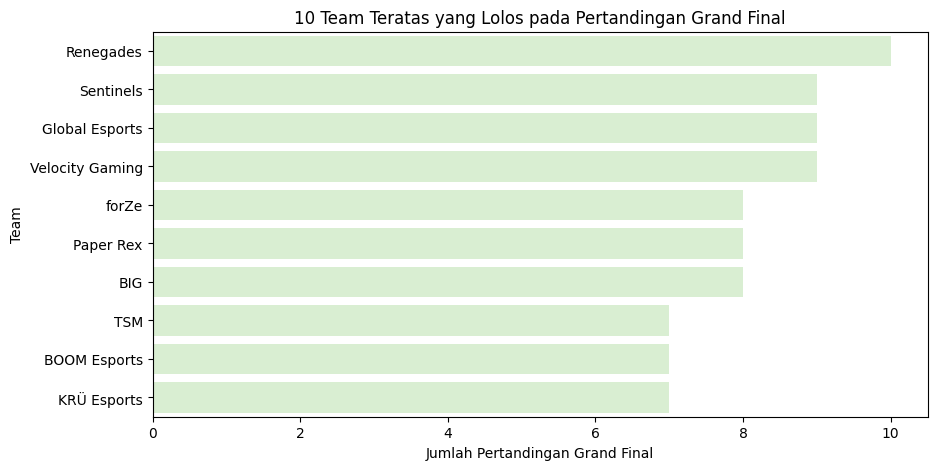

In [491]:
plt.figure(figsize=(10, 5))
sns.barplot(team_counts.iloc[0:10, :], x="Total_Matches",
            y="Team", color='#D6F3CD')
plt.title("10 Team Teratas yang Lolos pada Pertandingan Grand Final")
plt.xlabel("Jumlah Pertandingan Grand Final")
plt.show()

#### Step 2: Menghitung team yang memiliki jumlah kemenangan paling banyak pada pertandingan grand final

In [492]:
# Determine the winner based on Map Scores
def winner(df:pd.DataFrame):
    if df['Team1_MapScore'] > df['Team2_MapScore']:
        return df['Team1']
    else:
        return df['Team2']

df_grand_final.loc[:, 'Winner'] = df_grand_final.apply(winner, axis=1)
team_winner_counts = df_grand_final['Winner'].value_counts()
print(f"Tim yang paling banyak memenangkan pertandingan pada Grand Final sebuah event adalah {team_winner_counts.index[0]}.")
print(f"Dengan jumlah kemenangan sebanyak {team_winner_counts.iloc[0]} kali.")

Tim yang paling banyak memenangkan pertandingan pada Grand Final sebuah event adalah Sentinels.
Dengan jumlah kemenangan sebanyak 9 kali.


In [493]:
team_winner_counts = team_winner_counts.reset_index()
team_winner_counts.columns = ["Team", "Winner_Count"]
team_winner_counts.head()

,Team,Winner_Count
0,Sentinels,9
1,BIG,8
2,forZe,7
3,Global Esports,7
4,Renegades,7


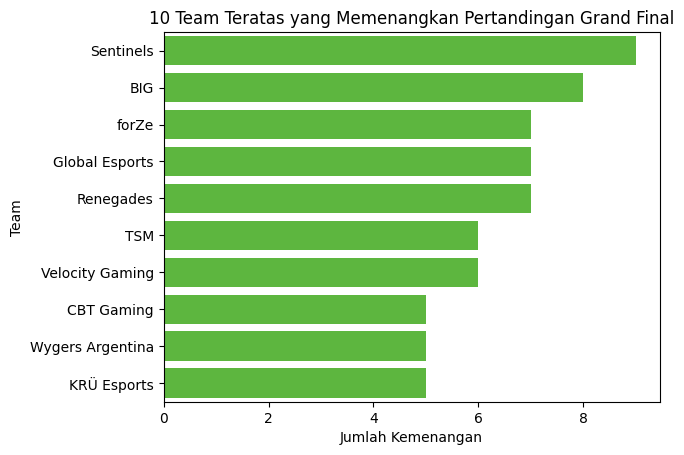

In [494]:
fig, ax = plt.subplots()
sns.barplot(team_winner_counts.loc[0:9,:], x="Winner_Count", y= "Team", color="#53CA2B", ax=ax)
plt.title("10 Team Teratas yang Memenangkan Pertandingan Grand Final")
plt.xlabel("Jumlah Kemenangan")
plt.show()

#### Step 3: Mencari 10 tim teratas dengan performa terbaik

In [495]:
team_top_10 = pd.merge(team_winner_counts, team_counts, on='Team')
team_top_10 = team_top_10.loc[0:9]
team_top_10 = team_top_10.sort_values(by=['Winner_Count', 'Total_Matches'], ascending=[False, False])
team_top_10

,Team,Winner_Count,Total_Matches
0,Sentinels,9,9.0
1,BIG,8,8.0
4,Renegades,7,10.0
3,Global Esports,7,9.0
2,forZe,7,8.0
6,Velocity Gaming,6,9.0
5,TSM,6,7.0
8,Wygers Argentina,5,7.0
9,KRÜ Esports,5,7.0
7,CBT Gaming,5,5.0


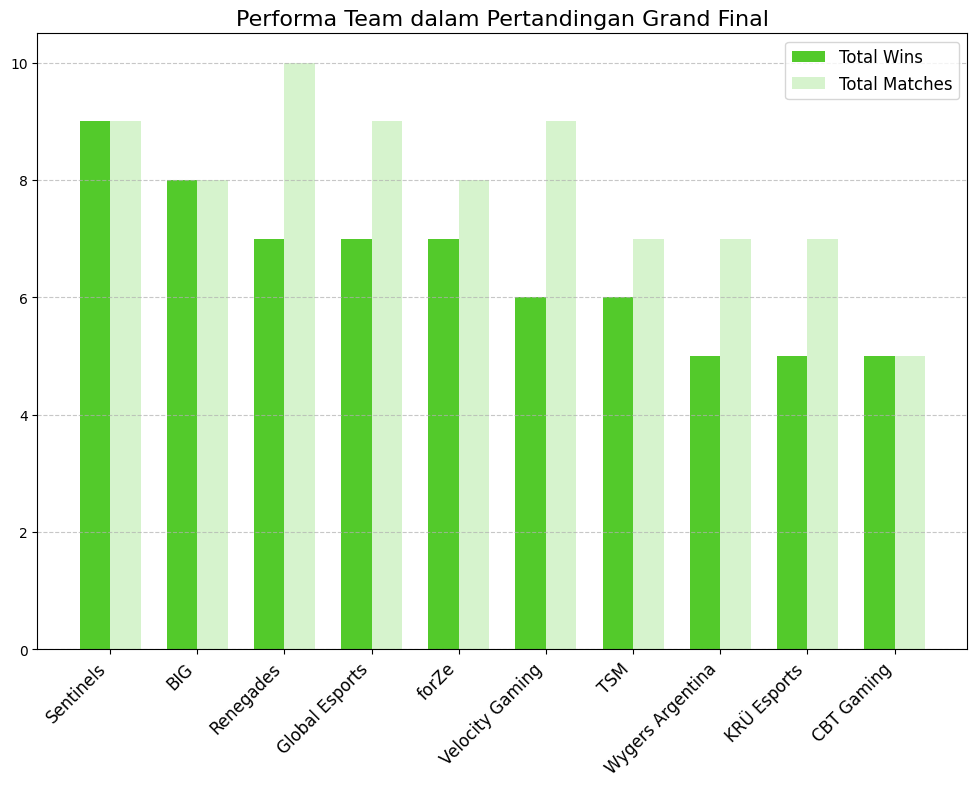

In [496]:
# Visualisasi dengan grouped bar chart
fig, ax = plt.subplots(figsize=(12, 8))

bar_width = 0.35
bar_positions1 = range(len(team_top_10))
bar_positions2 = [pos + bar_width for pos in bar_positions1]

ax.bar(bar_positions1, team_top_10['Winner_Count'], width=bar_width, label='Total Wins', color='#53CA2B')
ax.bar(bar_positions2, team_top_10['Total_Matches'], width=bar_width, label='Total Matches', color='#D6F3CD')

ax.set_xticks([pos + bar_width/2 for pos in bar_positions1])
ax.set_xticklabels(team_top_10['Team'], rotation=45, ha='right', fontsize=12)
ax.set_title('Performa Team dalam Pertandingan Grand Final', fontsize=16)

# Tambahkan Legend
ax.legend(fontsize=12)

# Tambahkan grid lines
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

plt.show()

Dari hasil visualisasi diatas, dapat disimpulkan bahwa `Tim Sentinels` memiliki performa paling baik dalam pertandingan grand final. Hal tersebut dikarenakan `Tim Sentinels` berhasil memenangkan semua pertandingan grand final yang mereka alami dengan total 9 kemenangan dari 9 pertandingan grand final, disusul oleh `Tim BIG` dengan total 8 kemenangan dari 8 pertandingan. Di sisi lain, `Tim Renegades` memegang jumlah pertandingan grand final tertinggi dengan 10 pertandingan namun hanya dapat memenangkan 7 pertandingan saja.

### Komposisi tim seperti apakah yang paling banyak memenangkan pertandingan?

#### Step 1: Mencari komposisi tim berdasarkan agent

In [497]:
# Choose necessary features
df_team_winner = df_matches_games_scores[['GameID', 'TeamAbbreviation', 'Team1_x', 'Team2_x', 'Winner', 'Agent']]

# Pisahkan antara team 1 dan team 2 berdasarkan pemenang dari suatu `Game`

# Berdasarkan team1
team1_win = df_team_winner[df_team_winner["Winner"] == 1].groupby("GameID").head(5)
team1_win.iloc[::-1].head(10)

# Filter berdasarkan gameID yang tidak memiliki agent yang bernilai null
team1_win = team1_win.groupby('GameID').filter(lambda x: not x['Agent'].isnull().any())

# Menggabungkan komposisi agent dari sebuah team dan dikelompokkan berdasarkan GameID
team1_win_grouped = team1_win[['GameID', 'Agent']].groupby("GameID")['Agent'].agg(lambda x: " ".join(x)).reset_index()
team1_win_grouped['Agent'] = team1_win_grouped['Agent'].apply(lambda agents: ' '.join(sorted(agents.split())))

# Berdasarkan team2
team2_win = df_team_winner[df_team_winner["Winner"] == 2].groupby("GameID").tail(5)

# Filter berdasarkan gameID yang tidak memiliki agent yang bernilai null
team2_win = team2_win.groupby('GameID').filter(lambda x: not x['Agent'].isnull().any())

# Menggabungkan komposisi agent dari sebuah team dan dikelompokkan berdasarkan GameID
team2_win_grouped = team2_win[['GameID', 'Agent']].groupby("GameID")['Agent'].agg(lambda x: " ".join(x)).reset_index()
team2_win_grouped['Agent'] = team2_win_grouped['Agent'].apply(lambda agents: ' '.join(sorted(agents.split())))

# Gabungkan hasil dari grouping team 1 dan team 2
team_compotition = pd.concat([team1_win_grouped, team2_win_grouped], ignore_index=True)
team_compotition = team_compotition.value_counts("Agent").reset_index()
team_compotition.head()

,Agent,count
0,cypher jett omen raze sova,451
1,jett killjoy sage sova viper,428
2,cypher jett omen phoenix sova,401
3,jett reyna sage sova viper,388
4,breach cypher jett omen sova,380


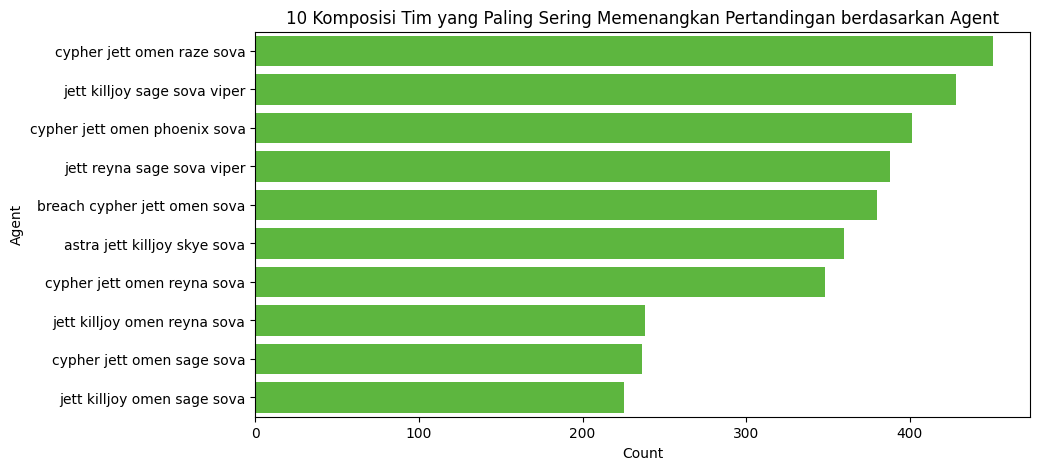

In [498]:
plt.figure(figsize=(10, 5))
sns.barplot(team_compotition.iloc[0:10,:], x="count", y= "Agent", color='#53CA2B')
plt.title("10 Komposisi Tim yang Paling Sering Memenangkan Pertandingan berdasarkan Agent")
plt.xlabel("Count")
plt.show()

In [499]:
import plotly.graph_objects as go

# Visualisasi dengan table
all_agents = df_agent['Agent'].tolist()

# Split the agent combination into individual agents
agent_combination = team_compotition.loc[0:9]['Agent'].str.split(expand=True)

# Create a binary mapping of agent combination
binary_mapped = agent_combination.apply(lambda row: [1 if agent in row.values else 0 for agent in all_agents], axis=1, result_type='expand')
binary_mapped['Total Usages'] = team_compotition['count']

# Assign color for each cell 
colors = ['rgb(214,243,205)', 'rgb(83,202,43)']
cell_colors = [np.array(colors)[binary_mapped[col]] for col in binary_mapped.drop(columns='Total Usages').columns]
cell_colors.append(['rgb(255, 255, 255)'] * len(binary_mapped))

# Assign value for each cell
cell_values = [[''] * len(binary_mapped)] * (len(binary_mapped.columns) - 1)
cell_values.append(binary_mapped['Total Usages'].tolist())

fig = go.Figure(data=[go.Table(
    header=dict(values=all_agents + ['Total Usages'],
                font=dict(color='black', size=10.5)),
    cells=dict(values=cell_values,
               fill_color=cell_colors,
               align='center', font=dict(color='black', size=12),
               height=40)
)])

fig.update_layout(
    title='10 Komposisi Tim yang Paling Sering Memenangkan Pertandingan berdasarkan Agent',
    title_x=0.5,
    width=1100,  
    height=700,  
)

annotation = """
Color Legend:
<span style="color:#53CA2B">■</span> Used
<span style="color:#D6F3CD">■</span> Unused
"""

fig.add_annotation(
    text=annotation,
    xref="paper",
    yref="paper",
    x=0,
    y=0.1,
    showarrow=False,
    font=dict(size=15),
)

fig.show()

Berdasarkan visualisasi tersebut, terlihat bahwa komposisi agent dalam sebuah tim yang sering memmenangkan bertandingan cukup bervariasi dan tidak terlalu condong kepada salah satu komposisi saja. Hal tersebut dilihat dari nilai pada kolom `Total Usages` suatu komposisi yang memiliki perbedaan nilai cukup kecil antara suatu komposisi dengan komposisi lainnya. Selain itu, terdapat agent yang selalu dipilih sebagai komposisi sebuah tim yaitu `jett` dan `sova`. Hal tersebut menunjukkan bahwa `jett` dan `sova` merupakan agent yang selalu masuk dalam META (*Most Effective Tactic Available*) yang digunakan oleh sebuah tim disusul oleh agent `omen` dan `cypher` yang cukup sering dipilih juga. Di sisi lain, terdapat agent yang bahkan tidak dipilih dalam komposisi sebuah tim yaitu `kayo`, `chamber`, `brimstone`, dan `yoru`. 

#### Step 2: Mencari komposisi tim yang paling banyak memenangkan pertandingan berdasarkan role dari agent

In [500]:
# Menambahkan kolom role 
role_encoder = dict(zip(df_agent_role['Agent'], df_agent_role['Role']))
team1_win.loc[:,'Role'] = team1_win.loc[:,'Agent'].replace(role_encoder)
team2_win.loc[:,'Role'] = team2_win.loc[:,'Agent'].replace(role_encoder)

# Menggabungkan komposisi role dari sebuah team dan dikelompokkan berdasarkan GameID
team1_win_grouped_by_role = team1_win[['GameID', 'Role']].groupby("GameID")['Role'].agg(lambda x: " ".join(x)).reset_index()
team1_win_grouped_by_role['Role'] = team1_win_grouped_by_role['Role'].apply(lambda role: ' '.join(sorted(role.split())))
team1_win_grouped_by_role.value_counts("Role").head()

# Menggabungkan komposisi role dari sebuah team dan dikelompokkan berdasarkan GameID
team2_win_grouped_by_role = team2_win[['GameID', 'Role']].groupby("GameID")['Role'].agg(lambda x: " ".join(x)).reset_index()
team2_win_grouped_by_role['Role'] = team2_win_grouped_by_role['Role'].apply(lambda role: ' '.join(sorted(role.split())))
team2_win_grouped_by_role.value_counts("Role").head()

# Gabungkan hasil grouping team 1 dan team 2
team_compotition_by_role = pd.concat([team1_win_grouped_by_role, team2_win_grouped_by_role], ignore_index=True)
team_compotition_by_role = team_compotition_by_role.value_counts("Role").reset_index()
team_compotition_by_role.head()

,Role,count
0,controllers duelists duelists initiators senti...,4687
1,controllers duelists initiators initiators sen...,2746
2,controllers duelists initiators sentinels sent...,2364
3,controllers controllers duelists initiators se...,633
4,controllers duelists duelists sentinels sentinels,613


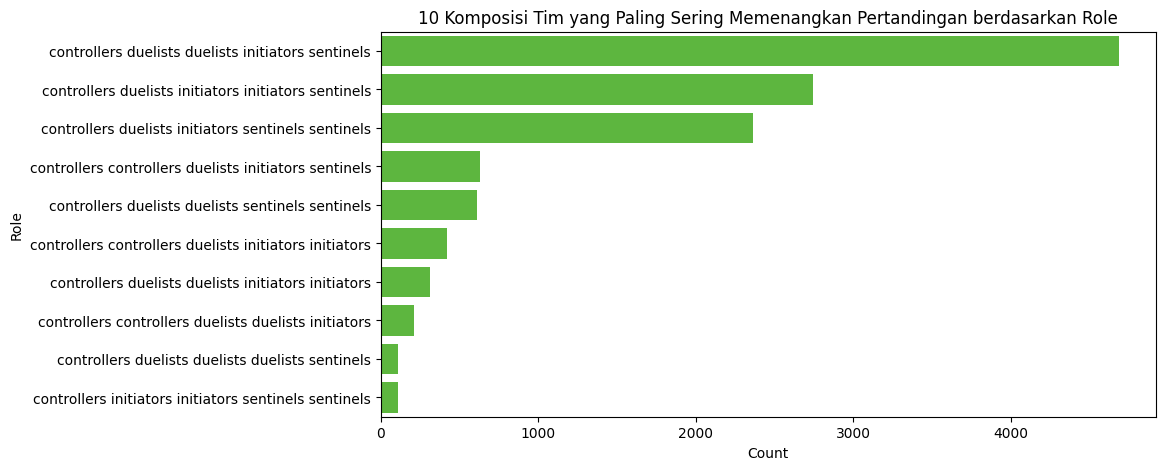

In [501]:
plt.figure(figsize=(10, 5))
sns.barplot(team_compotition_by_role.iloc[0:10,:], x="count", y= "Role", color="#53CA2B")
plt.title("10 Komposisi Tim yang Paling Sering Memenangkan Pertandingan berdasarkan Role")
plt.xlabel("Count")
plt.show()

In [502]:
from collections import Counter
# Visualize with table
all_roles = df_agent['Role'].drop_duplicates(keep='first').tolist()

# Split the role combination into individual role
role_combination = team_compotition_by_role.loc[0:9]['Role'].str.split(expand=True)

# Create a mapping of role combination
role_mapped = role_combination.apply(lambda row: [Counter(row.values)[role] if role in row.values else 0 for role in all_roles], axis=1, result_type='expand')
role_mapped['Total Usages'] = team_compotition_by_role['count']

# Assign color for each cell 
colors = ['rgb(214,243,205)', 'rgb(147,226,120)', 'rgb(83,202,43)', 'rgb(48,118,25)', 'rgb(14,33,7)']
cell_colors = [np.array(colors)[role_mapped[col]] for col in role_mapped.drop(columns='Total Usages').columns]
cell_colors.append(['rgb(255, 255, 255)'] * len(role_mapped))

# Assign value for each cell
cell_values = [[''] * len(role_mapped)] * (len(role_mapped.columns) - 1)
cell_values.append(role_mapped['Total Usages'].tolist())

fig = go.Figure(data=[go.Table(
    header=dict(values=all_roles + ['Total Usages'],
                font=dict(color='black', size=13)),
    cells=dict(values=cell_values,
               fill_color=cell_colors,
               align='center', font=dict(color='black', size=12),
               height=40)
)])

fig.update_layout(
    title='10 Komposisi Tim yang Paling Sering Memenangkan Pertandingan berdasarkan Role',
    title_x=0.5,
    width=1100,  
    height=700,  
)

annotation = """
Color Legend:
<span style="color:#D6F3CD">■</span> Unused
<span style="color:#93E278">■</span> Used 1 Times
<br>
<span style="color:#53CA2B">■</span> Used 2 Times
<span style="color:#307619">■</span> Used 3 Times
"""

fig.add_annotation(
    text=annotation,
    xref="paper",
    yref="paper",
    x=0,
    y=-0.01,
    showarrow=False,
    font=dict(size=30),
)

fig.show()

Berdasarkan visualisasi tersebut, terlihat bahwa kombinasi role yang sering memenangkan pertandingan cukup bervariasi namun condong terhadap salah satu kombinasi yaitu dengan `2 duelist`, `1 initators`, `1 controllers,` dan `1 sentinels` dengan total penggunaan sebanyak 4687. Disusul oleh kombinasi `1 duelist`, `2 initators`, `1 controllers,` dan `1 sentinels` serta `1 duelist`, `1 initators`, `1 controllers,` dan `2 sentinels` dengan total penggunaan sebanyak setengah dari kombinasi pertama. Selain itu, meskipun terdapat 4 role dalam game valorant, ternyata tidak semua role dipilih dalam sebuah pertandingan, namun terdapat satu role yang selalu diplih dalam kombinasi sebuah tim yaitu `Controllers`. 

### Persentase Agent berdasarkan `Map`

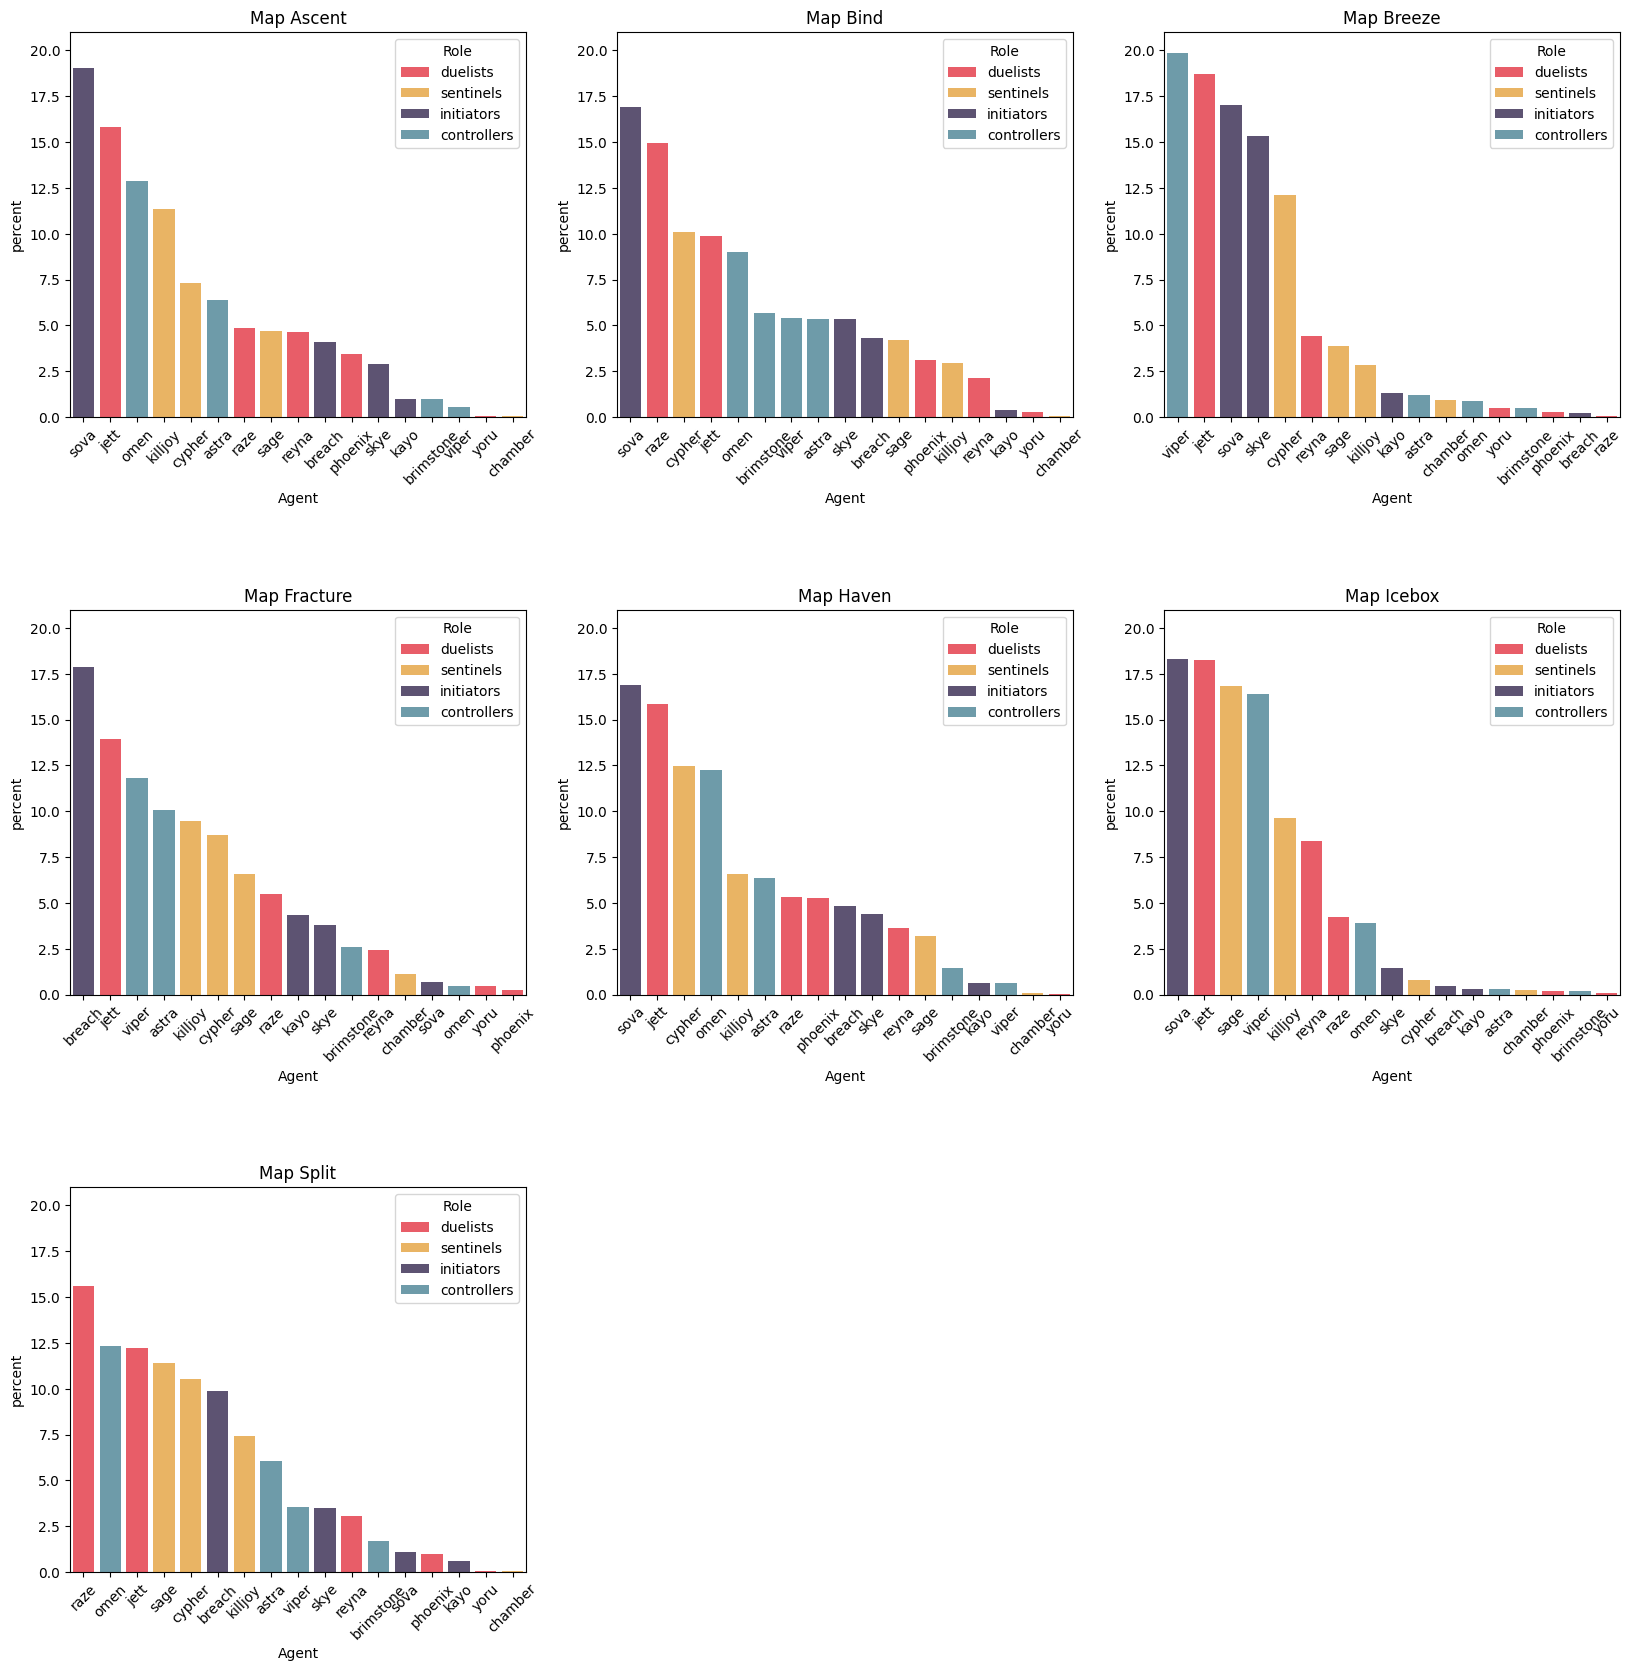

In [503]:
df_agent_patch = pd.merge(
    df_matches_games_scores[['Map', 'Agent']],
    df_agent[['Agent', 'Role']],
    on='Agent')

game_maps = sorted(df_agent_patch['Map'].unique())

lst_df_agent_map = [
    df_agent_patch.query(f'Map == "{game_map}"') for game_map in game_maps
]

# Countplot
fig, axs = plt.subplots(3, 3, figsize=(20, 20))
plt.subplots_adjust(hspace=0.5)
axes = [
    (0, 0), (0, 1), (0, 2),
    (1, 0), (1, 1), (1, 2),
    (2, 0), (2, 1), (2, 2),
]

for index_map, game_map in enumerate(game_maps):
    current_axs = axs[axes[index_map]]
    sns.countplot(lst_df_agent_map[index_map], x='Agent', hue='Role', ax=current_axs,
                  stat='percent', palette=palette_agent_role, order=lst_df_agent_map[index_map]['Agent'].value_counts().index)
    
    # Menyesuaikan plot
    current_axs.set_title(f'Map {game_map}')
    current_axs.tick_params(axis='x', labelrotation=45)
    current_axs.set_ylim(0, 21)

for ax in axs.flatten()[7:]:
    fig.delaxes(ax)

Berdasarkan distribusi `Agent` untuk setiap `Map`, `Agent` yang digunakan oleh pemain untuk setiap `Map` cukup bervariasi. Berdasarkan data di atas, kita mengetahui bahwa masing-masing `Map` memiliki `Agent` yang paling sering digunakan. Distribusi `Agent` berdasarkan `Map` di atas menandakan adanya keuntungan yang dimiliki oleh `Agent` tertentu pada suatu `Map` untuk meningkatkan kemungkinan tim untuk memenangkan pertandingan. Hal ini dikarenakan `Agent` tertentu bisa saja memiliki kemampuan yang baik dan cocok dengan `Map` tertentu. Misalnya, pada map `Split`, `Agent` dengan role `initators` tidak terlalu banyak digunakan dibandingkan dengan map lainnya karena kemampuan `Agent` dengan role `initiators`mungkin tidak terlalu dibutuhkan. Selain itu, berdasarkan visualisasi di atas, kita dapat mengetahui bahwa ada pengaruh pemilihan `Agent` dengan `Map` yang digunakan dalam pertandingan.

Agent-agent dengan persentase tertinggi untuk setiap `Map` adalah sebagai berikut.

1. Ascent: sova
2. Bind: sova
3. Breeze: viper
4. Fracture: breach
5. Haven: sova
6. Icebox: sova
7. Split: raze

> Perhatikan bahwa ada beberapa `Agent` yang baru tersedia pada `Patch` tertentu. Dengan demikian, persentase pemilihan `Agent` tersebut akan cenderung lebih rendah dibandingkan dengan `Agent` lain.

### Agent Statistik

In [504]:
# Function to calculate KDA
def calculate_kda(df: pd.DataFrame):
    kills = df['Kills']
    deaths = df['Deaths']
    assists = df['Assists']

    if deaths == 0:
        return (kills + assists)
    else:
        return (kills + assists) / deaths


In [505]:
# Calculate KDA for each player
df_player_kda = df_scores.copy()
df_player_kda['KDA'] = df_player_kda.apply(calculate_kda, axis=1)
df_player_kda.head()

,No,GameID,PlayerID,PlayerName,TeamAbbreviation,Agent,ACS,Kills,Deaths,Assists,...,Num_5Ks,OnevOne,OnevTwo,OnevThree,OnevFour,OnevFive,Econ,Plants,Defuses,KDA
0,0,60894,8419.0,Reduxx,Boos,jett,313.0,24.0,10.0,3.0,...,0.0,1.0,0.0,0.0,0.0,0.0,74.0,0.0,0.0,2.700000
1,1,60894,466.0,ChurmZ,Boos,chamber,227.0,16.0,10.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,67.0,2.0,0.0,2.300000
2,2,60894,3712.0,diaamond,Boos,sova,226.0,17.0,9.0,8.0,...,0.0,1.0,0.0,0.0,0.0,0.0,58.0,3.0,0.0,2.777778
3,3,60894,5099.0,Boltzy,Boos,viper,218.0,17.0,12.0,2.0,...,0.0,1.0,0.0,0.0,0.0,0.0,48.0,0.0,0.0,1.583333
4,4,60894,3983.0,Virtyy,Boos,skye,80.0,5.0,13.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,21.0,0.0,0.0,0.615385


Pada kasus ini kita akan memfilter GameID dengan kondisi yang valid. Kondisi yang valid terpenuhi apabila dalam satu GameID terdapat 2 tim yang bertanding dan masing-masing tim memiliki 5 pemain yang bermain

In [506]:
df_player_kda = df_player_kda.groupby('GameID').filter(lambda x: len(x) == 10)

In [507]:
# Merge dengan dataset games untuk mendapatkan informasi pemenang sebuah game
df_agent_stats = pd.merge(df_player_kda, df_games[['GameID', 'Winner']], on='GameID')
df_agent_stats.head()

,No,GameID,PlayerID,PlayerName,TeamAbbreviation,Agent,ACS,Kills,Deaths,Assists,...,OnevOne,OnevTwo,OnevThree,OnevFour,OnevFive,Econ,Plants,Defuses,KDA,Winner
0,0,60894,8419.0,Reduxx,Boos,jett,313.0,24.0,10.0,3.0,...,1.0,0.0,0.0,0.0,0.0,74.0,0.0,0.0,2.700000,1
1,1,60894,466.0,ChurmZ,Boos,chamber,227.0,16.0,10.0,7.0,...,0.0,0.0,0.0,0.0,0.0,67.0,2.0,0.0,2.300000,1
2,2,60894,3712.0,diaamond,Boos,sova,226.0,17.0,9.0,8.0,...,1.0,0.0,0.0,0.0,0.0,58.0,3.0,0.0,2.777778,1
3,3,60894,5099.0,Boltzy,Boos,viper,218.0,17.0,12.0,2.0,...,1.0,0.0,0.0,0.0,0.0,48.0,0.0,0.0,1.583333,1
4,4,60894,3983.0,Virtyy,Boos,skye,80.0,5.0,13.0,3.0,...,0.0,0.0,0.0,0.0,0.0,21.0,0.0,0.0,0.615385,1


In [508]:
# Update nilai pada kolom 'Winner' untuk team2 jika pemenang dalam game tersebut adalah team1
team1_winner = df_agent_stats[df_agent_stats['Winner'] == 1].groupby("GameID").head(5)
team2_loser = df_agent_stats[df_agent_stats['Winner'] == 1].groupby("GameID").tail(5)
team2_loser['Winner'] = 0

team1_winner = pd.concat([team1_winner, team2_loser], axis=0, ignore_index=False).sort_index()

# Update nilai pada kolom 'Winner' untuk team1 jika pemenang dalam game tersebut adalah team2
team2_winner = df_agent_stats[df_agent_stats['Winner'] == 2].groupby("GameID").tail(5)
team1_loser = df_agent_stats[df_agent_stats['Winner'] == 2].groupby("GameID").head(5)
team1_loser['Winner'] = 0
team2_winner['Winner'] = 1

team2_winner = pd.concat([team2_winner, team1_loser], axis=0, ignore_index=False).sort_index()

In [509]:
# Merge team1 and team2
df_agent_stats = pd.concat([team1_winner, team2_winner], axis=0, ignore_index=False).sort_index()
df_agent_stats = df_agent_stats.rename(columns={'Winner':'Win'})
df_agent_stats.head()


,No,GameID,PlayerID,PlayerName,TeamAbbreviation,Agent,ACS,Kills,Deaths,Assists,...,OnevOne,OnevTwo,OnevThree,OnevFour,OnevFive,Econ,Plants,Defuses,KDA,Win
0,0,60894,8419.0,Reduxx,Boos,jett,313.0,24.0,10.0,3.0,...,1.0,0.0,0.0,0.0,0.0,74.0,0.0,0.0,2.700000,1
1,1,60894,466.0,ChurmZ,Boos,chamber,227.0,16.0,10.0,7.0,...,0.0,0.0,0.0,0.0,0.0,67.0,2.0,0.0,2.300000,1
2,2,60894,3712.0,diaamond,Boos,sova,226.0,17.0,9.0,8.0,...,1.0,0.0,0.0,0.0,0.0,58.0,3.0,0.0,2.777778,1
3,3,60894,5099.0,Boltzy,Boos,viper,218.0,17.0,12.0,2.0,...,1.0,0.0,0.0,0.0,0.0,48.0,0.0,0.0,1.583333,1
4,4,60894,3983.0,Virtyy,Boos,skye,80.0,5.0,13.0,3.0,...,0.0,0.0,0.0,0.0,0.0,21.0,0.0,0.0,0.615385,1


In [510]:
# Fungsi ini digunakan untuk menghitung win rate sebuah agent
def calculate_winrate(df: pd.DataFrame):
    return (df['Win']/df['Total Pick'])*100

In [511]:
# Menghitung win rate dari sebuah agent
agent_pick_count = df_agent_stats['Agent'].value_counts()
agent_total_win = df_agent_stats.groupby('Agent', sort=False)['Win'].sum()

df_agent_pick_count = agent_pick_count.reset_index().rename(columns={'index': 'Agent', 'count':'Total Pick'})
df_agent_total_win = agent_total_win.reset_index().rename(columns={'index': 'Agent'})

df_agent_win_rate = pd.merge(df_agent_pick_count, df_agent_total_win, on='Agent')
df_agent_win_rate['Win Rate'] = df_agent_win_rate.apply(calculate_winrate, axis=1)
df_agent_win_rate = df_agent_win_rate.drop(columns=['Total Pick', 'Win'])
df_agent_win_rate

,Agent,Win Rate
0,sova,50.140026
1,jett,50.138274
2,omen,49.619100
3,cypher,49.421811
4,raze,50.324706
5,killjoy,51.164807
6,sage,51.966458
7,astra,51.202696
8,viper,50.596308
9,breach,47.900017


In [512]:
# Fungsi ini digunakan untuk menghitung pick rate dari sebuah agent
def calculate_pickrate(df: pd.DataFrame):
    return (df['Total Pick']/len(df_agent_stats))*100

In [513]:
# Menghitung pick rate untuk setiap agent
df_agent_pick_rate = df_agent_pick_count.copy()
df_agent_pick_rate['Pick Rate'] = df_agent_pick_rate.apply(calculate_pickrate, axis=1)
df_agent_pick_rate = df_agent_pick_rate.drop(columns='Total Pick')
df_agent_pick_rate

,Agent,Pick Rate
0,sova,15.000793
1,jett,14.331008
2,omen,10.092739
3,cypher,8.910907
4,raze,8.421845
5,killjoy,7.315314
6,sage,6.711319
7,astra,5.173589
8,viper,4.851776
9,breach,4.661541


In [514]:
# Hitung rata-rata ACS, Kills, Deaths, Assists, dan KDA untuk setiap agent
df_agent_stats = df_agent_stats.groupby('Agent', sort=False)[['ACS', 'Kills', 'Deaths', 'Assists', 'KDA']].mean().reset_index()
df_agent_stats

,Agent,ACS,Kills,Deaths,Assists,KDA
0,jett,229.499889,16.568579,15.043779,3.320144,1.436737
1,chamber,211.089172,15.299363,13.808917,2.751592,1.449676
2,sova,197.253527,13.739013,13.836440,6.888859,1.672736
3,viper,194.749551,13.920399,14.230794,5.624551,1.534212
4,skye,187.788952,13.834604,14.619855,5.369284,1.444890
5,astra,187.673204,13.902805,14.021003,5.877357,1.579301
6,raze,235.130071,16.160283,15.311604,4.722453,1.473769
7,sage,188.636825,13.731745,14.345187,6.393551,1.559773
8,kayo,189.122970,13.523202,14.532483,8.676334,1.679252
9,killjoy,198.933037,14.091491,14.170623,3.823957,1.396107


In [515]:
# Gabungkan statistik sebelumnya dengan Win Rate, Pick Rate, dan Total Pick untuk setiap agent
df_agent_stats = pd.merge(df_agent_stats, df_agent_win_rate, on='Agent')
df_agent_stats = pd.merge(df_agent_stats, df_agent_pick_rate, on='Agent')
df_agent_stats = pd.merge(df_agent_stats, df_agent_pick_count[['Agent', 'Total Pick']], on='Agent')
df_agent_stats['Role'] = df_agent_stats['Agent'].replace(role_encoder)
df_agent_stats

,Agent,ACS,Kills,Deaths,Assists,KDA,Win Rate,Pick Rate,Total Pick,Role
0,jett,229.499889,16.568579,15.043779,3.320144,1.436737,50.138274,14.331008,18080,duelists
1,chamber,211.089172,15.299363,13.808917,2.751592,1.449676,55.414013,0.124445,157,sentinels
2,sova,197.253527,13.739013,13.836440,6.888859,1.672736,50.140026,15.000793,18925,initiators
3,viper,194.749551,13.920399,14.230794,5.624551,1.534212,50.596308,4.851776,6121,controllers
4,skye,187.788952,13.834604,14.619855,5.369284,1.444890,50.571429,4.161382,5250,initiators
5,astra,187.673204,13.902805,14.021003,5.877357,1.579301,51.202696,5.173589,6527,controllers
6,raze,235.130071,16.160283,15.311604,4.722453,1.473769,50.324706,8.421845,10625,duelists
7,sage,188.636825,13.731745,14.345187,6.393551,1.559773,51.966458,6.711319,8467,sentinels
8,kayo,189.122970,13.523202,14.532483,8.676334,1.679252,48.491879,0.683259,862,initiators
9,killjoy,198.933037,14.091491,14.170623,3.823957,1.396107,51.164807,7.315314,9229,sentinels


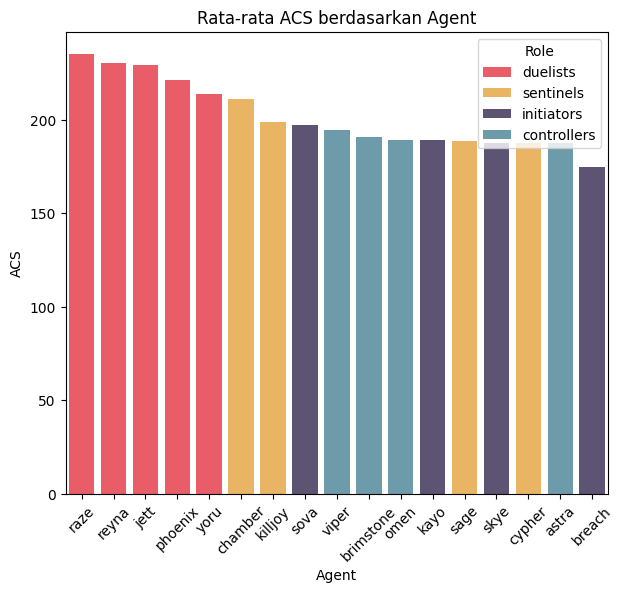

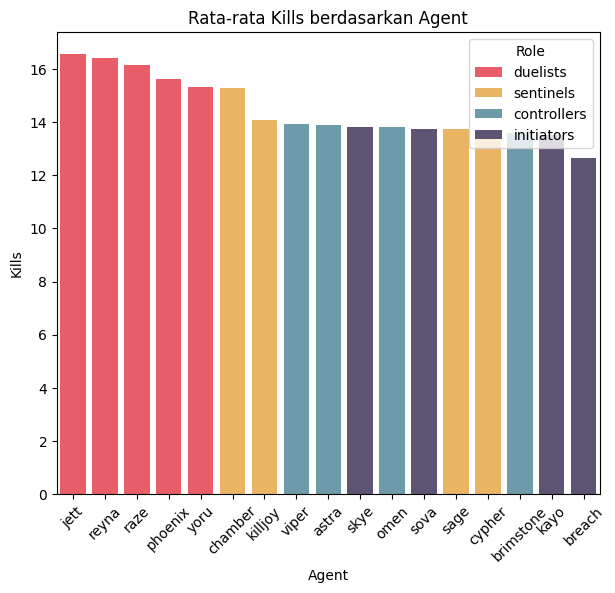

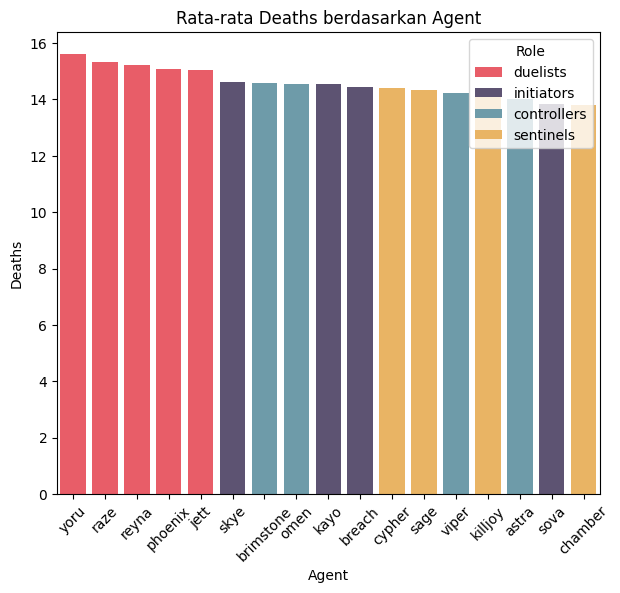

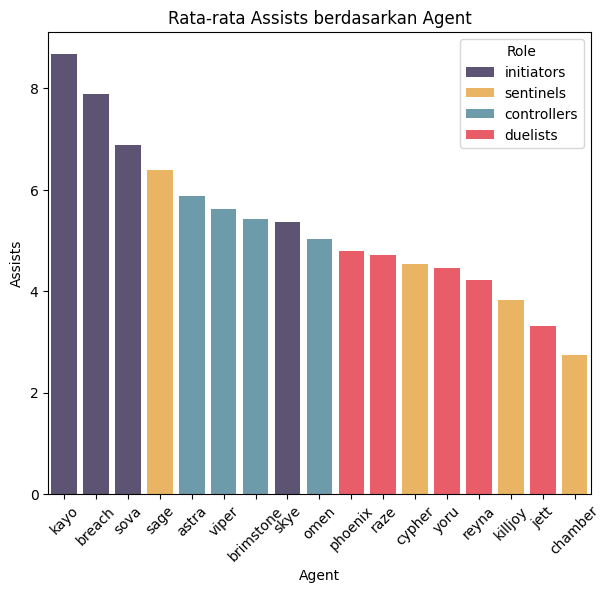

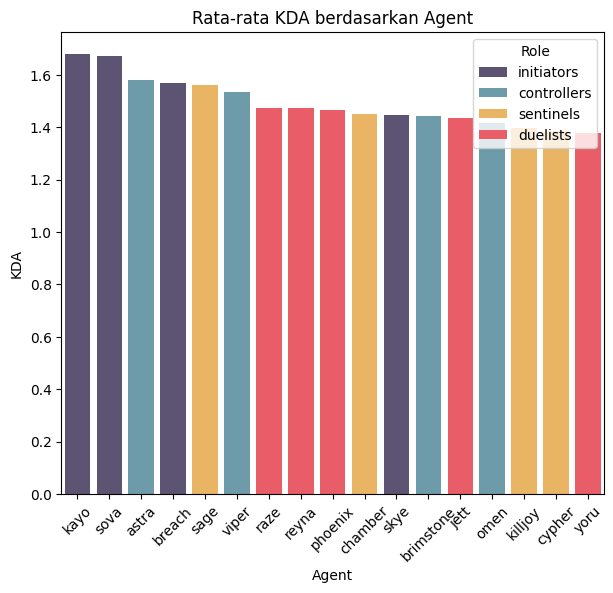

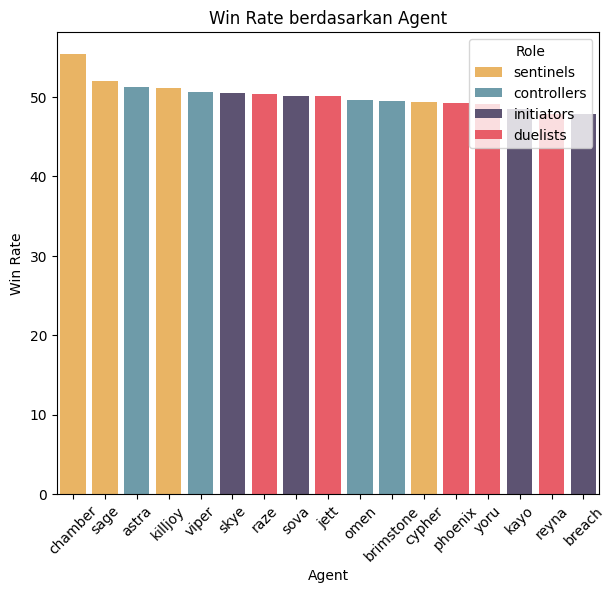

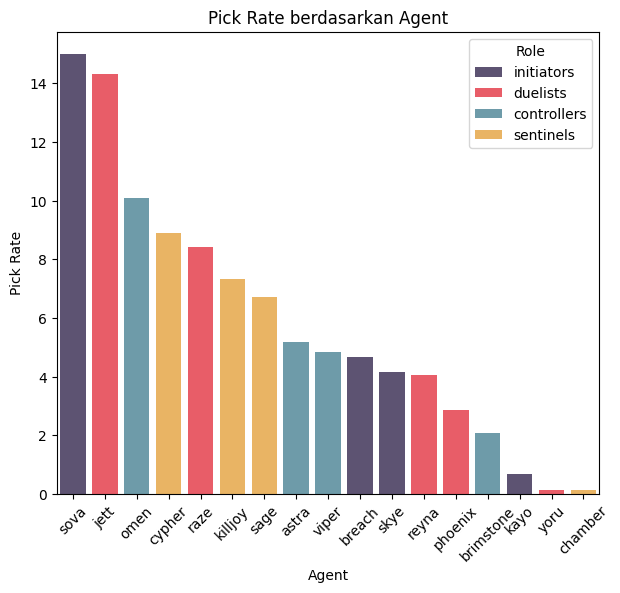

In [516]:
# Plotting untuk setiap stats
for col_stats in df_agent_stats.columns[1:-2]:
    plt.figure(figsize=(7, 6))
    df_agent_stats_sorted = df_agent_stats.sort_values(col_stats, ascending=False)
    sns.barplot(df_agent_stats_sorted, x='Agent', hue='Role', y=col_stats, order=df_agent_stats_sorted['Agent'],
                palette=palette_agent_role)
    if col_stats == 'Win Rate' or col_stats == 'Pick Rate' or col_stats == 'Total Pick':
        plt.title(f'{col_stats} berdasarkan Agent')
    else:
        plt.title(f'Rata-rata {col_stats} berdasarkan Agent')
    plt.xlabel('Agent')
    plt.xticks(rotation=45)
    plt.ylabel(col_stats)

Berdasarkan rata-rata ACS, Kills, dan Deaths, agent yang memiliki nilai rata-rata tertinggi didominasi oleh agent dengan role `duelists`. Hal tersebut sesuai dengan role `duelists` itu sendiri yang berperan untuk membuka jalan bagi rekan satu tim untuk masuk ke wilayah musuh dan berfokus untuk mendapatkan kill dan memberikan damage kepada musuh
Berdasarkan rata-rata Assists, agent yang memiliki nilai rata-rata tertinggi didominasi oleh agent dengan role `inititators`. Hal tersebut sesuai dengan peran `initiators` yaitu untuk menggali informasi mengenai musuh dan menggunakan ability mereka untuk membantu rekan satu  tim ketika berhadapan dengan musuh

Agent dengan pick rate tertinggi merupakan agent yang termasuk dalam komposisi tim berdasarkan agent yang sering digunakan yaitu `Jett`, `Sova`, `Omen`, `Cypher`, dan `Raze`.
`Chamber` merupakan agent dengan win rate tertinggi, namun hal tersebut disebabkan `Chamber` termasuk agent yang baru dikenalkan oleh Valorant dan memiliki pick rate terendah.

## Data Preprocessing

Tahap pemrosesan ini dilakukan dengan melanjutkan tahap sebelumnya yang telah dilakukan agar dapat menghasilkan dataset yang baik, *clean*, dan dapat dimanfaatkan dengan maksimal oleh model clustering dan machine learning.

### Dataset `matches.csv`

In [517]:
df_matches.isna().sum()

No                0
MatchID           0
Date              0
Patch             0
EventID           0
EventName         0
EventStage        0
Team1ID           0
Team2ID           0
Team1             0
Team2             0
Team1_MapScore    0
Team2_MapScore    0
dtype: int64

Berdasarkan informasi di atas, tidak terdapat kolom dengan baris bernilai null. Dengan demikian, kita tidak perlu menghapus baris tertentu.

In [518]:
df_matches.head()

,No,MatchID,Date,Patch,EventID,EventName,EventStage,Team1ID,Team2ID,Team1,Team2,Team1_MapScore,Team2_MapScore
0,0,62393,2022-01-08,3,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Decider (A),6903,6020,Booster Seat Gaming,Pho Real,2,1
1,1,62403,2022-01-08,3,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Decider (C),7046,7047,Bjor's Kittens,Mugiwara,2,0
2,2,62391,2022-01-08,3,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Winner's (A),6461,6903,Akrew,Booster Seat Gaming,2,1
3,3,62396,2022-01-08,3,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Winner's (B),6164,7043,Radiance,sameROFLMAO,2,0
4,5,62402,2022-01-08,3,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Elimination (C),7047,3545,Mugiwara,CLG Red,2,0


Berdasarkan informasi di atas, semua kolom sudah berisi nilai yang sesuai. Namun, ada beberapa hal yang dapat kita perhatikan.

1. Kolom `EventName` dan `EventStage` bersifat kategorikal dan berisi value yang bervariasi. Hal ini dapat diabaikan (tidak diproses lebih lanjut) karena kolom-kolom tersebut tidak akan diikutsertakan dalam training dataset suatu model. Hal ini dikarenakan `EventName` dan `EventStage` terlalu banyak (bervariasi), tetapi tidak terlalu mempengaruhi `Agent` yang digunakan ataupun `ACS` seorang pemain pada pertandingan tertentu.
2. Kolom `Date` dapat diproses lebih lanjut dengan menghapus bagian hari pada value yang ada. Hal ini dikarenakan tahun dan bulan saja pada `Date` dapat merepresentasikan nomor **act** (`Y`) dan **patch** (`Z`) tertentu yang mungkin dapat mempengaruhi pemilihan `Agent` pada **Patch** `X.YZ`.

#### Transformasi Kolom `Date`

Transformasi kolom `Date` dilakukan dengan menghitung selisih hari antara `Date` dari pertandingan dengan `Date` dari perilisan game Valorant ke publik. Hal ini dapat dimanfaatkan untuk mengetahui rentang hari antara pertandingan relatif terhadap waktu perilisan game Valorant ke publik, yaitu 2 Juni 2020.

In [519]:
# Proses Kolom Date
df_matches['Date'] = util_matches.date_transform_remove_day(df_matches)
df_matches.head()

,No,MatchID,Date,Patch,EventID,EventName,EventStage,Team1ID,Team2ID,Team1,Team2,Team1_MapScore,Team2_MapScore
0,0,62393,2022-01,3,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Decider (A),6903,6020,Booster Seat Gaming,Pho Real,2,1
1,1,62403,2022-01,3,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Decider (C),7046,7047,Bjor's Kittens,Mugiwara,2,0
2,2,62391,2022-01,3,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Winner's (A),6461,6903,Akrew,Booster Seat Gaming,2,1
3,3,62396,2022-01,3,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Winner's (B),6164,7043,Radiance,sameROFLMAO,2,0
4,5,62402,2022-01,3,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Elimination (C),7047,3545,Mugiwara,CLG Red,2,0


Kemudian, ubah kolom `Date` menjadi representasi jumlah hari antara suatu pertandingan dengan waktu game Valorant di-publish petama kali (2 Juni 2020). Dengan demikian, kolom ini dapat diproses oleh model machine learning yang mengharapkan fitur berupa numerikal.

In [520]:
df_matches['Date'] = util_matches.date_diff_transform(df_matches)

#### Buat Kolom `Team_MapScore`

Kolom `Team_MapScore` dibuat dengan menghitung rata-rata antara `Team1_MapScore` dan `Team2_MapScore`. Hal ini bertujuan untuk mengurangi dimensi dari feature dan agar kolom `Team1_MapScore` dan `Team2_MapScore` dapat dimanfaatkan dengan lebih mudah oleh model machine learning yang dibangun. 

In [521]:
df_matches['Team_MapScore'] = util_matches.create_team_mapscore_avg(df_matches)

### Dataset `games.csv`

In [522]:
df_games.isna().sum()

No                     0
GameID                 0
MatchID                0
Map                    0
Team1ID                0
Team2ID                0
Team1                  0
Team2                  0
Winner                 0
Team1_Eco            974
Team1_SemiEco        974
Team1_SemiBuy        974
Team1_FullBuy        974
Team1_TotalRounds      0
Team2_Eco            974
Team2_SemiEco        974
Team2_SemiBuy        974
Team2_FullBuy        974
Team2_TotalRounds      0
dtype: int64

#### Imputasi Kolom `Team1_Eco`, `Team1_SemiEco`, `Team1_SemiBuy`, `Team1_FullBuy`, `Team2_Eco`, `Team2_SemiEco`, `Team2_SemiBuy`, dan `Team2_FullBuy`

Beberapa kolom masih mengandung baris dengan nilai null. Kolom-kolom tersebut adalah `Team1_Eco`, `Team1_SemiEco`, `Team1_SemiBuy`, `Team1_FullBuy`, `Team2_Eco`, `Team2_SemiEco`, `Team2_SemiBuy`, dan `Team2_FullBuy`. Kita dapat melakukan imputasi terhadap kolom ini dengan memperhatikan statistik berupa median dari masing-masing kolom per `Team` dan median secara global. Hal ini diperlukan karena Ekonomi pada Valorant dapat mempengaruhi senjata yang dapat dibeli dan semakin bagus senjata yang digunakan dapat meningkatkan `ACS` dari seorang pemain. Contohnya, ketika suatu `Team` melakukan `Eco`, senjata yang dapat diperoleh oleh `Team` tersebut adalah pistol, sedangkan ketika suatu `Team` melakukan `FullBuy`, senjata yang dapat diperoleh adalah rifle. Perhatikan bahwa `pistol` memiliki fire rate dan damage yang lebih kecil dibandingkan dengan rifle. Hal ini tentu dapat mempengaruhi `ACS` pemain pada suatu tim. Namun, untuk pemain pro, kita tetap harus melihat korelasinya terlebih dahulu.

Statistik median digunakan karena jumlah Eco, SemiEco, SemiBuy, dan FullBuy dipengaruhi oleh ronde yang dimainkan dalam suatu game sebagai berikut. 

1. Karena kondisi *win by two* harus terpenuhi dalam suatu game, ronde yang dimainkan dalam suatu game bisa lebih dari 13 ronde. Semakin banyak jumlah ronde, kolom `FullBuy` dan `SemiBuy` juga akan semakin meningkat. 
2. Selain itu, kolom `Eco`, `SemiEco`, dan `SemiBuy` juga sangat dipengaruhi oleh kemenangan tim dalam suatu ronde. Hal ini dikarenakan semakin sering tim menang, maka kolom `Eco` akan semakin berkurang, sebaliknya juga berlaku.

Berdasarkan hal di atas, kolom `Team_Eco`, `Team_SemiEco`, `Team_SemiBuy`, dan `Team_FullBuy` cenderung memiliki outlier. Oleh karena itu, median lebih cocok digunakan untuk melakukan imputasi.

In [523]:
# Menentukan median dari kolom ekonomi per team
# Team 1
df_team1_economy = df_games[['GameID', 'Team1ID', 'Team1_Eco', 'Team1_SemiEco', 'Team1_SemiBuy', 'Team1_FullBuy']].rename(columns={
    'Team1ID': 'TeamID',
    'Team1_Eco': 'Team_Eco',
    'Team1_SemiEco': 'Team_SemiEco',
    'Team1_SemiBuy': 'Team_SemiBuy',
    'Team1_FullBuy': 'Team_FullBuy',
})
df_team2_economy = df_games[['GameID', 'Team2ID', 'Team2_Eco','Team2_SemiEco', 'Team2_SemiBuy', 'Team2_FullBuy']].rename(columns={
    'Team2ID': 'TeamID',
    'Team2_Eco': 'Team_Eco',
    'Team2_SemiEco': 'Team_SemiEco',
    'Team2_SemiBuy': 'Team_SemiBuy',
    'Team2_FullBuy': 'Team_FullBuy',
})
df_team_economy = pd.concat([df_team1_economy, df_team2_economy]).drop_duplicates()
df_team_econ_median = df_team_economy.groupby(by='TeamID')[['Team_Eco', 'Team_SemiEco', 'Team_SemiBuy', 'Team_FullBuy']].median()
df_team_econ_median.head()

,Team_Eco,Team_SemiEco,Team_SemiBuy,Team_FullBuy
TeamID,,,,
2,3.0,1.0,4.0,12.0
3,3.0,1.0,5.0,12.0
4,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN


In [524]:
# Menentukan median dari kolom ekonomi secara global
srs_econ_median = df_team_economy.median()
srs_econ_median.drop(['GameID', 'TeamID'], inplace=True)
srs_econ_median

Team_Eco         3.0
Team_SemiEco     1.0
Team_SemiBuy     4.0
Team_FullBuy    12.0
dtype: float64

Imputasi dilakukan untuk kolom `Team1_Eco`, `Team1_SemiEco`, `Team1_SemiBuy`, `Team1_FullBuy`, `Team2_Eco`, `Team2_SemiEco`, `Team2_SemiBuy`, dan `Team2_FullBuy` dengan ketentuan sebagai berikut.

1. Imputasi pada kolom-kolom tersebut dengan median dari masing-masing kolom per `Team` terlebih dahulu. Hal ini dikarenakan masing-masing tim profesional biasanya memiliki strategi tersendiri berkaitan dengan ekonomi dalam game. Dengan demikian, median dari masing-masing kolom per `Team` lebih representatif untuk `Team` tersebut
2. Jika median dari suatu `Team` tidak tersedia (null), kolom-kolom tersebut akan diisi dengan median dari keseluruhan `Team` yang tersedia pada dataset.

In [525]:
df_games[['Team1ID', 'Team1_Eco', 'Team1_SemiEco', 'Team1_SemiBuy', 'Team1_FullBuy', 'Team2ID', 'Team2_Eco',
          'Team2_SemiEco', 'Team2_SemiBuy', 'Team2_FullBuy']] = util_games.econ_impute(df_games, df_team_econ_median, srs_econ_median)
df_games.isna().sum()

No                   0
GameID               0
MatchID              0
Map                  0
Team1ID              0
Team2ID              0
Team1                0
Team2                0
Winner               0
Team1_Eco            0
Team1_SemiEco        0
Team1_SemiBuy        0
Team1_FullBuy        0
Team1_TotalRounds    0
Team2_Eco            0
Team2_SemiEco        0
Team2_SemiBuy        0
Team2_FullBuy        0
Team2_TotalRounds    0
dtype: int64

In [526]:
# Penyesuaian tipe data dari float ke int
df_games['Team1ID'] = df_games['Team1ID'].astype(int)
df_games['Team2ID'] = df_games['Team2ID'].astype(int)

# Menampilkan cuplikan data
df_games.head()

,No,GameID,MatchID,Map,Team1ID,Team2ID,Team1,Team2,Winner,Team1_Eco,Team1_SemiEco,Team1_SemiBuy,Team1_FullBuy,Team1_TotalRounds,Team2_Eco,Team2_SemiEco,Team2_SemiBuy,Team2_FullBuy,Team2_TotalRounds
0,0,60894,62393,Breeze,6903,6020,Booster Seat Gaming,Pho Real,1,2.0,0.0,5.0,13.0,13,4.0,2.0,4.0,10.0,7
1,1,60895,62393,Bind,6903,6020,Booster Seat Gaming,Pho Real,2,3.0,3.0,5.0,4.0,2,2.0,0.0,4.0,9.0,13
2,2,60896,62393,Haven,6903,6020,Booster Seat Gaming,Pho Real,1,2.0,2.0,5.0,12.0,13,2.0,2.0,6.0,11.0,8
3,3,60924,62403,Icebox,7046,7047,Bjor's Kittens,Mugiwara,1,2.0,2.0,4.0,11.0,13,4.0,1.0,2.0,12.0,6
4,4,60925,62403,Haven,7046,7047,Bjor's Kittens,Mugiwara,1,4.0,2.0,3.0,13.0,13,3.0,3.0,4.0,12.0,9


Berdasarkan informasi di atas, semua kolom sudah berisi nilai yang sesuai.

#### Buat Kolom `Team_Eco`, `Team_SemiEco`, `Team_SemiBuy`, `Team_FullBuy`, dan `Team_TotalRounds`

Kolom `Team_Eco`, `Team_SemiEco`, `Team_SemiBuy`, `Team_FullBuy`, dan `Team_TotalRounds` dibuat dengan menghitung rata-rata untuk masing-masing kolom antara `Team1` dengan `Team2`. Hal ini bertujuan untuk mengurangi dimensi dari feature dan agar kolom-kolom tersebut dapat dimanfaatkan dengan lebih mudah oleh model machine learning yang dibangun.

In [527]:
df_games['Team_Eco'] = util_games.create_team_eco_avg(df_games)
df_games['Team_SemiEco'] = util_games.create_team_semieco_avg(df_games)
df_games['Team_SemiBuy'] = util_games.create_team_semibuy_avg(df_games)
df_games['Team_FullBuy'] = util_games.create_team_fullbuy_avg(df_games)
df_games['Team_TotalRounds'] = util_games.create_team_total_round_avg(df_games)

### Dataset `scores.csv`

In [528]:
df_scores.isna().sum()

No                       0
GameID                   0
PlayerID                 0
PlayerName               0
TeamAbbreviation      1882
Agent                  607
ACS                     99
Kills                  490
Deaths                 490
Assists                490
PlusMinus              490
KAST_Percent        124876
ADR                   7612
HS_Percent            8206
FirstKills             530
FirstDeaths           8202
FKFD_PlusMinus        8202
Num_2Ks               8932
Num_3Ks               8932
Num_4Ks               8932
Num_5Ks               8932
OnevOne               8932
OnevTwo               8932
OnevThree             8932
OnevFour              8932
OnevFive              8932
Econ                  8932
Plants                8932
Defuses               8932
dtype: int64

Berdasarkan informasi di atas, terdapat banyak kolom dengan baris bernilai null. Dengan demikian, kolom-kolom tersebut diusahakan diperbaiki melalui proses imputasi ataupun drop/hapus baris.

In [529]:
# Drop baris dengan data yang tidak lengkap
df_scores.dropna(subset=['Agent'], inplace=True)

#### Imputasi kolom `TeamAbbreviation`

Imputasi kolom ini dapat dilakukan dengan memperhatikan kolom `GameID` dan `Agent` yang digunakan oleh pemain. Hal ini perlu dilakukan karena kolom `TeamAbbreviation` kemungkinan besar akan dijadikan fitur yang merepresentasikan tim dari seorang pemain dalam suatu game. Perhatikan bahwa kolom `Team1` dan `Team2` tidak terlalu merepresentasikan tim dari pemain karena tidak diketahui secara pasti seorang pemain berada dalam `Team1` atau `Team2`.

In [530]:
# Grouping TeamAbbreviation dan Agent untuk setiap GameID
df_game_team_agent = df_scores[['GameID', 'TeamAbbreviation', 'Agent']].groupby(by='GameID').agg(lambda x: [elem for elem in x if (not pd.isna(elem))])

Imputasi kolom `TeamAbbreviation` akan dilakukan dengan ketentuan sebagai berikut.

1. Karena dalam 1 tim umumnya terdiri dari 10 pemain, jika terdapat 1 tim dengan 5 pemain dan 1 tim lainnya dengan 4 pemain, kolom `TeamAbbreviation` akan diisi dengan `TeamAbbreviation` yang terdiri dari 4 pemain.
2. Jika pemain dengan kolom `TeamAbbreviation` yang null menggunakan `Agent` yang sama dengan salah satu pemain yang telah diketahui `TeamAbbreviation`-nya, maka  pemain dengan kolom `TeamAbbreviation` null tersebut pasti memiliki `TeamAbbreviation` yang berlawanan. Hal ini dikarenakan 2 pemain dalam 1 tim tidak bisa menggunakan `Agent` yang sama.
3. Jika pemain dengan kolom `TeamAbbreviation` yang null tidak dapat ditentukan berdasarkan ketentuan (1) dan (2), maka kolom `TeamAbbreviation` akan ditentukan berdasarkan jumlah kemunculan paling sedikit `TeamAbbreviation` pada list `TeamAbbreviation` di `df_game_team_agent`.
4. Jika hanya terdapat 1 tim pada list `TeamAbbreviation` di `df_game_team_agent` dan jumlah elemennya < 5, maka pemain dengan kolom `TeamAbbreviation` yang null akan diisi dengan tim tersebut.
5. Jika ketentuan di atas tidak ada yang terpenuhi, kolom dibiarkan null dan dihapus pada pemrosesan yang berikutnya.

In [531]:
df_scores[['GameID', 'TeamAbbreviation', 'Agent']] = util_scores.team_abbreviation_impute(df_scores, df_game_team_agent)
df_scores.isna().sum()

No                       0
GameID                   0
PlayerID                 0
PlayerName               0
TeamAbbreviation       880
Agent                    0
ACS                      0
Kills                  401
Deaths                 401
Assists                401
PlusMinus              401
KAST_Percent        124269
ADR                   7013
HS_Percent            7599
FirstKills             431
FirstDeaths           7595
FKFD_PlusMinus        7595
Num_2Ks               8325
Num_3Ks               8325
Num_4Ks               8325
Num_5Ks               8325
OnevOne               8325
OnevTwo               8325
OnevThree             8325
OnevFour              8325
OnevFive              8325
Econ                  8325
Plants                8325
Defuses               8325
dtype: int64

Karena masih terdapat baris dari kolom `TeamAbbreviation` yang bernilai null dan tidak dapat diimputasi lagi, baris dari kolom tersebut akan dihapus.

In [532]:
df_scores.dropna(subset=['TeamAbbreviation'], inplace=True)

In [533]:
df_scores.isna().sum()

No                       0
GameID                   0
PlayerID                 0
PlayerName               0
TeamAbbreviation         0
Agent                    0
ACS                      0
Kills                  401
Deaths                 401
Assists                401
PlusMinus              401
KAST_Percent        123399
ADR                   6981
HS_Percent            7562
FirstKills             431
FirstDeaths           7558
FKFD_PlusMinus        7558
Num_2Ks               8288
Num_3Ks               8288
Num_4Ks               8288
Num_5Ks               8288
OnevOne               8288
OnevTwo               8288
OnevThree             8288
OnevFour              8288
OnevFive              8288
Econ                  8288
Plants                8288
Defuses               8288
dtype: int64

#### Drop Kolom-Kolom

Pada tahap ini, kolom-kolom yang tidak dapat diimputasi akan di-drop, terutama kolom yang memiliki banyak nilai null seperti kolom `Defuses`, `Plants`, `Econ`, `OnevX`, `Num_X`. Hal ini dikarenakan imputasi yang dilakukan pada kolom tersebut hanya akan menimbulkan *noise* pada dataset yang ada.

In [534]:
df_scores.dropna(subset=['Defuses', 'Plants', 'Econ', 'OnevOne', 'OnevTwo', 'OnevThree',
                 'OnevFour', 'OnevFive', 'Num_2Ks', 'Num_3Ks', 'Num_4Ks', 'Num_5Ks'], inplace=True)
df_scores.isna().sum()

No                       0
GameID                   0
PlayerID                 0
PlayerName               0
TeamAbbreviation         0
Agent                    0
ACS                      0
Kills                    0
Deaths                   0
Assists                  0
PlusMinus                0
KAST_Percent        115111
ADR                      0
HS_Percent               4
FirstKills               0
FirstDeaths              0
FKFD_PlusMinus           0
Num_2Ks                  0
Num_3Ks                  0
Num_4Ks                  0
Num_5Ks                  0
OnevOne                  0
OnevTwo                  0
OnevThree                0
OnevFour                 0
OnevFive                 0
Econ                     0
Plants                   0
Defuses                  0
dtype: int64

Karena hanya terdapat 4 baris dari kolom `HS_Percent` yang bernilai null, kita dapat men-drop kolom tersebut.

In [535]:
df_scores.dropna(subset=['HS_Percent'], inplace=True)
df_scores.isna().sum()

No                       0
GameID                   0
PlayerID                 0
PlayerName               0
TeamAbbreviation         0
Agent                    0
ACS                      0
Kills                    0
Deaths                   0
Assists                  0
PlusMinus                0
KAST_Percent        115107
ADR                      0
HS_Percent               0
FirstKills               0
FirstDeaths              0
FKFD_PlusMinus           0
Num_2Ks                  0
Num_3Ks                  0
Num_4Ks                  0
Num_5Ks                  0
OnevOne                  0
OnevTwo                  0
OnevThree                0
OnevFour                 0
OnevFive                 0
Econ                     0
Plants                   0
Defuses                  0
dtype: int64

#### Kolom `KAST_Percent`

Metrik `KAST_Percent` merupakan metrik baru yang baru tersedia untuk beberapa pertandingan pada `Patch 3.X`. Dengan demikian, nilai dari kolom tersebut kebanyakan berupa nilai null untuk pertandingan pada `Patch 1.X`, `Patch 2.X`, atau `Patch 3.X`. Selain itu, formula untuk menentukan `KAST_Percent` tidak diketahui secara umum (tidak dispesifikkan oleh Riot Games selaku pengembang game Valorant). Dengan demikian, karena metrik ini spesifik untuk beberapa pertandingan pada `Patch 3.X` saja, berisi banyak nilai null, dan formula tidak diketahui, kolom `KAST_Percent` dapat diabaikan dan kemungkinan besar tidak akan digunakan pada model machine learning yang akan dibangun.

In [536]:
df_matches_games_scores[df_matches_games_scores['KAST_Percent'].notnull()]['Patch'].value_counts()

Patch
3    2617
Name: count, dtype: int64

#### Buat Kolom `Num_Ks`

Kolom `Num_Ks` dibuat dengan menghitung rata-rata berbobot (*weighted average*) antara `Num_2Ks`, `Num_3Ks`, `Num_4Ks`, dan `Num_5Ks`. Hal ini bertujuan untuk mengurangi dimensi dari feature dan agar kolom-kolom tersebut dapat dimanfaatkan dengan lebih mudah oleh model machine learning yang dibangun.

In [537]:
df_scores['Num_Ks'] = util_scores.create_numks(df_scores)

#### Buat Kolom `OnevX`

Kolom `OnevX` dibuat dengan menghitung rata-rata berbobot (*weighted average*) antara `OnevOne`, `OnevTwo`, `OnevThree`, `OnevFour`, dan `OnevFive`. Hal ini bertujuan untuk mengurangi dimensi dari feature dan agar kolom-kolom tersebut dapat dimanfaatkan dengan lebih mudah oleh model machine learning yang dibangun.

In [538]:
df_scores['OnevX'] = util_scores.create_onevx(df_scores)

### Full Dataset

Pada tahap ini, dataset hasil merge dari `df_matches` (`matches.csv`), `df_games` (`games.csv`), dan `df_scores` (`scores.csv`) akan dimerger ulang agar `df_matches_games_scores` mengandung informasi terbaru.

#### Buat Kolom `Total_Agent`

Kolom ini dibuat untuk mengetahui `Total_Agent` yang tersedia pada suatu `Patch` tertentu. Hal ini dapat digunakan oleh model machine learning untuk menentukan `Agent`, seperti `Agent` yang tersedia pada `Patch 3.X` tidak dapat digunakan pada data dengan `Patch 1.X` atau `Patch 2.X`. 

In [539]:
# Menghitung total agent setiap Patch
df_patch_agent = df_matches_games_scores[['Patch', 'Agent']].groupby(by='Patch').nunique()

In [540]:
# Kolom Total_Agent
util_dataset.create_total_agent(df_matches_games_scores, df_patch_agent)

0         17
1         17
2         17
3         17
4         17
          ..
127268    11
127269    11
127270    11
127271    11
127272    11
Name: Patch, Length: 127273, dtype: int64

#### Remerge

In [541]:
remerge(df_patch_agent)

In [542]:
df_matches_games_scores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117679 entries, 0 to 117678
Data columns (total 66 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   No_x               117679 non-null  int64  
 1   MatchID            117679 non-null  int64  
 2   Date               117679 non-null  int64  
 3   Patch              117679 non-null  object 
 4   EventID            117679 non-null  int64  
 5   EventName          117679 non-null  object 
 6   EventStage         117679 non-null  object 
 7   Team1ID            117679 non-null  int64  
 8   Team2ID            117679 non-null  int64  
 9   Team1_x            117679 non-null  object 
 10  Team2_x            117679 non-null  object 
 11  Team1_MapScore     117679 non-null  int64  
 12  Team2_MapScore     117679 non-null  int64  
 13  Team_MapScore      117679 non-null  float64
 14  No_y               117679 non-null  int64  
 15  GameID             117679 non-null  int64  
 16  Ma

In [543]:
df_matches_games_scores.head()

,No_x,MatchID,Date,Patch,EventID,EventName,EventStage,Team1ID,Team2ID,Team1_x,...,OnevTwo,OnevThree,OnevFour,OnevFive,Econ,Plants,Defuses,Num_Ks,OnevX,Total_Agent
0,0,62393,578,3,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Decider (A),6903,6020,Booster Seat Gaming,...,0.0,0.0,0.0,0.0,74.0,0.0,0.0,1.285714,0.066667,17
1,0,62393,578,3,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Decider (A),6903,6020,Booster Seat Gaming,...,0.0,0.0,0.0,0.0,67.0,2.0,0.0,0.642857,0.000000,17
2,0,62393,578,3,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Decider (A),6903,6020,Booster Seat Gaming,...,0.0,0.0,0.0,0.0,58.0,3.0,0.0,0.571429,0.066667,17
3,0,62393,578,3,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Decider (A),6903,6020,Booster Seat Gaming,...,0.0,0.0,0.0,0.0,48.0,0.0,0.0,0.642857,0.066667,17
4,0,62393,578,3,826,Nerd Street Gamers Winter Championship - Regio...,Group Stage: Decider (A),6903,6020,Booster Seat Gaming,...,0.0,0.0,0.0,0.0,21.0,0.0,0.0,0.142857,0.000000,17


## Cluster Analysis

### Analisis Performa dan Penggunaan dari Agent di Setiap Map

Dalam dataset ini kita mendapatkan data seputar "Valorant Pro Matches", yang mana menampilkan hasil dari setiap pertandingan dari suatu event atau acara tertentu. Dengan data tersebut kita dapat memanfaatkannya untuk membentuk cluster. Analisis cluster yang kami pilih adalah kami ingin mengetahui performa dan penggunaan agent-agent di setiap map. 

Dengan cluster tersebut, target kami adalah orang-orang META analis dan penasehat strategi pada tim yang ingin mengetahui seberapa baik dan seberapa sering terpilih suatu agent di map tersebut.

#### Preprocessing

##### Pilih Kolom untuk Clustering

Kita pilih kolom apa saja yang akan menjadi pertimbangan terhadap performa suatu Agent

In [158]:
df_cluster = df_matches_games_scores[['ACS', 
                                      'Kills', 
                                      'Deaths', 
                                      'Assists', 
                                      'FirstKills', 
                                      'FirstDeaths',
                                      'Econ', 
                                      'Plants', 
                                      'Defuses', 
                                      'Map', 
                                      'Agent']]

##### Outlier Checking

In [159]:
numerical = ['ACS', 'Kills', 'Deaths', 'Assists', 
             'FirstKills', 'FirstDeaths', 'Econ', 'Plants', 'Defuses']

Q1 = df_cluster[numerical].quantile(0.25)
Q3 = df_cluster[numerical].quantile(0.75)

IQR = Q3 - Q1
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR

outliers = (df_cluster[numerical] < lower_limit) | (df_cluster[numerical] > upper_limit)

percentage_outliers = outliers.mean() * 100

print("Percentage of outliers for each attribute:")
print(percentage_outliers)

Percentage of outliers for each attribute:
ACS            1.267856
Kills          1.109799
Deaths         1.591618
Assists        1.462453
FirstKills     2.066639
FirstDeaths    1.299297
Econ           2.290128
Plants         3.150945
Defuses        1.165034
dtype: float64


Dikarenakan jumlah dari outlier dibanding dengan data yang kita pakai sangatlah kecil sehingga kita bisa drop outlier tersebut.

In [160]:
df_cluster = df_cluster[~outliers.any(axis=1)]

##### Standarisasi dan Labeling

Kita lakukan standarisasi untuk data numerik dan untuk agent akan kita label. Kolom Map tidak perlu diproses karena akan dimanfaatkan pada saat pengelompokkan clustering nantinya.

In [161]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

df_cluster_copy = df_cluster.copy()

scaler = StandardScaler()
df_cluster_copy[numerical] = scaler.fit_transform(df_cluster_copy[numerical])

label = LabelEncoder()

df_cluster_copy['Agent'] = label.fit_transform(df_cluster['Agent'])
df_cluster_copy

,ACS,Kills,Deaths,Assists,FirstKills,FirstDeaths,Econ,Plants,Defuses,Map,Agent
0,2.040225,1.975754,-1.317609,-0.711725,1.367621,1.330788,1.397492,-0.898731,-0.628636,Breeze,5
1,0.523889,0.395942,-1.317609,0.702366,-0.594736,-0.683990,0.955116,0.596795,-0.628636,Breeze,3
2,0.506257,0.593419,-1.606105,1.055888,0.713502,-1.355583,0.386348,1.344558,-0.628636,Breeze,14
3,0.365203,0.593419,-0.740615,-1.065248,0.713502,-1.355583,-0.245617,-0.898731,-0.628636,Breeze,15
4,-2.067987,-1.776299,-0.452119,-0.711725,0.713502,-0.683990,-1.951923,-0.898731,-0.628636,Breeze,13
...,...,...,...,...,...,...,...,...,...,...,...
117673,-0.428229,-0.788917,-2.471596,1.762934,-0.594736,-0.683990,0.449544,2.092321,-0.628636,Bind,12
117674,0.523889,-0.196487,-0.740615,-1.418770,-0.594736,-1.355583,0.575937,-0.898731,-0.628636,Bind,8
117675,-1.539033,-1.973776,-0.452119,-0.358202,-1.248855,-0.012398,-1.256761,-0.898731,2.762738,Bind,9
117677,-1.874037,-2.171252,-0.163622,-0.358202,-1.248855,-0.683990,-1.446351,-0.150968,-0.628636,Bind,14


##### Pencarian Jumlah Cluster yang Baik

In [162]:
map_names = ['Breeze', 'Bind', 'Haven', 'Icebox', 'Ascent', 'Split', 'Fracture']

map_dataframes = {}

for map_name in map_names:
    map_dataframes[f'df_cluster_{map_name.lower()}'] = df_cluster_copy[df_cluster_copy['Map'] == map_name]

for map_df_key, map_df_value in map_dataframes.items():
    map_dataframes[map_df_key] = map_df_value.drop('Map', axis=1)

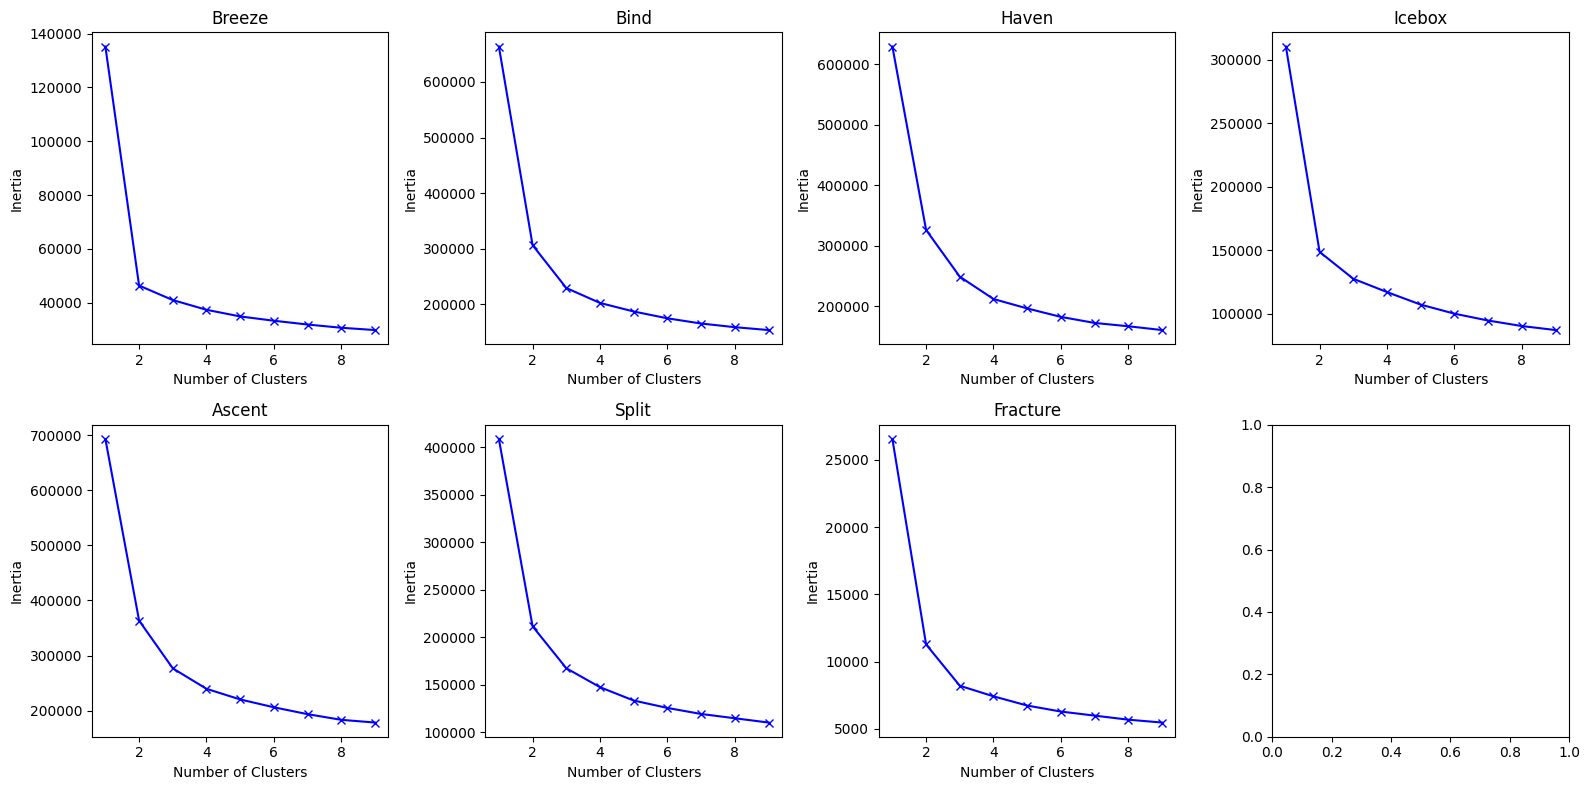

In [163]:
from sklearn.cluster import KMeans
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
axes = axes.flatten()

for i, map_name in enumerate(map_names):

    inertia = []
    for cluster in range(1, 10):
        km = KMeans(n_clusters=cluster)
        km = km.fit(map_dataframes[f'df_cluster_{map_name.lower()}'])
        inertia.append(km.inertia_)

    axes[i].plot(range(1, 10), inertia, 'bx-')
    axes[i].set_title(f'{map_name}')
    axes[i].set_xlabel('Number of Clusters')
    axes[i].set_ylabel('Inertia')

plt.tight_layout()
plt.show()


Kita dapati bahwa untuk setiap Map jumlah cluster yang optimal sebesar 2 dan di beberapa Map terlihat bisa kita pilih jumlah cluster sebesar 3. Kita akan coba melakukan cluster 2 terhadap Map Breeze yang terlihat sangat signifikan pada cluster ke-2 dan kita coba bandingkan dengan Map Fracture yang cukup signifikan pada cluster ke-3. Kita menggunakan K-Means untuk clustering dikarenakan kita memiliki total data sebesar 117679 yang tergolong besar sekali untuk menerapkan Hierarchical Clustering

#### K-Means Clustering Map Breeze

Untuk map Breeze sesuai dengan Elbow Method pada pencarian sebelumnya menampakkan perubahan yang signifikan pada saat memiliki cluster bernilai 2. Terlihat bahwa terjadi perbelokkan yang dratis pada cluster kedua sehingga kita bisa mencoba menerapkannya pada K-Means dengan n_clusters = 2

##### Clustering

In [164]:
df_cluster_breeze = map_dataframes['df_cluster_breeze']
kmeans = KMeans(n_clusters=2, random_state=42)

cluster_assignment = kmeans.fit_predict(df_cluster_breeze)

data_map_clusters = df_cluster[df_cluster['Map']=='Breeze']
data_with_clusters = data_map_clusters.copy()
data_with_clusters['Clusters'] = cluster_assignment
data_with_clusters

,ACS,Kills,Deaths,Assists,FirstKills,FirstDeaths,Econ,Plants,Defuses,Map,Agent,Clusters
0,313.0,24.0,10.0,3.0,4.0,4.0,74.0,0.0,0.0,Breeze,jett,0
1,227.0,16.0,10.0,7.0,1.0,1.0,67.0,2.0,0.0,Breeze,chamber,0
2,226.0,17.0,9.0,8.0,3.0,0.0,58.0,3.0,0.0,Breeze,sova,1
3,218.0,17.0,12.0,2.0,3.0,0.0,48.0,0.0,0.0,Breeze,viper,1
4,80.0,5.0,13.0,3.0,3.0,1.0,21.0,0.0,0.0,Breeze,skye,1
...,...,...,...,...,...,...,...,...,...,...,...,...
54384,145.0,11.0,16.0,5.0,1.0,0.0,42.0,0.0,0.0,Breeze,sova,1
54385,127.0,10.0,17.0,1.0,1.0,5.0,33.0,1.0,1.0,Breeze,skye,1
54386,282.0,22.0,17.0,4.0,3.0,3.0,62.0,0.0,0.0,Breeze,phoenix,0
54387,272.0,21.0,12.0,3.0,2.0,2.0,81.0,1.0,2.0,Breeze,reyna,1


##### Evaluasi Clustering

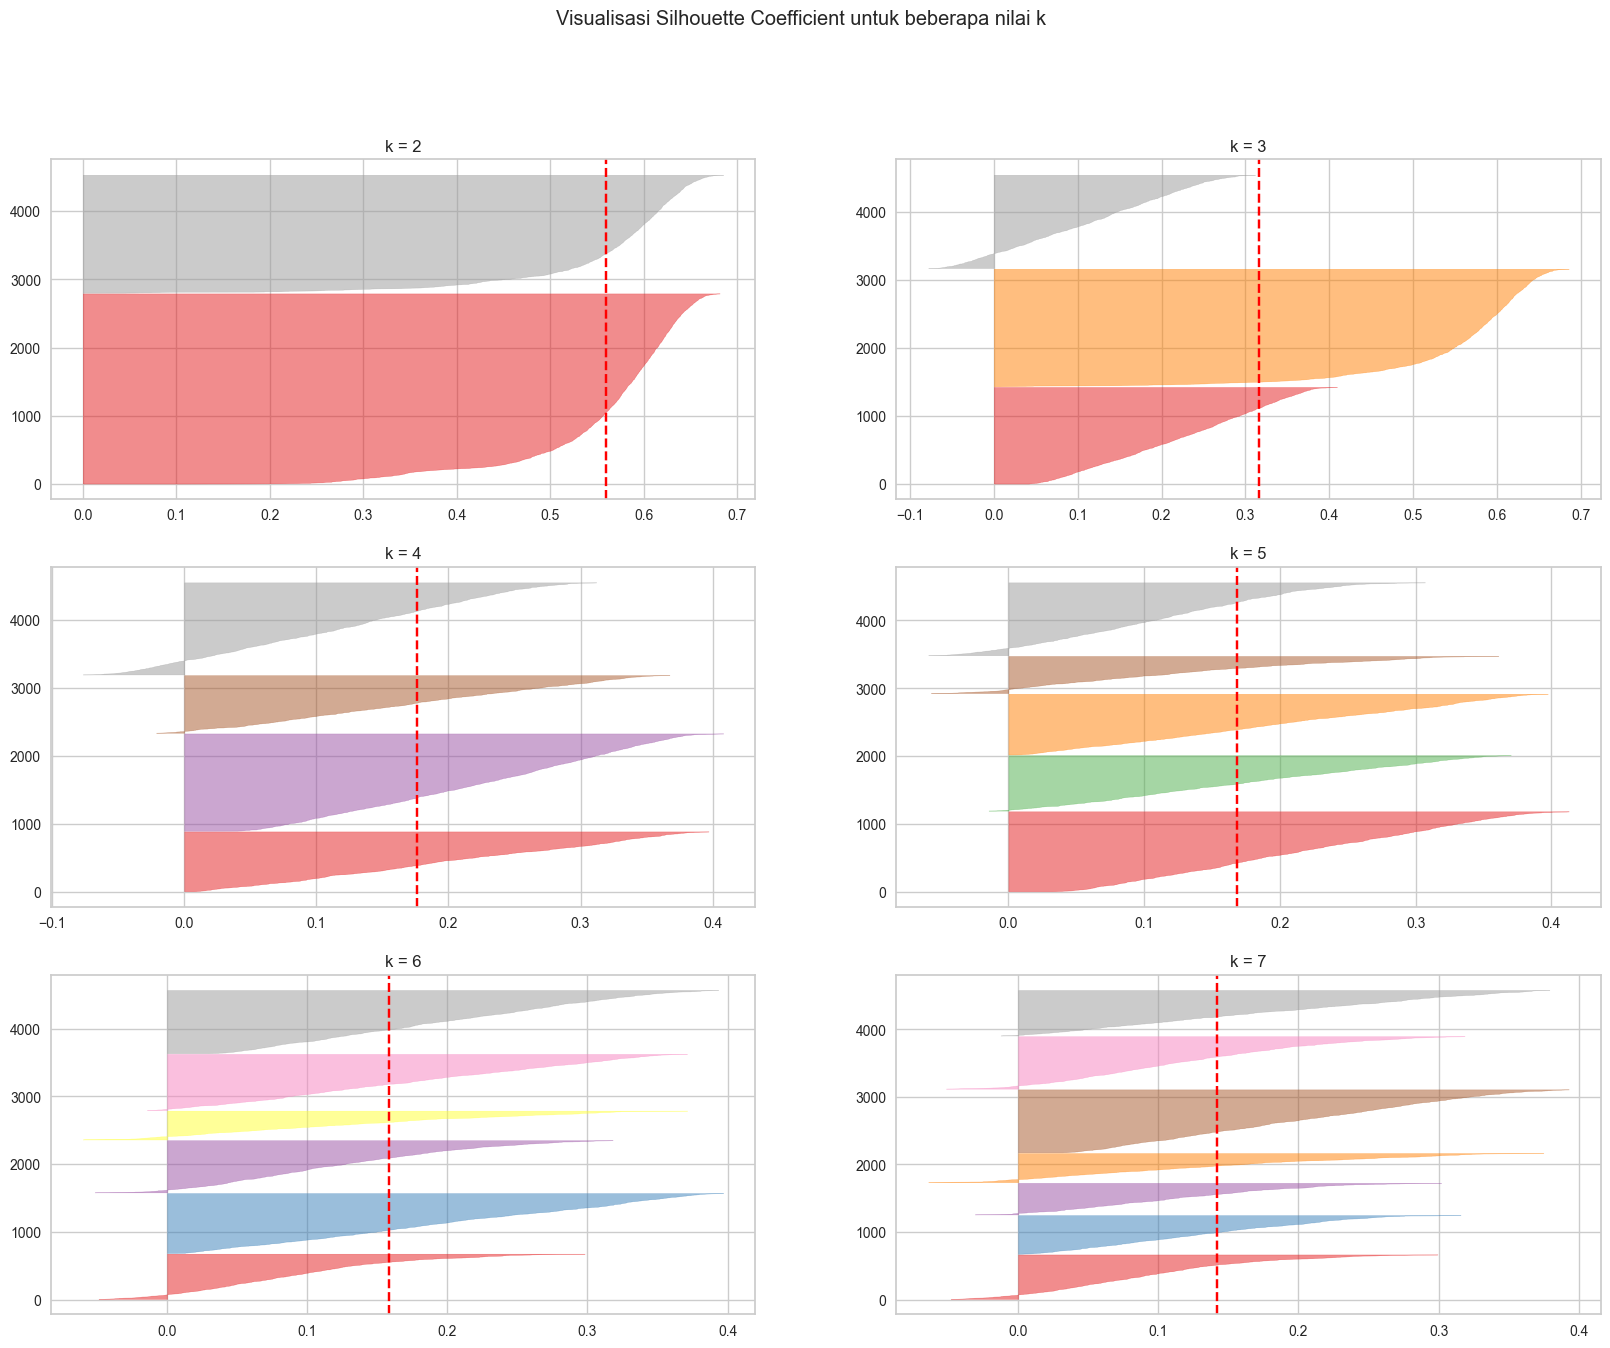

In [165]:
from yellowbrick.cluster import SilhouetteVisualizer

fig, ax = plt.subplots(3, 2, figsize=(20,15))
fig.suptitle("Visualisasi Silhouette Coefficient untuk beberapa nilai k")
for k in [2, 3, 4, 5, 6, 7]:
    clusterer = KMeans(n_clusters=k)

    q, mod = divmod(k, 2)
    ax[q-1][mod].set_title(f"k = {k}")
    visualizer = SilhouetteVisualizer(clusterer, ax = ax[q-1][mod])
    visualizer.fit(df_cluster_breeze)

In [166]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

silhouette = silhouette_score(df_cluster_breeze, cluster_assignment)
db_index = davies_bouldin_score(df_cluster_breeze, cluster_assignment)
ch_index = calinski_harabasz_score(df_cluster_breeze, cluster_assignment)
 
print(f"Silhouette Score: {silhouette:.2f}")
print(f"Davies-Bouldin Index: {db_index:.2f}")
print(f"Calinski-Harabasz Index: {ch_index:.2f}")

Silhouette Score: 0.56
Davies-Bouldin Index: 0.67
Calinski-Harabasz Index: 8629.50


Dengan menggunakan metric evaluasi untuk cluster terlihat bahwa cluster yang kita buat sudah cukup baik dan masih dapat dilakukan peningkatan lagi. Dalam hal ini bisa kita tambahkan kolom untuk cluster yang sekiranya masih relevan dengan kumpulan kolom yang telah terpilih.

##### Visualisasi Clustering

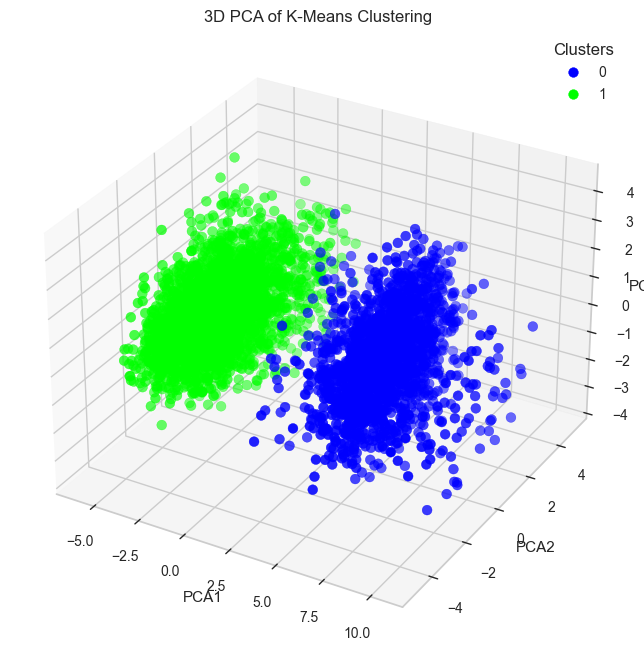

In [167]:
from sklearn.decomposition import PCA

data = df_cluster_breeze.copy()
data_cluster = data_with_clusters.copy()

pca = PCA(n_components=3)
pca_result = pca.fit_transform(data)
data_cluster['PCA1'] = pca_result[:, 0]
data_cluster['PCA2'] = pca_result[:, 1]
data_cluster['PCA3'] = pca_result[:, 2]

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(data_cluster['PCA1'], data_cluster['PCA2'], data_cluster['PCA3'], c=data_with_clusters['Clusters'], cmap='brg', s=50)
ax.set_title('3D PCA of K-Means Clustering')
ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')
ax.legend(*scatter.legend_elements(), title='Clusters')
plt.show()


##### Analisis Cluster 

In [168]:
data_with_clusters.value_counts('Clusters')

Clusters
1    2785
0    1728
Name: count, dtype: int64

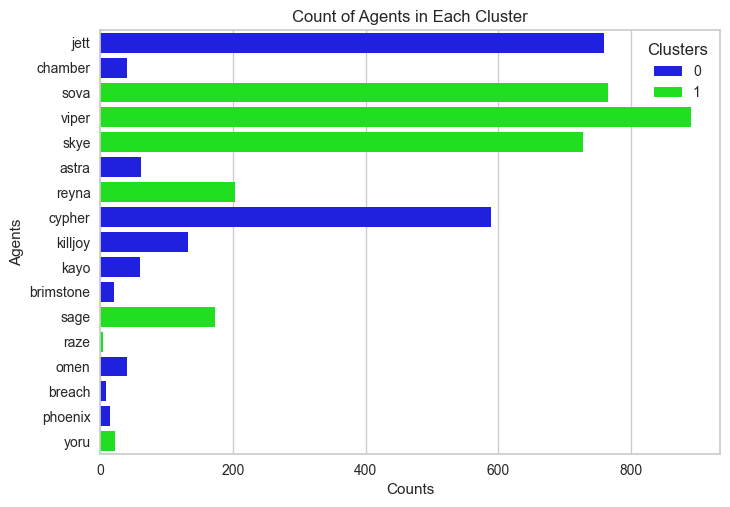

In [169]:
cluster_colors = {0: 'blue', 1: 'lime'}

sns.barplot(data=data_with_clusters, x='Clusters', y='Agent', hue='Clusters',estimator=len, ci=None, palette=cluster_colors)

plt.xlabel('Counts')
plt.ylabel('Agents')
plt.title('Count of Agents in Each Cluster')
plt.show()

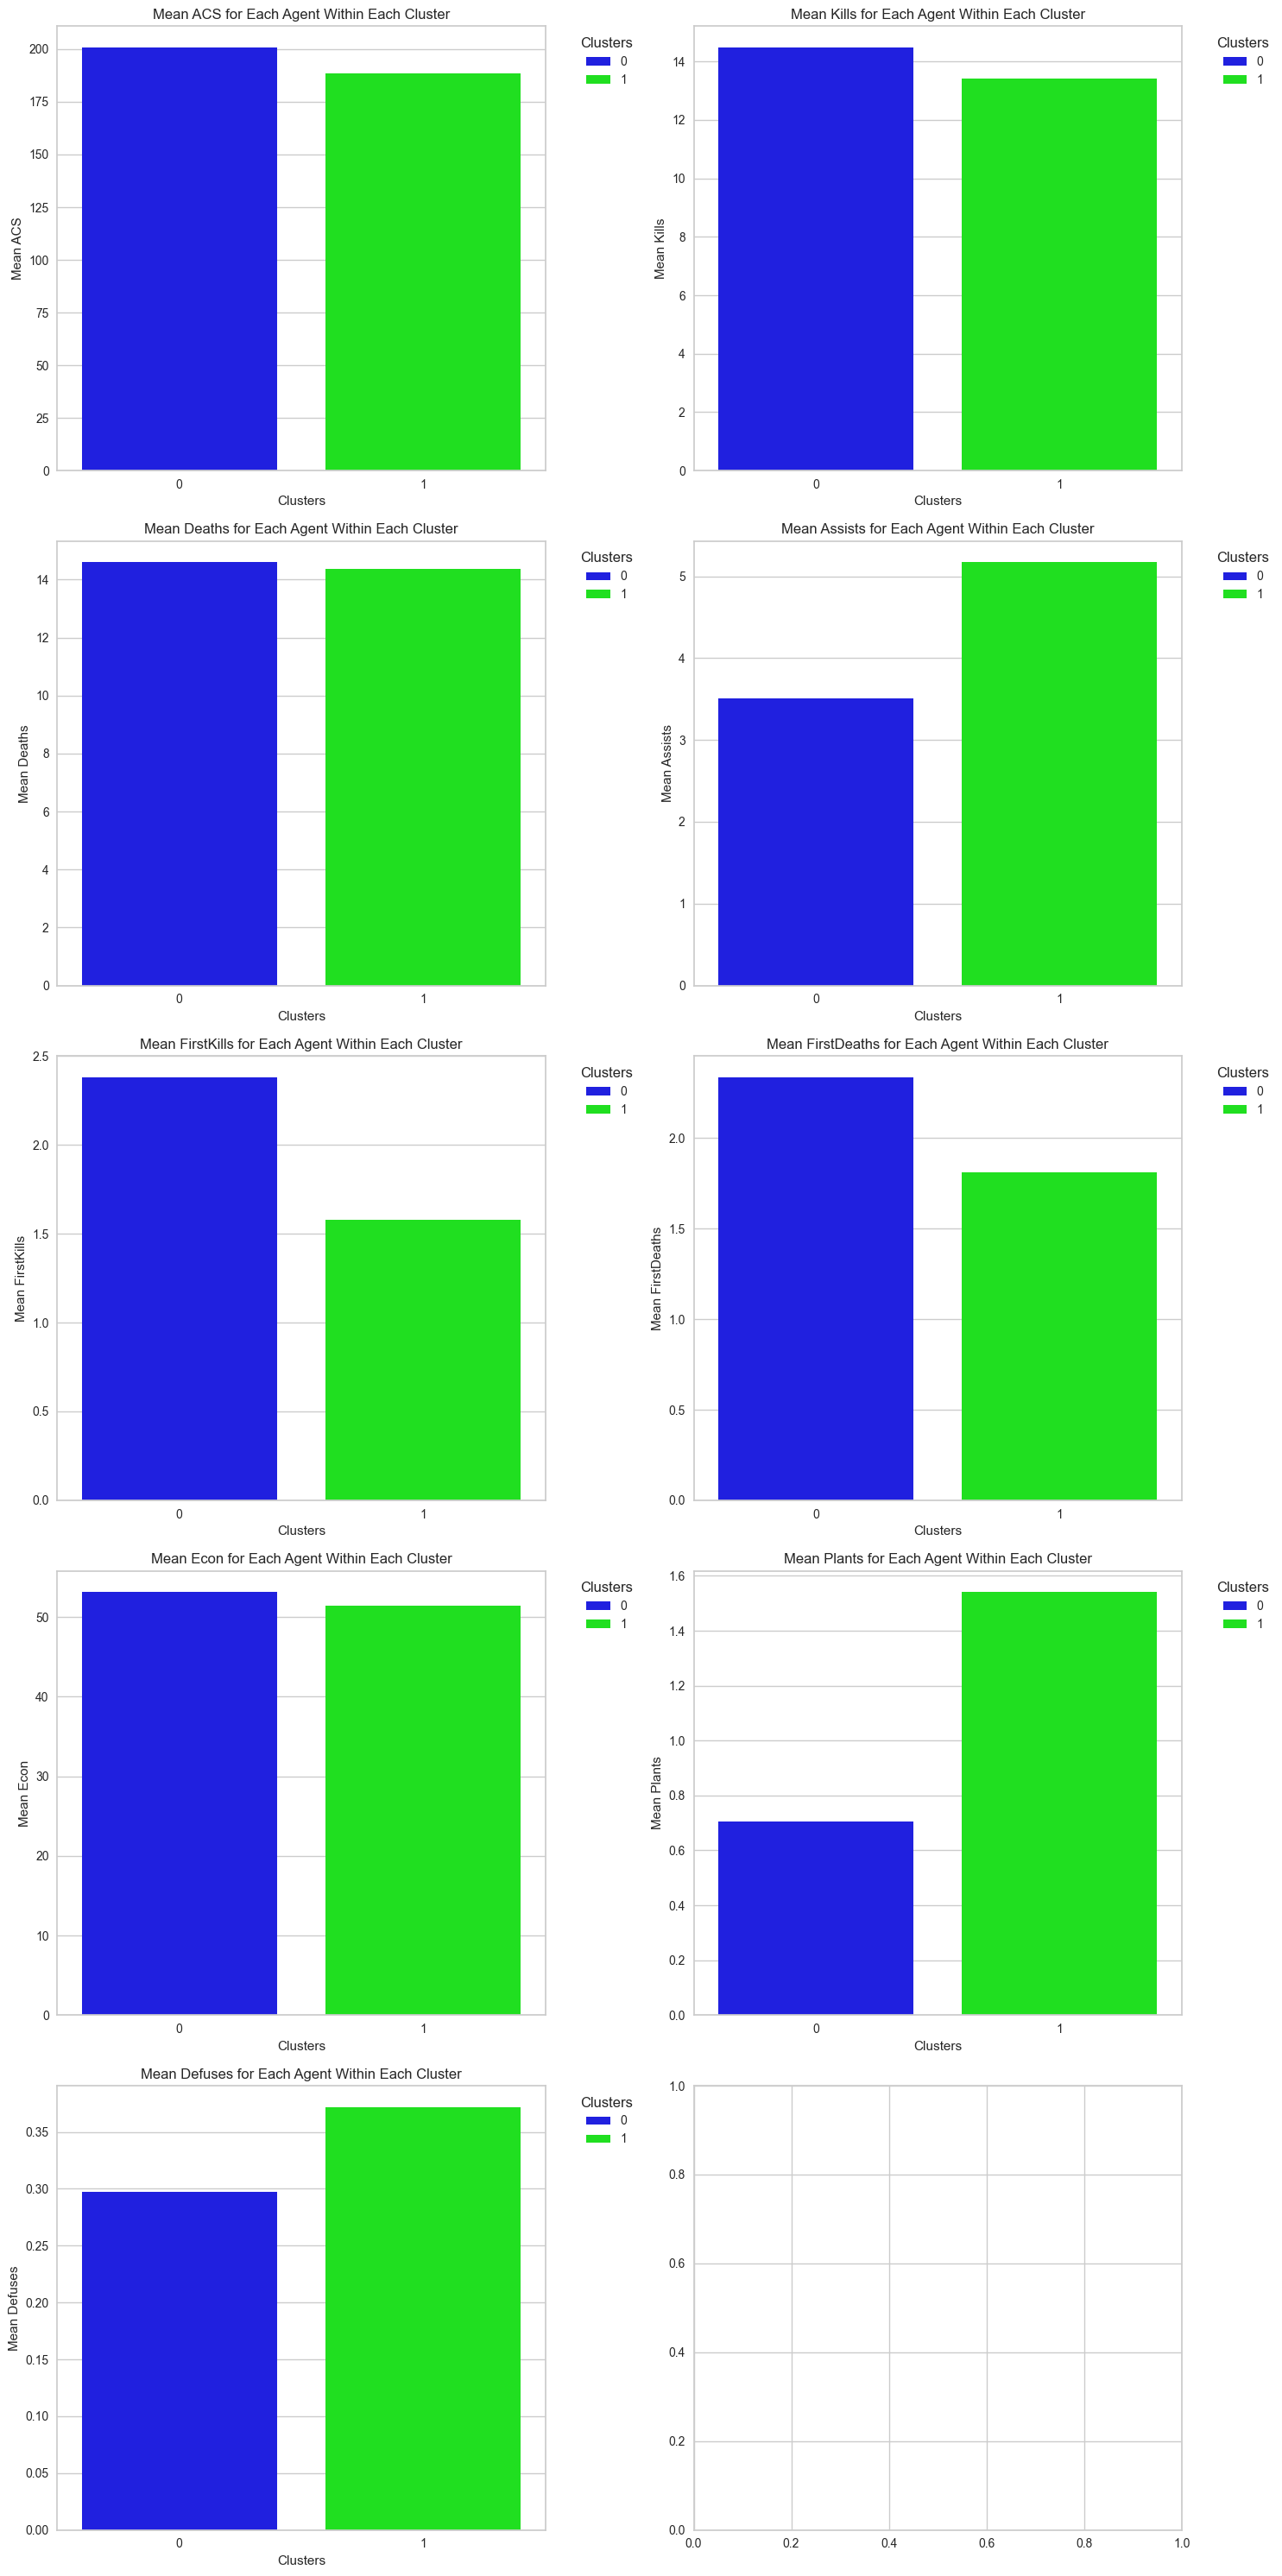

In [170]:
columns_to_plot = ['ACS', 'Kills', 'Deaths', 'Assists', 'FirstKills', 'FirstDeaths', 'Econ', 'Plants', 'Defuses']

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 30))

cluster_colors = {0: 'blue', 1: 'lime'}

axes = axes.flatten()

for i, column in enumerate(columns_to_plot):
    mean_by_agent_and_cluster = data_with_clusters.groupby(['Clusters'])[column].mean().reset_index()
    
    sns.barplot(data=mean_by_agent_and_cluster, y=column, x='Clusters', hue='Clusters', ax=axes[i], palette=cluster_colors)
    
    axes[i].set_xlabel('Clusters')
    axes[i].set_ylabel(f'Mean {column}')
    axes[i].set_title(f'Mean {column} for Each Agent Within Each Cluster')
    axes[i].legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

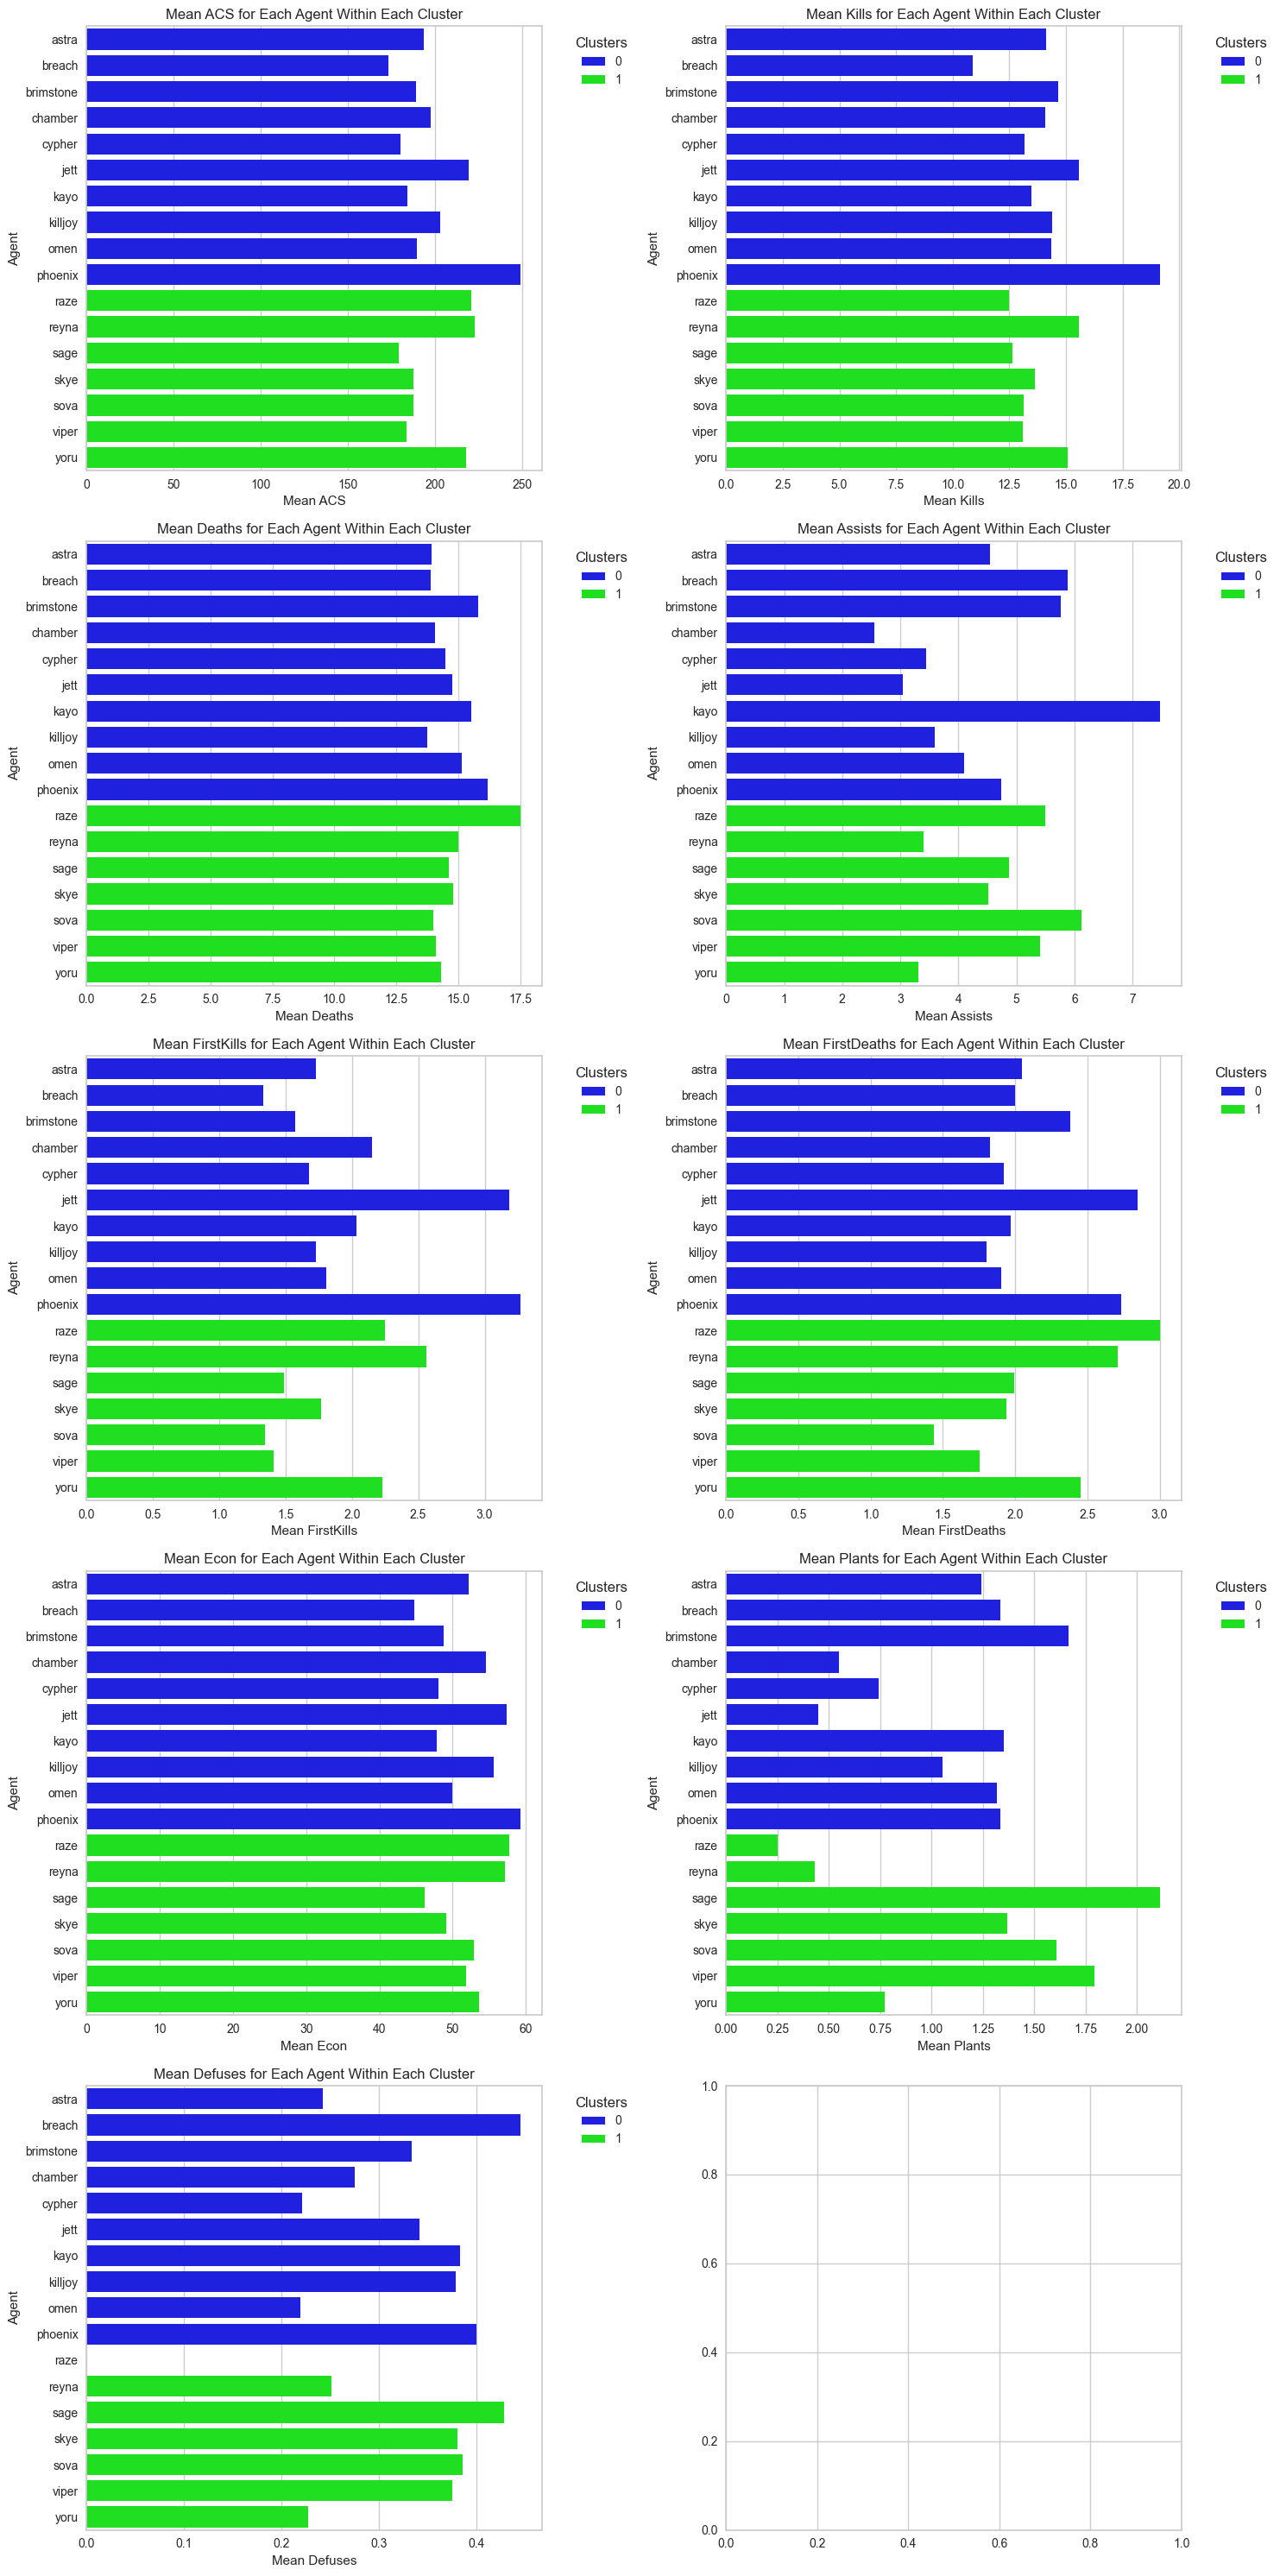

In [171]:
columns_to_plot = ['ACS', 'Kills', 'Deaths', 'Assists', 'FirstKills', 'FirstDeaths', 'Econ', 'Plants', 'Defuses']

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 30))

cluster_colors = {0: 'blue', 1: 'lime'}


axes = axes.flatten()

for i, column in enumerate(columns_to_plot):
    mean_by_agent_and_cluster = data_with_clusters.groupby(['Clusters', 'Agent'])[column].mean().reset_index()
    
    sns.barplot(data=mean_by_agent_and_cluster, y='Agent', x=column, hue='Clusters', ax=axes[i], palette=cluster_colors)
    
    axes[i].set_xlabel(f'Mean {column}')
    axes[i].set_ylabel('Agent')
    axes[i].set_title(f'Mean {column} for Each Agent Within Each Cluster')
    axes[i].legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Berdasarkan clustering yang telah kita telah buat kita mendapatkan beberapa insight: (Index cluster tidak tetap dan berubah setiap run)
- Jumlah cluster 1 lebih besar dari cluster 0
- Cluster 0 terdiri atas Jett, Chamber, Astra, Cypher, KillJoy, Kayo, Brimstone, Omen, Breach, Phoenix
- Cluster 1 terdiri atas Sova, Viper, Skye, Reyna, Sage, Raze, Yoru
- Agent paling sering dimainkan pada map adalah Viper
- Agent paling jarang dimainkan pada map adalah Raze
- Rata-rata ACS, Kills, Deaths, FirstKills, FirstDeaths, dan Econ cluster 0 lebih besar daripada cluster 1
- Rata-rata Assists, Plants, dan Defuses cluster 1 lebih besar daripada cluster 
- Agent dengan rata-rata ACS tertinggi adalah Phoenix dari cluster 0
- Agent dengan rata-rata Kills tertinggi adalah Phoenix dari cluster 0
- Agent dengan rata-rata Deaths tertinggi adalah Raze dari cluster 1
- Agent dengan rata-rata Assists tertinggi adalah Kayo dari cluster 0
- Agent dengan rata-rata FirstKills tertinggi adalah Phoenix dari cluster 0
- Agent dengan rata-rata FirstDeaths tertinggi adalah Raze dari cluster 1
- Agent dengan rata-rata Econ tertinggi adalah Phoenix dari cluster 0
- Agent dengan rata-rata Plants tertinggi adalah Sage dari cluster 1
- Agent dengan rata-rata Defuses tertinggi adalah Breach dari cluster 0

Kita dapat bedah lebih lanjut ke dalam setiap Cluster:

Cluster 0
- Agent pada cluster 0 adalah Jett, Chamber, Astra, Cypher, KillJoy, Kayo, Brimstone, Omen, Breach, Phoenix
- Rata-rata kills yang didapat pada map adalah 15
- Rata-rata deaths yang dialami adalah 15
- Rata-rata Assits yang didapat adalah 3.5
- Agent pada cluster lebih sering mendapatkan FirstKills
- Agent pada cluster lebih sering mengalami FirstDeath
- Rata-rata econ yang didapat berada di 55
- Agent pada cluster jarang melakukan plants pada saat menyerang
- Agent pada cluster jarang melakukan defuses pada saat bertahan

Maka, cluster 0 merupakan cluster dengan agent yang bermain agresif pada map yang mana tidak hanya memiliki jumlah eliminasi lawan yang banyak tetapi dikarenakan hal tersebut pula cenderung tereliminasi oleh musuh.


Cluster 1
- Agent pada cluster 1 adalah Sova, Viper, Skye, Reyna, Sage, Raze, Yoru
- Rata-rata kills yang didapat pada map adalah 13
- Rata-rata deaths yang dialami adalah 14.5
- Rata-rata Assits yang didapat adalah 5.5
- Agent pada cluster jarang mendapatkan FirstKills
- Agent pada cluster jarang mengalami FirstDeath
- Rata-rata econ yang didapat berada di 52
- Agent pada cluster sering melakukan plants pada saat menyerang
- Agent pada cluster sering melakukan defuses pada saat bertahan

Maka, cluster 1 merupakan cluster dengan agent yang bermain untuk objektif dari permainan yaitu untuk tim penyerang melakukan Plant dan pada saat tim bertahan melakukan Defuse

#### K-Means Clustering Map Fracture

Pada saat melakukan pencarian kita juga mendapati beberapa map terlihat perubahan yang sedikit signifikan terhadap cluster 3. Oleh karena itu kita bisa mencoba untuk menggunakan cluster 3 dan dibandingkan berdasarkan evaluasi untuk melihat seberapa jauh nilai evaluasinya dan persebaran pada cluster.

##### Clustering

In [172]:
df_cluster_fracture = map_dataframes['df_cluster_fracture']
kmeans = KMeans(n_clusters=3, random_state=42)

cluster_assignment = kmeans.fit_predict(df_cluster_fracture)

data_map_clusters = df_cluster[df_cluster['Map']=='Fracture']
data_with_clusters = data_map_clusters.copy()
data_with_clusters['Clusters'] = cluster_assignment
data_with_clusters

,ACS,Kills,Deaths,Assists,FirstKills,FirstDeaths,Econ,Plants,Defuses,Map,Agent,Clusters
280,289.0,25.0,12.0,3.0,5.0,2.0,72.0,0.0,0.0,Fracture,raze,1
281,284.0,23.0,16.0,7.0,5.0,2.0,65.0,0.0,0.0,Fracture,cypher,0
282,182.0,13.0,14.0,10.0,2.0,3.0,45.0,0.0,0.0,Fracture,viper,1
283,159.0,13.0,15.0,7.0,1.0,1.0,42.0,4.0,0.0,Fracture,brimstone,2
284,157.0,12.0,15.0,5.0,1.0,1.0,40.0,2.0,0.0,Fracture,breach,2
...,...,...,...,...,...,...,...,...,...,...,...,...
21382,172.0,14.0,15.0,9.0,2.0,1.0,55.0,3.0,1.0,Fracture,sage,1
21384,242.0,20.0,18.0,6.0,6.0,0.0,63.0,1.0,0.0,Fracture,cypher,0
21385,221.0,19.0,16.0,5.0,3.0,2.0,61.0,1.0,1.0,Fracture,skye,1
21386,219.0,19.0,17.0,4.0,1.0,3.0,51.0,0.0,1.0,Fracture,viper,1


##### Evaluasi Clustering

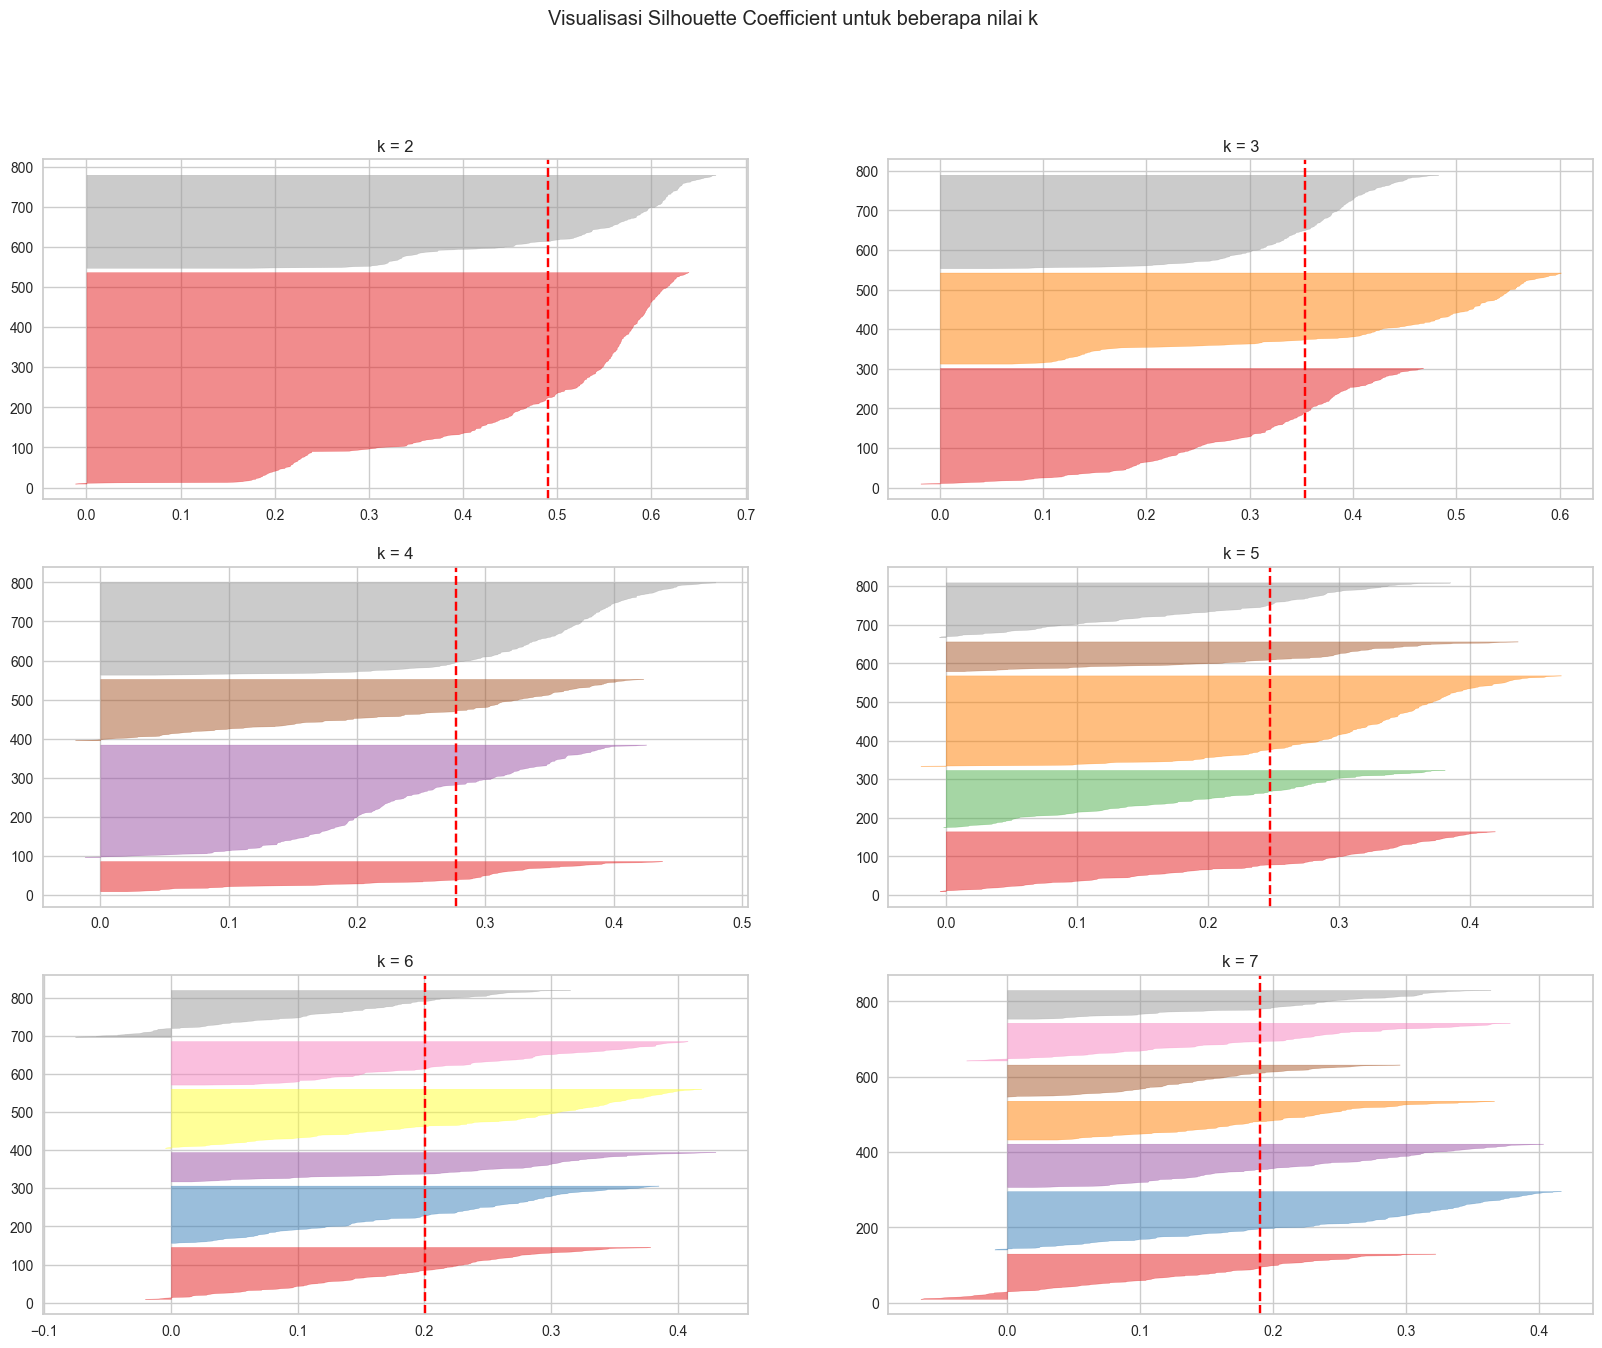

In [173]:
fig, ax = plt.subplots(3, 2, figsize=(20,15))
fig.suptitle("Visualisasi Silhouette Coefficient untuk beberapa nilai k")
for k in [2, 3, 4, 5, 6, 7]:
    clusterer = KMeans(n_clusters=k)

    q, mod = divmod(k, 2)
    ax[q-1][mod].set_title(f"k = {k}")
    visualizer = SilhouetteVisualizer(clusterer, ax = ax[q-1][mod])
    visualizer.fit(df_cluster_fracture)

In [174]:
silhouette = silhouette_score(df_cluster_fracture, cluster_assignment)
db_index = davies_bouldin_score(df_cluster_fracture, cluster_assignment)
ch_index = calinski_harabasz_score(df_cluster_fracture, cluster_assignment)
 
print(f"Silhouette Score: {silhouette:.2f}")
print(f"Davies-Bouldin Index: {db_index:.2f}")
print(f"Calinski-Harabasz Index: {ch_index:.2f}")

Silhouette Score: 0.35
Davies-Bouldin Index: 1.12
Calinski-Harabasz Index: 846.43


In [175]:
kmeans = KMeans(n_clusters=2, random_state=42)

cluster_assignment = kmeans.fit_predict(df_cluster_fracture)
silhouette = silhouette_score(df_cluster_fracture, cluster_assignment)
db_index = davies_bouldin_score(df_cluster_fracture, cluster_assignment)
ch_index = calinski_harabasz_score(df_cluster_fracture, cluster_assignment)
 
print(f"Silhouette Score: {silhouette:.2f}")
print(f"Davies-Bouldin Index: {db_index:.2f}")
print(f"Calinski-Harabasz Index: {ch_index:.2f}")

Silhouette Score: 0.49
Davies-Bouldin Index: 0.76
Calinski-Harabasz Index: 1027.20


Terlihat bahwa untuk cluster 2 bernilai lebih baik dibandingkan cluster 3. Hal ini akan terlihat lebih jelas pada saat kita menginterpretasi masing-masing cluster

##### Visualisasi Clustering

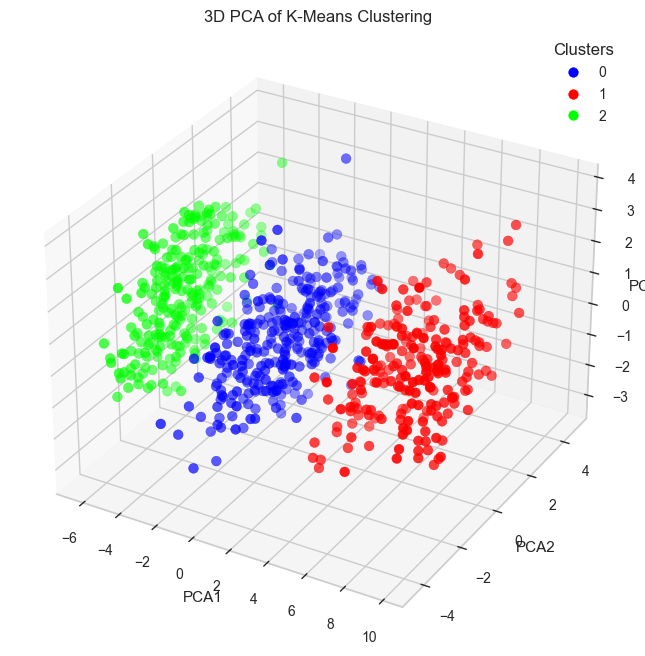

In [176]:
from sklearn.decomposition import PCA

data = df_cluster_fracture.copy()
data_cluster = data_with_clusters.copy()

pca = PCA(n_components=3)
pca_result = pca.fit_transform(data)
data_cluster['PCA1'] = pca_result[:, 0]
data_cluster['PCA2'] = pca_result[:, 1]
data_cluster['PCA3'] = pca_result[:, 2]

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(data_cluster['PCA1'], data_cluster['PCA2'], data_cluster['PCA3'], c=data_with_clusters['Clusters'], cmap='brg', s=50)
ax.set_title('3D PCA of K-Means Clustering')
ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')
ax.legend(*scatter.legend_elements(), title='Clusters')
plt.show()

##### Analisis Cluster 

In [177]:
data_with_clusters.value_counts('Clusters')

Clusters
0    293
2    237
1    231
Name: count, dtype: int64

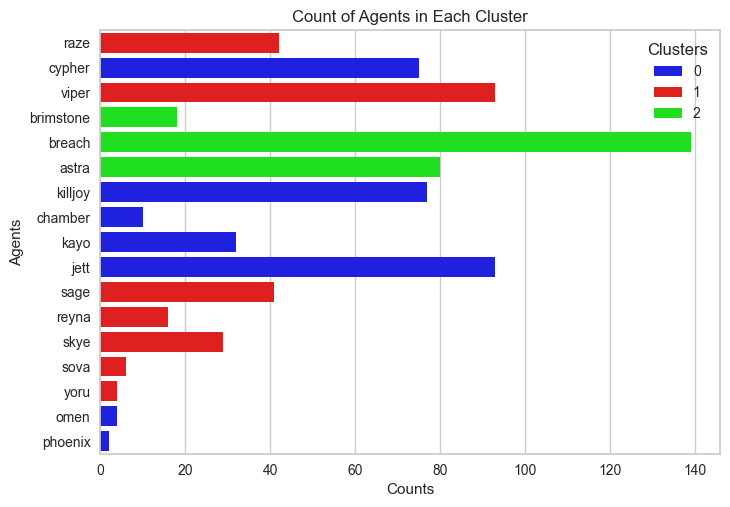

In [178]:
cluster_colors = {0: 'blue', 1: 'red', 2:'lime'}

sns.barplot(data=data_with_clusters, x='Clusters', y='Agent', hue='Clusters',estimator=len, ci=None, palette=cluster_colors)

plt.xlabel('Counts')
plt.ylabel('Agents')
plt.title('Count of Agents in Each Cluster')
plt.show()

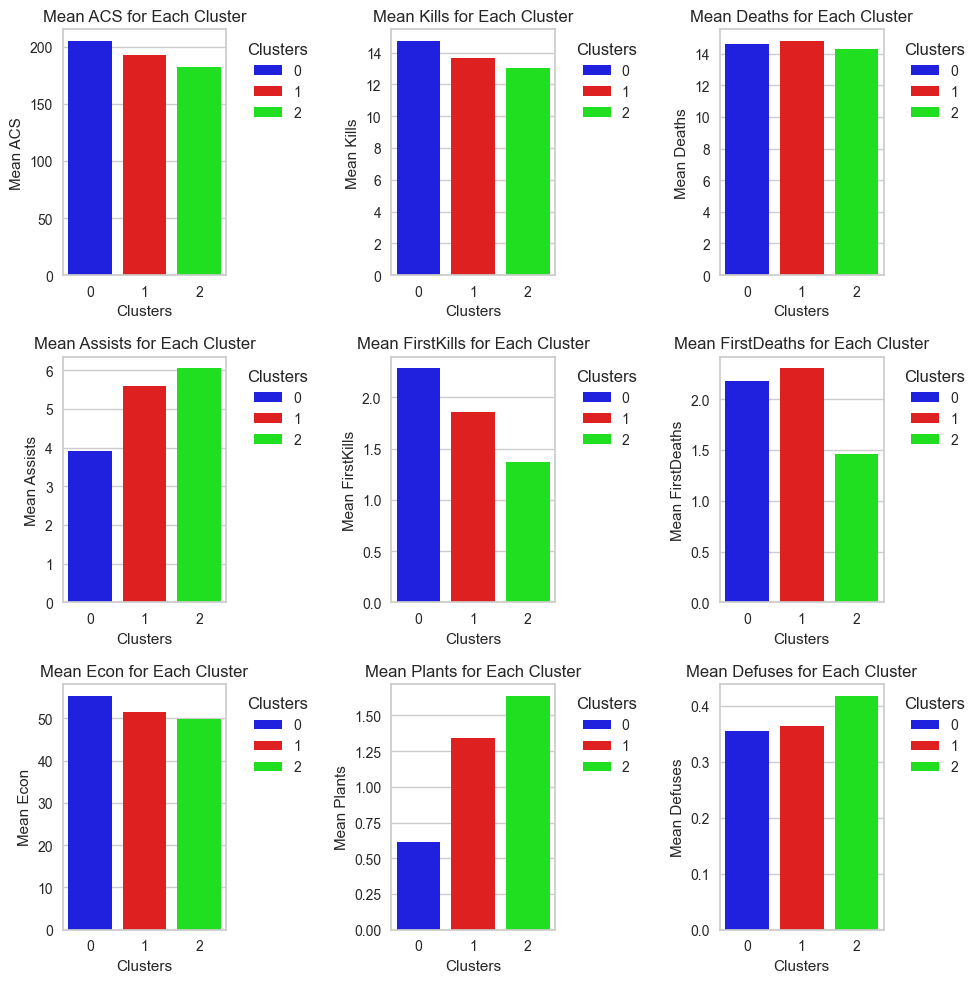

In [179]:
columns_to_plot = ['ACS', 'Kills', 'Deaths', 'Assists', 'FirstKills', 'FirstDeaths', 'Econ', 'Plants', 'Defuses']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10, 10))

cluster_colors = {0: 'blue', 1: 'red', 2:'lime'}

axes = axes.flatten()

for i, column in enumerate(columns_to_plot):
    mean_by_agent_and_cluster = data_with_clusters.groupby(['Clusters'])[column].mean().reset_index()
    
    sns.barplot(data=mean_by_agent_and_cluster, y=column, x='Clusters', hue='Clusters', ax=axes[i], palette=cluster_colors)
    
    axes[i].set_xlabel('Clusters')
    axes[i].set_ylabel(f'Mean {column}')
    axes[i].set_title(f'Mean {column} for Each Cluster')
    axes[i].legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

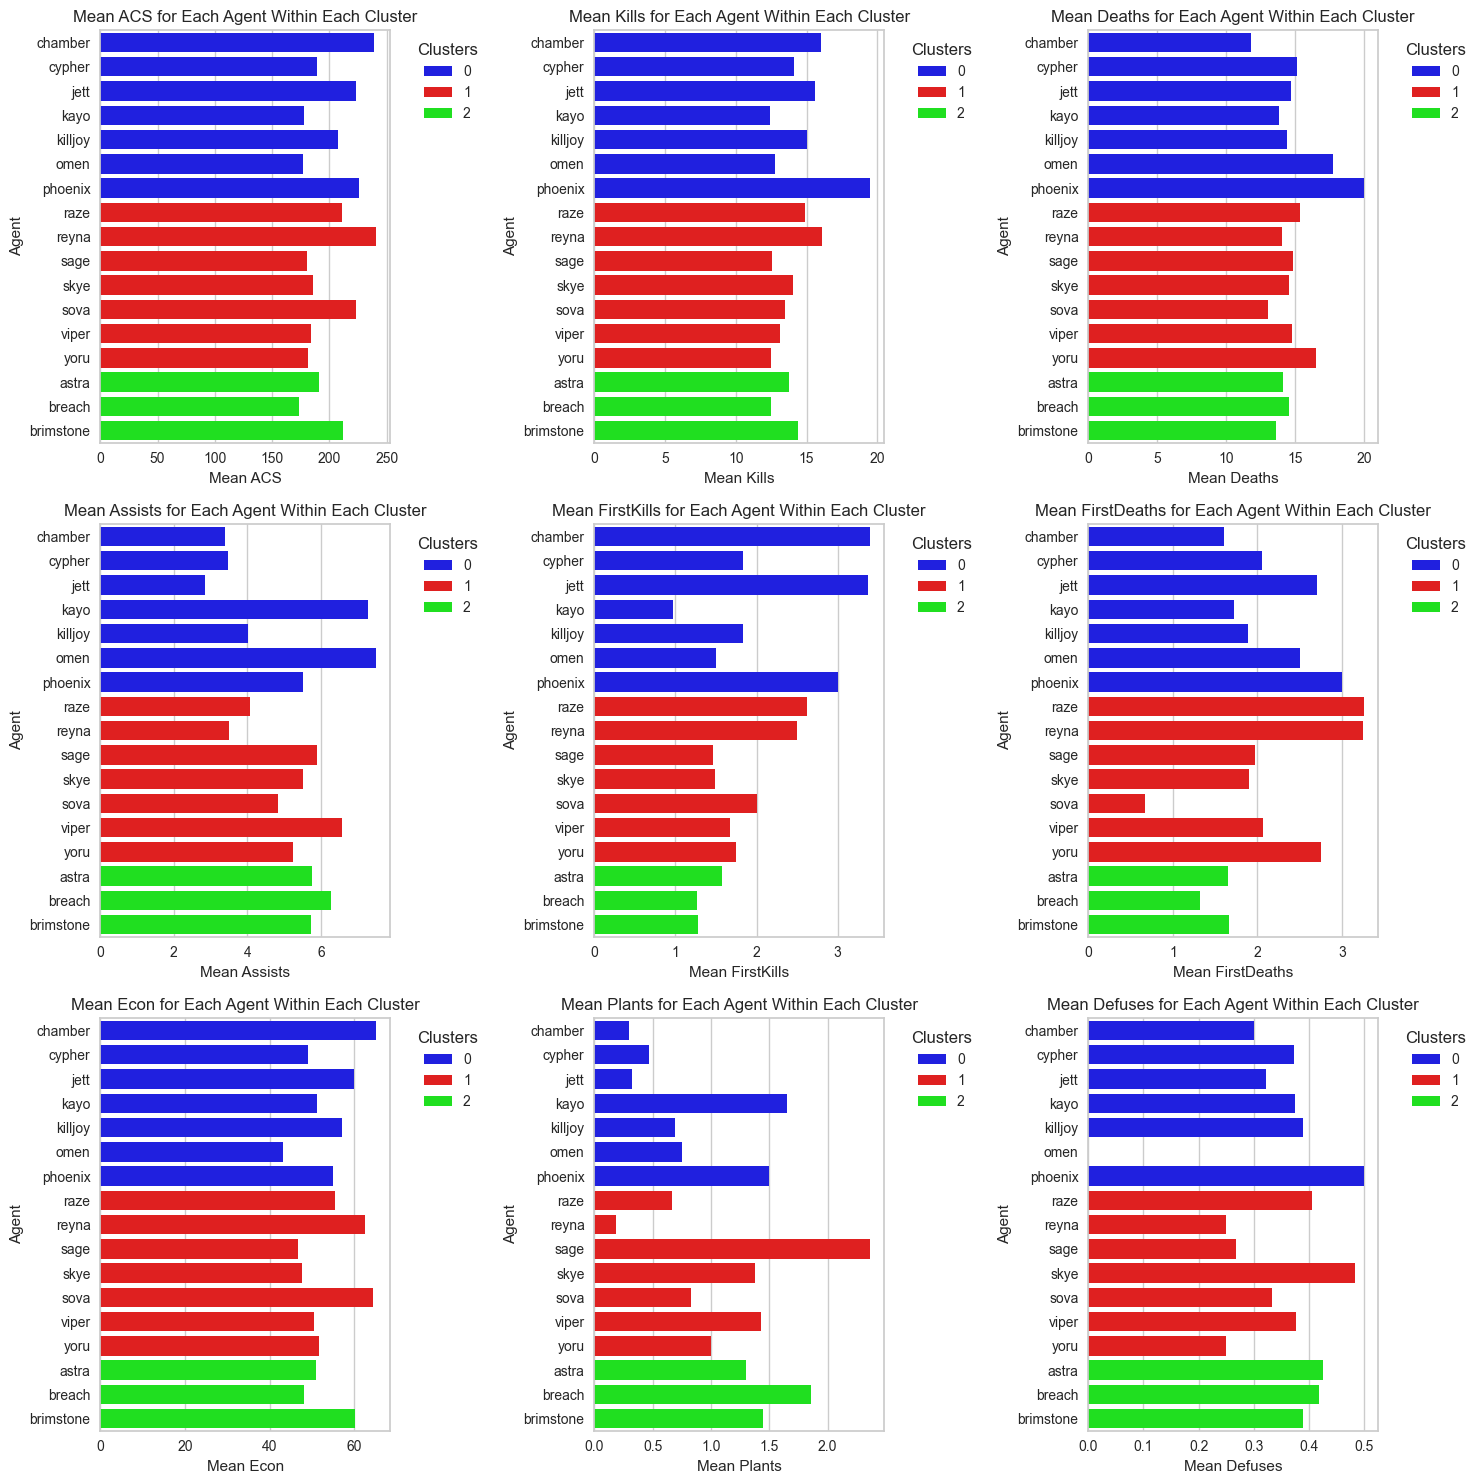

In [180]:
columns_to_plot = ['ACS', 'Kills', 'Deaths', 'Assists', 'FirstKills', 'FirstDeaths', 'Econ', 'Plants', 'Defuses']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))

cluster_colors = {0: 'blue', 1: 'red', 2:'lime'}

axes = axes.flatten()

for i, column in enumerate(columns_to_plot):
    mean_by_agent_and_cluster = data_with_clusters.groupby(['Clusters', 'Agent'])[column].mean().reset_index()
    
    sns.barplot(data=mean_by_agent_and_cluster, y='Agent', x=column, hue='Clusters', ax=axes[i], palette=cluster_colors)
    
    axes[i].set_xlabel(f'Mean {column}')
    axes[i].set_ylabel('Agent')
    axes[i].set_title(f'Mean {column} for Each Agent Within Each Cluster')
    axes[i].legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Dengan melihat persebaran dari setiap cluster, terlihat bahwa jumlah cluster 2 dan 1 sangatlah dekat dan juga terlihat persebaran agent pada cluster tidak begitu seimbang. Hal-hal ini menyebabkan perbedaan untuk setiap cluster cukup dekat satu sama lainnya.

Berdasarkan clustering yang telah kita telah buat kita mendapatkan beberapa insight: 
- Jumlah cluster 2 paling besar, cluster 0 berada di tengah, cluster 1 paling sedikit
- Cluster 2 terdiri atas Astra, Brimstone, Breach
- Cluster 1 terdiri atas Raze, Viper, Sage, Reyna, Skye, Sova, Yoru
- Cluster 0 terdiri atas Cypher, KillJoy, Chamber, Kayo, Jett, Omen, Phoenix
- Agent paling sering dimainkan pada map adalah Breach
- Agent paling jarang dimainkan pada map adalah Phoenix
- Rata-rata ACS, Kills, FirstKills, dan Econ untuk cluster, cluster 2 paling tinggi, cluster 1 menengah, dan cluster 0 paling rendah
- Rata-rata Assists, Plants, dan Defuses untuk cluster, cluster 0 paling tinggi, cluster 1 menengah, dan cluster 2 paling rendah
- Rata-rata Deaths dan FirstDeaths untuk cluster, cluster 1 paling tinggi, cluster 2 menengah, dan cluster 0 paling rendah
- Agent dengan rata-rata ACS tertinggi adalah Reyna dari cluster 1
- Agent dengan rata-rata Kills tertinggi adalah Phoenix dari cluster 2
- Agent dengan rata-rata Deaths tertinggi adalah Phoenix dari cluster 2
- Agent dengan rata-rata Assists tertinggi adalah Omen dari cluster 2
- Agent dengan rata-rata FirstKills tertinggi adalah Chamber dari cluster 2
- Agent dengan rata-rata FirstDeaths tertinggi adalah Raze dari cluster 1
- Agent dengan rata-rata Econ tertinggi adalah Chamber dari cluster 2
- Agent dengan rata-rata Plants tertinggi adalah Sage dari cluster 1
- Agent dengan rata-rata Defuses tertinggi adalah Phoenix dari cluster 2

Kita dapat bedah lebih lanjut ke dalam setiap Cluster:

Cluster 0
- Agent pada cluster 0 adalah Cypher, KillJoy, Chamber, Kayo, Jett, Omen, Phoenix
- Rata-rata kills yang didapat pada map adalah 15
- Rata-rata deaths yang dialami adalah 14.5
- Rata-rata Assits yang didapat adalah 4
- Agent pada cluster lebih sering mendapatkan FirstKills
- Agent pada cluster sering mengalami FirstDeath
- Rata-rata econ yang didapat berada diatas 50.5
- Agent pada cluster jarang melakukan plants pada saat menyerang
- Agent pada cluster jarang melakukan defuses pada saat bertahan

Cluster 1
- Agent pada cluster 0 adalah Raze, Viper, Sage, Reyna, Skye, Sova, Yoru
- Rata-rata kills yang didapat pada map adalah 13.5
- Rata-rata deaths yang dialami adalah 15
- Rata-rata Assits yang didapat adalah 5.5
- Agent pada cluster sering mendapatkan FirstKills
- Agent pada cluster lebih sering mengalami FirstDeath
- Rata-rata econ yang didapat berada diatas 50
- Agent pada cluster sering melakukan plants pada saat menyerang
- Agent pada cluster sering melakukan defuses pada saat bertahan

Cluster 2
- Agent pada cluster 0 adalah Astra, Brimstone, Breach
- Rata-rata kills yang didapat pada map adalah diatas 13
- Rata-rata deaths yang dialami adalah 14
- Rata-rata Assits yang didapat adalah 6
- Agent pada cluster jarang mendapatkan FirstKills
- Agent pada cluster jarang mengalami FirstDeath
- Rata-rata econ yang didapat berada pada 50
- Agent pada cluster lebih sering melakukan plants pada saat menyerang
- Agent pada cluster lebih sering melakukan defuses pada saat bertahan

## Modeling and Evaluation

### Classification

Pada tahap ini, model klasifikasi untuk menentukan Agent yang digunakan oleh setiap pemain pada setiap babak akan dibangun, dilatih, dan dievaluasi sedemikian hingga model klasifikasi yang terbaik dapat diperoleh untuk menyelesaikan permasalahan yang ada.

#### Hapus Meta Attributes

Pada tahap ini, atribut-atribute tambahan yang tidak akan digunakan dalam prediksi untuk permasalahan klasifikasi dibuang.

In [62]:
# Hapus kolom yang tidak digunakan dalam prediksi Agent
df_classification = util_dataset.remove_meta_attr_classification(df_matches_games_scores)
df_classification.columns

Index(['Date', 'Patch', 'Team_MapScore', 'Map', 'Team_Eco', 'Team_SemiEco',
       'Team_SemiBuy', 'Team_FullBuy', 'Team_TotalRounds', 'Agent', 'Kills',
       'Deaths', 'Assists', 'PlusMinus', 'ADR', 'HS_Percent', 'FirstKills',
       'FirstDeaths', 'FKFD_PlusMinus', 'Econ', 'Plants', 'Defuses', 'Num_Ks',
       'OnevX', 'Total_Agent'],
      dtype='object')

Ada beberapa kolom yang dihapus sesuai dengan kebutuhan dalam proses klasifikasi. Hal ini dikarenakan kolom-kolom tersebut tidak terlalu relevan dalam permasalahan klasifikasi untuk menentukan `Agent` secara general.

#### Distribusi Kelas

In [237]:
proportion = (df_classification['Agent'].value_counts(
) / len(df_classification['Agent'])) * 100
proportion

Agent
sova         15.274603
jett         14.786835
omen          9.968644
raze          8.388073
cypher        8.274204
killjoy       7.790685
sage          6.235607
astra         5.542195
viper         5.159799
breach        4.645689
skye          4.445143
reyna         4.156222
phoenix       2.692069
brimstone     1.631557
kayo          0.732501
yoru          0.141062
chamber       0.135113
Name: count, dtype: float64

Berdasarkan informasi di atas, distribusi kelas bersifat cukup imbalanced. Dengan demikian, permasalahan yang ada merupakan permasalahan imbalanced classification. Hal ini dapat terjadi karena ada beberapa `Agent` yang baru tersedia pada `Patch` tertentu. Dengan demikian, `Agent` seperti kayo, chamber, dan yoru masih cukup jarang digunakan oleh pemain pro pada pertandingan untuk dataset pertandingan pada `Patch 1.X`, `Patch 2.X`. dan `Patch 3.X`.  

#### Ubah Fitur Kategorikal

Pada tahap ini, fitur kategorikal akan ditransformasikan menjadi fitur numerikal, salah satunya dengan menggunakan `OneHotEncoder`. Hal ini dikarenakan model yang digunakan hanya menerima fitur numerik.

In [238]:
df_classification.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117679 entries, 0 to 117678
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Date              117679 non-null  int64  
 1   Patch             117679 non-null  object 
 2   Team_MapScore     117679 non-null  float64
 3   Map               117679 non-null  object 
 4   Team_Eco          117679 non-null  float64
 5   Team_SemiEco      117679 non-null  float64
 6   Team_SemiBuy      117679 non-null  float64
 7   Team_FullBuy      117679 non-null  float64
 8   Team_TotalRounds  117679 non-null  float64
 9   Agent             117679 non-null  object 
 10  Kills             117679 non-null  float64
 11  Deaths            117679 non-null  float64
 12  Assists           117679 non-null  float64
 13  PlusMinus         117679 non-null  float64
 14  ADR               117679 non-null  float64
 15  HS_Percent        117679 non-null  float64
 16  FirstKills        11

In [239]:
# One hot encoder
one_hot_encoder = OneHotEncoder()
transformed = one_hot_encoder.fit_transform(df_classification[['Map']])
df_classification[one_hot_encoder.categories_[0]] = transformed.toarray()
df_classification.drop('Map', axis='columns', inplace=True)

#### Modeling and Evaluation

Pada tahap ini, feature dan class yang digunakan akan ditentukan. Setelah itu, pembagian antara train dan test akan dilakukan. Selain itu, berbagai model, terutama model ensemble, akan dibangun untuk menyelesaikan permasalahan klasifikasi.

In [240]:
# Feature dan class
X_agent = df_classification.drop('Agent', axis='columns')
y_agent = df_classification['Agent']

# Pembagian train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X_agent, y_agent, test_size=0.25, random_state=10, stratify=y_agent)

##### RandomForestClassifier

Model `RandomForestClassifier` dipilih sebagai salah satu opsi karena kemampuannya dalam melakukan prediksi dalam permasalahan klasifikasi. Model ini berbasiskan *ensemble learning* dengan kumpulan `DecisionTree` yang akan digunakan dalam prediksi dengan *voting*. Selain itu, keunggulan dari model ini adalah feature selection yang bersifat embedded dengan menentukan dan mengukur hasil split berdasarkan spliting point tertentu secara automatis. 

Selain itu, untuk mengatasi distribusi kelas yang imbalanced, `RandomForestClassifier` dibangun dengan memanfaatkan parameter `class_weight='balanced'`. Hal ini bertujuan untuk mengatasi distribusi data yang imbalanced dengan memanfaatkan cost-sensitive learning. Dalam konteks ini, bobot akan ditetapkan untuk setiap kelas dengan nilai dari formula `n_sample / n_classes * np.bincount(y)` untuk suatu kelas `y`.

In [251]:
# Mendefinisikan model
rfc = RandomForestClassifier(n_estimators=200, class_weight='balanced_subsample', criterion='gini', random_state=10, n_jobs=-1, max_features=0.5)
rfc.fit(X_train, y_train)

# Prediksi dan Evaluasi
predictions = rfc.predict(X_test)
f1 = f1_score(y_test, predictions, average='micro')

print(f'F1 Score: {f1}')
evaluate_classifier_performance(predictions, y_test)

F1 Score: 0.36104690686607754
Confusion Matrix 



prediction,astra,breach,brimstone,chamber,cypher,jett,kayo,killjoy,omen,phoenix,raze,reyna,sage,skye,sova,viper,yoru
actual,,,,,,,,,,,,,,,,,
astra,498,20,4,0,65,125,15,119,67,5,53,4,60,85,469,41,0
breach,101,379,8,0,107,43,2,22,204,3,24,2,85,20,359,8,0
brimstone,29,19,23,0,31,39,2,7,84,1,46,0,22,19,146,12,0
chamber,2,0,0,1,2,25,0,3,0,0,0,0,1,0,5,1,0
cypher,107,59,14,0,575,408,2,140,393,15,129,19,27,75,425,46,0
jett,40,4,4,2,168,2901,0,205,222,22,418,78,23,49,140,73,1
kayo,52,3,1,0,0,15,18,7,5,0,4,0,10,9,77,14,0
killjoy,118,20,2,0,130,425,0,598,244,10,180,12,45,34,374,99,1
omen,136,92,13,0,333,308,2,124,1036,15,123,13,74,40,586,38,0


Accuracy Average: 0.3610469068660775
F1 Macro Average: 0.2392733818195874
F1 Micro Average: 0.36104690686607754
Precision Macro Average: 0.28746088516761475
Precision Micro Average: 0.3610469068660775
Recall Macro Average: 0.23314440848443432
Recall Micro Average: 0.3610469068660775



##### BaggingClassifier

Pada dasarnya `BaggingClassifier` hampir mirip dengan `RandomForestClassifier`. Namun, semua feature digunakan pada bootstrap sample dalam menentukan split yang baik (`RandomForestClassifier` hanya menggunakan subset dari feature yang ada).

> Note: tidak ada penanganan khusus untuk imbalanced data pada model ini. Hal ini dikarenakan model ini dapat bekerja dengan cukup baik pada slight data imbalanced

In [252]:
# Mendefinisikan model
bgc = BaggingClassifier(n_estimators=100, random_state=10, n_jobs=-1)
bgc.fit(X_train, y_train)

# Prediksi dan Evaluasi
predictions = bgc.predict(X_test)
f1 = f1_score(y_test, predictions, average='micro')

print(f'F1 Score: {f1}')
evaluate_classifier_performance(predictions, y_test)

F1 Score: 0.35812372535690007
Confusion Matrix 



prediction,astra,breach,brimstone,chamber,cypher,jett,kayo,killjoy,omen,phoenix,raze,reyna,sage,skye,sova,viper
actual,,,,,,,,,,,,,,,,
astra,456,33,1,0,96,114,3,149,70,4,57,1,72,76,452,46
breach,81,412,2,0,99,45,0,27,210,2,22,1,85,22,350,9
brimstone,37,24,5,0,37,34,0,14,102,2,43,1,22,15,127,17
chamber,0,0,0,0,4,18,0,7,0,0,1,0,1,2,5,2
cypher,98,79,3,0,615,382,1,147,420,16,121,22,26,53,419,32
jett,41,4,0,0,175,2872,0,237,206,18,431,94,14,31,143,84
kayo,67,7,0,0,1,13,3,6,7,0,4,2,14,6,70,15
killjoy,110,19,1,0,154,402,1,617,232,6,185,16,38,34,396,81
omen,127,108,2,0,347,298,2,141,978,14,122,19,81,31,628,35


Accuracy Average: 0.35812372535690007
F1 Macro Average: 0.22322860561379668
F1 Micro Average: 0.35812372535690007
Precision Macro Average: 0.26139502411061166
Precision Micro Average: 0.35812372535690007
Recall Macro Average: 0.22297835796338225
Recall Micro Average: 0.35812372535690007



##### GradientBoostingClassifier

Model `GradientBoostingClassifier` digunakan untuk mengurangi bias dengan training model-model (`DecisionTree`) yang saling dependen (training model dilakukan secara sekuensial). Setiap model yang dilatih pada `GradientBoostingClassifier` berusaha untuk meminimalkan *loss function* (log loss) dengan memanfaatkan metode *gradient descent*.

Secara sederhana, Gradient boosting membuat model (`DecisionTree`) tambahan pada setiap tahap untuk meminimalkan *loss function*.

In [253]:
# Mendefinisikan model
gbc = GradientBoostingClassifier(n_estimators=500, random_state=10)
gbc.fit(X_train, y_train)

# Prediksi dan Evaluasi
predictions = gbc.predict(X_test)
f1 = f1_score(y_test, predictions, average='micro')

print(f'F1 Score: {f1}')
evaluate_classifier_performance(predictions, y_test)

F1 Score: 0.39918422841604356
Confusion Matrix 



prediction,astra,breach,brimstone,chamber,cypher,jett,kayo,killjoy,omen,phoenix,raze,reyna,sage,skye,sova,viper,yoru
actual,,,,,,,,,,,,,,,,,
astra,544,24,5,1,78,104,18,113,69,6,62,2,69,76,404,54,1
breach,84,467,4,0,81,31,3,24,217,5,23,4,88,20,298,17,1
brimstone,32,16,18,1,35,28,5,15,96,0,41,2,16,16,147,12,0
chamber,1,0,0,3,3,18,0,7,0,0,1,2,1,0,1,3,0
cypher,97,46,14,2,708,305,0,169,350,24,142,17,48,52,421,38,1
jett,34,5,3,4,170,2934,0,212,203,32,423,93,14,40,100,80,3
kayo,50,7,1,0,3,13,20,5,5,0,5,0,13,9,65,19,0
killjoy,81,8,4,1,129,365,0,810,177,11,180,9,39,26,374,78,0
omen,130,90,18,0,326,270,6,156,1061,9,113,21,85,29,589,28,2


Accuracy Average: 0.3991842284160435
F1 Macro Average: 0.2729780578976011
F1 Micro Average: 0.39918422841604356
Precision Macro Average: 0.31349607010322167
Precision Micro Average: 0.3991842284160435
Recall Macro Average: 0.2659041440760706
Recall Micro Average: 0.3991842284160435



##### HistGradientBoostingClassifier

Model `HistGradientBoostingClassifier` merupakan varian dari `GradientBoostingClassifier` yang berbasiskan Histogram dan jauh lebih cepat dari `GradientBoostingClassifier` untuk dataset yang besar.

In [255]:
# Mendefinisikan model
hgbc = HistGradientBoostingClassifier(random_state=10)
hgbc.fit(X_train, y_train)

# Prediksi dan Evaluasi
predictions = hgbc.predict(X_test)
f1 = f1_score(y_test, predictions, average='micro')

print(f'F1 Score: {f1}')
evaluate_classifier_performance(predictions, y_test)

F1 Score: 0.3863018354860639
Confusion Matrix 



prediction,astra,breach,brimstone,chamber,cypher,jett,kayo,killjoy,omen,phoenix,raze,reyna,sage,skye,sova,viper,yoru
actual,,,,,,,,,,,,,,,,,
astra,492,27,7,8,79,126,24,108,49,4,55,1,72,79,458,40,1
breach,88,416,6,4,75,33,6,20,231,2,23,4,80,19,350,10,0
brimstone,32,17,20,1,38,33,4,14,78,2,40,0,18,8,155,18,2
chamber,1,0,0,5,1,21,0,6,0,0,1,0,1,0,2,2,0
cypher,84,58,5,4,629,372,4,155,385,12,131,11,29,47,469,35,4
jett,31,3,2,33,134,3024,3,207,201,17,386,67,11,30,107,83,11
kayo,53,7,0,2,2,13,15,6,2,1,4,0,9,6,74,21,0
killjoy,96,9,3,16,120,427,2,701,188,4,169,14,44,17,394,85,3
omen,104,91,14,1,323,301,7,129,1016,16,123,19,77,23,658,29,2


Accuracy Average: 0.3863018354860639
F1 Macro Average: 0.2536748137226001
F1 Micro Average: 0.3863018354860639
Precision Macro Average: 0.29261672270592476
Precision Micro Average: 0.3863018354860639
Recall Macro Average: 0.25350005814298515
Recall Micro Average: 0.3863018354860639



#### Kesimpulan

Berdasarkan hasil evaluasi di atas, model terbaik adalah `GradientBoostingClassifier` dengan `F1 Micro Average: 0.39918422841604356`.

### Regression

Pada tahap ini, model regresi untuk menentukan nilai rata-rata ACS oleh setiap tim per game. Pada setiap game akan dibangun, dilatih, dan dievaluasi sedemikian hingga model regresi terbaik dapat digunakan untuk menghitung rata-rata ACS pada setiap tim.

#### Hapus Meta Attribut

In [558]:
# Pilih fitur yang berkorelasi
df_regression = util_dataset.remove_meta_attr_regression(df_matches_games_scores)
df_regression.columns

Index(['Team_Eco', 'Team_SemiEco', 'Team_SemiBuy', 'Team_FullBuy',
       'Team_TotalRounds', 'ACS', 'HS_Percent', 'FirstKills', 'FirstDeaths',
       'FKFD_PlusMinus', 'Econ', 'Plants', 'Defuses', 'Num_Ks', 'OnevX'],
      dtype='object')

In [559]:
# Grouping berdasarkan gameID
df_regression_per_game = df_matches_games_scores.groupby(['GameID', 'TeamAbbreviation'], sort=False)[df_regression.columns].mean().reset_index()

df_regression_per_game.head()

,GameID,TeamAbbreviation,Team_Eco,Team_SemiEco,Team_SemiBuy,Team_FullBuy,Team_TotalRounds,ACS,HS_Percent,FirstKills,FirstDeaths,FKFD_PlusMinus,Econ,Plants,Defuses,Num_Ks,OnevX
0,60894,Boos,3.0,1.0,4.5,11.5,10.0,212.8,23.0,2.8,1.2,1.6,53.6,1.0,0.0,0.657143,0.040000
1,60894,Pho,3.0,1.0,4.5,11.5,10.0,163.8,25.8,1.2,2.8,-1.6,48.0,0.8,0.0,0.385714,0.026667
2,60895,Boos,2.5,1.5,4.5,6.5,7.5,156.2,28.8,1.0,2.0,-1.0,41.8,0.0,0.2,0.300000,0.000000
3,60895,Pho,2.5,1.5,4.5,6.5,7.5,238.6,21.6,2.0,1.0,1.0,68.8,2.2,0.0,0.557143,0.013333
4,60896,Boos,2.0,2.0,5.5,11.5,10.5,190.6,32.2,2.0,2.2,-0.2,57.8,2.0,0.8,0.642857,0.080000


In [560]:
# Pisahkan target label
X_regression = df_regression_per_game.drop(columns=['ACS', 'GameID', 'TeamAbbreviation'])
y_regression = df_regression_per_game['ACS']

In [561]:
# Split train dan test set dengan 80% train set dan 20% test set
X_regression_train, X_regression_test, y_regression_train, y_regression_test = train_test_split(X_regression, y_regression, test_size=0.2, random_state=123) 

#### Random Forest Regressor

In [562]:
rfr = RandomForestRegressor(n_estimators=100, min_samples_split=25, criterion='poisson')
rfr.fit(X_regression_train, y_regression_train)

RandomForestRegressor(criterion='poisson', min_samples_split=25)

In [563]:
# Evaluasi performa dengan metrik r2 score
pred_rfr = rfr.predict(X_regression_test)

r2_rfr = r2_score(y_regression_test, pred_rfr)
print(f"Hasil R2 Score: {r2_rfr}")

Hasil Evaluasi Metrics untuk Random Forest Regressor
Mean Squared Error (MSE): 83.57656160745657
Mean Absoulute Error (MAE): 6.5440635469060755
Root Mean Squared Error (RMSE): 9.142021746170624
R2 Score: 0.8944045930215252


#### Gradient Boosting Regressor

In [564]:
gbr = GradientBoostingRegressor(n_estimators=500, learning_rate=0.1, random_state=42, criterion='squared_error')
gbr.fit(X_regression_train, y_regression_train)

GradientBoostingRegressor(criterion='squared_error', n_estimators=500,
                          random_state=42)

In [565]:
# Evaluasi performa dengan metrik r2 score
pred_gbr = gbr.predict(X_regression_test)

r2_gbr = r2_score(y_regression_test, pred_gbr)
print(f"Hasil R2 Score: {r2_gbr}")

Hasil Evaluasi Metrics untuk Gradient Boosting Regressor
Mean Squared Error (MSE): 78.61568133545592
Mean Absoulute Error (MAE): 6.412336860645391
Root Mean Squared Error (RMSE): 8.866548445446847
R2 Score: 0.9006724528283667


#### Neural Networks

In [566]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_regression_train_z = scaler.fit_transform(X_regression_train)
X_regression_test_z = scaler.transform(X_regression_test)

mlpr = MLPRegressor(hidden_layer_sizes=(50, 30, 20), activation='relu', alpha=0.0001, learning_rate='constant', max_iter=10000)
mlpr.fit(X_regression_train_z, y_regression_train)

MLPRegressor(hidden_layer_sizes=(50, 30, 20), max_iter=10000)

In [567]:
# Evaluasi performa dengan metrik r2 score
pred_mlpr = mlpr.predict(X_regression_test_z)

r2_mlpr = r2_score(y_regression_test, pred_mlpr)
print(f"Hasil R2 Score: {r2_mlpr}")

Hasil Evaluasi Metrics untuk MLP Regressor
Mean Squared Error (MSE): 75.70488127978452
Mean Absoulute Error (MAE): 6.349548474427997
Root Mean Squared Error (RMSE): 8.700855203931653
R2 Score: 0.9043501240629797


#### Kesimpulan

Dari hasil evaluasi model yang dilakukan sebelumnya, model `MLPRegressor` memiliki nilai R-squared tertinggi yaitu `0.9043501240629797`, sehingga model ini akan dipilih untuk memprediksi rata-rata ACS sebuah tim

## Prediction

In [557]:
df_matches_test = pd.read_csv('./prediction/input/matches_test.csv')
df_games_test = pd.read_csv('./prediction/input/games_test.csv')
df_scores_test = pd.read_csv('./prediction/input/scores_test.csv')

df_matches_test = util_matches.transform(df_matches_test, df_patch_date_range)
df_games_test = util_games.transform(df_games_test)
df_scores_test = util_scores.transform(df_scores_test)

df_matches_games_scores_test = util_dataset.transform(df_matches_test, df_games_test, df_scores_test, df_patch_agent)

### Classification

In [119]:
# DataGrame for Classification
df_classification_test = util_dataset.remove_meta_attr_classification(df_matches_games_scores_test)

# One Hot Encoder transform
transformed = one_hot_encoder.transform(df_classification_test[['Map']])
df_classification_test[one_hot_encoder.categories_[0]] = transformed.toarray()
df_classification_test.drop('Map', axis='columns', inplace=True)

classification_prediction = pd.Series(gbc.predict(df_classification_test)).map(lambda x: dct_agent_encode[x])

df_classification_result = pd.concat([df_matches_games_scores_test['No'], classification_prediction], axis=1, keys=['No', 'Agent'])
df_classification_result.sort_values(by='No', inplace=True)

pd.DataFrame(data={
    'No': df_classification_result['No'],
    'Agent': df_classification_result['Agent'],
}).to_csv('./prediction/output/classification/prediction.csv', index=False)


### Regression

In [592]:
# Kelompokkan berdasarkan GameID dan TeamAbbreviation kemudian ambil rata-rata untuk setiap fitur
df_regression_test = util_dataset.remove_meta_attr_regression(df_matches_games_scores_test)
df_regression_test_per_game = df_matches_games_scores_test.groupby(['GameID', 'TeamAbbreviation'], sort=False)[df_regression_test.columns].mean().reset_index()

In [593]:
# Pilih fitur saja
X_regression_test_per_game = df_regression_test_per_game.drop(columns=['GameID', 'TeamAbbreviation'])

In [587]:
# Scaling
X_regression_test_per_game_z = scaler.transform(X_regression_test_per_game)

In [588]:
# Predict
regression_prediction = mlpr.predict(X_regression_test_per_game_z)

In [590]:
df_regression_test_per_game['ACS'] = regression_prediction
# Select prediction result
df_regression_test_per_game = df_regression_test_per_game[['GameID', 'TeamAbbreviation', 'ACS']]

# Split team per game
first_team = df_regression_test_per_game.drop_duplicates(subset='GameID', keep='first')
second_team = df_regression_test_per_game.drop_duplicates(subset='GameID', keep='last')

# Merge with team1 and team2
avg_acs_per_game = pd.merge(first_team, second_team, on='GameID')

# Rename Columns
avg_acs_per_game.columns = ['GameID', 'Team_1', 'ACS_1', 'Team_2', 'ACS_2']

# Get the Match ID
regression_result = pd.merge(df_games_test[['MatchID', 'GameID']], avg_acs_per_game, on=['GameID'])

# Get average ACS for each team in a match
regression_result = regression_result.groupby('MatchID', sort=False)[['ACS_1', 'ACS_2']].mean().reset_index()

# Rename Columns
regression_result.columns = ['MatchID', 'Team1_MeanACS', 'Team2_MeanACS']

# Match with column No in matches dataset
final_regression_result = pd.merge(df_matches_test[['No', 'MatchID']], regression_result, on='MatchID')
final_regression_result = final_regression_result.drop(columns='MatchID')
final_regression_result.head()

,No,Team1_MeanACS,Team2_MeanACS
0,752,231.088232,162.606036
1,2760,242.053523,148.199999
2,1337,224.135122,209.373397
3,3821,235.886427,165.261719
4,1570,219.323277,190.885607


In [591]:
final_regression_result.to_csv('./prediction/output/regression/prediction.csv', index=False)

## Kaggle Trick

Berkaitan dengan permasalahan klasifikasi, kami menemukan bahwa meta attribute seperti ID dapat digunakan sebagai feature numerik. Hal ini dikarenakan data testing berkaitan dengan data-data pertandingan pada `Patch 1.X`, `Patch 2.X`, dan `Patch 3.X` dan data tersebut memiliki ID dengan rentang yang hampir dekat dengan data training. Dengan demikian, fitur seperti ID dapat digunakan sebagai fitur untuk menentukan `Agent` yang digunakan oleh seorang permain. Namun, hal ini dapat membuat model yang dibangun bersifat "overfit" untuk data-data pertandingan pada `Patch 1.X`, `Patch 2.X`, dan `Patch 3.X` saja.

### Classification

#### Modeling and Evaluation

Pada tahap ini, kolom `EventID` dan `PlayerID` digunakan sebagai feature.

In [154]:
meta_attr = [
    'No_x', 'MatchID', 'EventName',
    'Team1ID', 'Team2ID', 'Team1_x', 'Team2_x',
    'Team1_MapScore', 'Team2_MapScore', 'No_y',
    'GameID', 'Team1_y', 'Team2_y', 'Winner', 'Team1_Eco',
    'Team1_SemiEco', 'Team1_SemiBuy', 'Team1_FullBuy',
    'Team1_TotalRounds', 'Team2_Eco', 'Team2_SemiEco',
    'Team2_SemiBuy', 'Team2_FullBuy', 'Team2_TotalRounds',
    'No', 'KAST_Percent', 'PlayerName', 'TeamAbbreviation', 'EventStage',
    'Num_2Ks', 'Num_3Ks', 'Num_4Ks', 'Num_5Ks', 'OnevOne', 'OnevTwo', 'OnevThree', 'OnevFour', 'OnevFive',
]

df_classification = df_matches_games_scores.drop(meta_attr + ['ACS'], axis='columns')
df_classification.columns

Index(['Date', 'Patch', 'EventID', 'Team_MapScore', 'Map', 'Team_Eco',
       'Team_SemiEco', 'Team_SemiBuy', 'Team_FullBuy', 'Team_TotalRounds',
       'PlayerID', 'Agent', 'Kills', 'Deaths', 'Assists', 'PlusMinus', 'ADR',
       'HS_Percent', 'FirstKills', 'FirstDeaths', 'FKFD_PlusMinus', 'Econ',
       'Plants', 'Defuses', 'Num_Ks', 'OnevX', 'Total_Agent'],
      dtype='object')

In [155]:
# One hot encoder
one_hot_encoder = OneHotEncoder()
transformed = one_hot_encoder.fit_transform(df_classification[['Map']])
df_classification[one_hot_encoder.categories_[0]] = transformed.toarray()
df_classification.drop('Map', axis='columns', inplace=True)

# Feature dan class
X_agent = df_classification.drop('Agent', axis='columns')
y_agent = df_classification['Agent']

# Pembagian train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X_agent, y_agent, test_size=0.25, random_state=10, stratify=y_agent)

In [156]:
# Mendefinisikan model
gbc = GradientBoostingClassifier(n_estimators=5000, random_state=10)
gbc.fit(X_train, y_train)

# Prediksi dan Evaluasi
predictions = gbc.predict(X_test)
f1 = f1_score(y_test, predictions, average='micro')

print(f'F1 Score: {f1}')

F1 Score: 0.5824269204622705


#### Prediction

In [157]:
# DataGrame for Classification
df_classification_test = df_matches_games_scores_test.drop(meta_attr, axis='columns')

# One Hot Encoder transform
transformed = one_hot_encoder.transform(df_classification_test[['Map']])
df_classification_test[one_hot_encoder.categories_[0]] = transformed.toarray()
df_classification_test.drop('Map', axis='columns', inplace=True)

classification_prediction = pd.Series(gbc.predict(
    df_classification_test)).map(lambda x: dct_agent_encode[x])

df_classification_result = pd.concat(
    [df_matches_games_scores_test['No'], classification_prediction], axis=1, keys=['No', 'Agent'])
df_classification_result.sort_values(by='No', inplace=True)

pd.DataFrame(data={
    'No': df_classification_result['No'],
    'Agent': df_classification_result['Agent'],
}).to_csv('./prediction/output/classification/prediction_kaggle_trick.csv', index=False)

## Sumber Referensi

1. https://en.wikipedia.org/wiki/Valorant
2. https://www.ign.com/wikis/valorant/Concepts:_Roles_in_Valorant
3. https://valorant.fandom.com/wiki/Patch_Notes
4. https://machinelearningmastery.com/bagging-and-random-forest-for-imbalanced-classification/
5. https://www.analyticsvidhya.com/blog/2017/03/imbalanced-data-classification/